Builds a rich human–AI alignment dataset by combining expert survey ratings,
model predictions, and multiple consensus/difficulty metrics.

This script:
1. Loads the expert voting survey (`voting_poll.xlsx`), separates the
   ground-truth row (ID=20) from expert responses, and decodes each
   classification image’s label into binary (Frost vs Non-Frost vs Unsure) and
   multiclass (Blocky, Granular, Platy-Lenticular, Unsure) ground truth.
2. Expands the data into a wide `analysis_df` where each image has:
   - Per-expert binary and multiclass predictions plus raw numeric responses,
   - Per-expert metadata stored separately in `expert_metadata.csv`
     (ID, years in field, expertise level, frost experience).
3. Computes **expert consensus** metrics for the binary task:
   - Majority class among decisive answers (Frost vs Non-Frost), with
     agreement percentages among decisive voters and among all experts,
   - Multiclass consensus (majority frost subtype, excluding Unsure),
   - Two entropy measures of expert disagreement (including Unsure as a
     category vs decisive-only responses),
   and stores them in `analysis_df`.
4. Loads each model’s predictions (BNN, custom CNN, MobileNetV2, EfficientNet,
   ResNet50) from their CSV outputs, standardizes column names, matches
   predictions to survey image names, and attaches binary/multiclass labels,
   probabilities, and (for the BNN) uncertainty estimates to `analysis_df`.
5. Derives **model consensus** and alignment metrics:
   - Average and standard deviation of model binary probabilities (confidence
     and model–model disagreement),
   - Majority model binary label and agreement percentage,
   - Expert correctness (decisive-only vs all experts), model correctness
     count and percentage, and whether expert and model consensus labels
     match per image.
6. Categorizes each image into difficulty classes (`Easy_Both`, `Hard_Human`,
   `Hard_AI`, `Hard_Both`) based on expert agreement/unsure rates and model
   confidence/BNN uncertainty, then saves:
   - A wide-format file (`human_ai_alignment_analysis.csv`) with one row per
     image and all human/model metrics,
   - A long-format file (`human_ai_alignment_long.csv`) with one row per rater
     (human or model) per image, ready for Cohen’s kappa and inter-rater
     analyses,
   - `expert_metadata.csv` with expert experience and expertise details.

In [7]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from scipy.stats import entropy
from collections import Counter
import os

# ============================================================================
# PART 1: Load Survey Data
# ============================================================================
file_path = '/content/drive/My Drive/voting_poll.xlsx'
survey_df = pd.read_excel(file_path)

print(f"Survey data loaded: {survey_df.shape}")
print(f"Columns: {survey_df.columns.tolist()}")

# ============================================================================
# PART 2: Filter for class_img images only (14 images for classification)
# ============================================================================
# Get only columns that start with 'class_img'
class_img_cols = [col for col in survey_df.columns if col.startswith('class_img')]
print(f"\nFound {len(class_img_cols)} classification images: {class_img_cols}")

# Keep only relevant columns
metadata_cols = ['ID', 'Level of expertise', 'Years in field', 'Experience with frost']
survey_filtered = survey_df[metadata_cols + class_img_cols].copy()

# ============================================================================
# PART 3: Separate Ground Truth and Expert Responses
# ============================================================================
# Ground truth is ID=20
ground_truth = survey_filtered[survey_filtered['ID'] == 20].copy()
experts_df = survey_filtered[survey_filtered['ID'] != 20].copy()

print(f"\nNumber of experts: {len(experts_df)}")
print(f"Ground truth row: {ground_truth['ID'].values}")

# ============================================================================
# PART 4: Create Ground Truth DataFrame
# ============================================================================
ground_truth_data = []

for img_col in class_img_cols:
    gt_value = ground_truth[img_col].values[0]

    # Decode ground truth
    # 0=Non-Frost, 1=Granular, 2=Platy-Lenticular, 3=Blocky, 4=Unsure
    if gt_value == 0:
        binary_label = 'Non-Frost'
        multiclass_label = None
    elif gt_value == 1:
        binary_label = 'Frost'
        multiclass_label = 'Granular'
    elif gt_value == 2:
        binary_label = 'Frost'
        multiclass_label = 'Platy-Lenticular'
    elif gt_value == 3:
        binary_label = 'Frost'
        multiclass_label = 'Blocky'
    else:
        binary_label = 'Unsure'
        multiclass_label = 'Unsure'

    ground_truth_data.append({
        'image_name': img_col,
        'binary_label': binary_label,
        'multiclass_label': multiclass_label
    })

gt_df = pd.DataFrame(ground_truth_data)
print(f"\nGround truth dataframe created with {len(gt_df)} images")
print(gt_df)

# ============================================================================
# PART 5: Create Analysis DataFrame with Expert Predictions
# ============================================================================
analysis_df = gt_df.copy()

# Add expert predictions
for idx, expert_row in experts_df.iterrows():
    expert_id = expert_row['ID']

    for img_col in class_img_cols:
        response = expert_row[img_col]

        # Decode response
        if pd.isna(response):
            binary_pred = None
            multi_pred = None
        elif response == 0:
            binary_pred = 'Non-Frost'
            multi_pred = None
        elif response == 1:
            binary_pred = 'Frost'
            multi_pred = 'Granular'
        elif response == 2:
            binary_pred = 'Frost'
            multi_pred = 'Platy-Lenticular'
        elif response == 3:
            binary_pred = 'Frost'
            multi_pred = 'Blocky'
        elif response == 4:
            binary_pred = 'Unsure'
            multi_pred = 'Unsure'
        else:
            binary_pred = 'Unsure'
            multi_pred = 'Unsure'

        # Add to analysis dataframe
        analysis_df.loc[analysis_df['image_name'] == img_col, f'expert{expert_id}_binary'] = binary_pred
        analysis_df.loc[analysis_df['image_name'] == img_col, f'expert{expert_id}_multiclass'] = multi_pred
        analysis_df.loc[analysis_df['image_name'] == img_col, f'expert{expert_id}_raw_response'] = response

print(f"\nAnalysis dataframe shape after adding experts: {analysis_df.shape}")

# ============================================================================
# PART 6: Save Expert Metadata
# ============================================================================
expert_metadata = experts_df[['ID', 'Level of expertise', 'Years in field', 'Experience with frost']].copy()
expert_metadata.columns = ['expert_id', 'expertise_level', 'years_experience', 'frost_experience']
expert_metadata.to_csv('/content/drive/My Drive/expert_metadata.csv', index=False)
print(f"\nExpert metadata saved with {len(expert_metadata)} experts")

# ============================================================================
# PART 7: Calculate Expert Consensus Metrics (REVISED)
# ============================================================================
expert_binary_cols = [col for col in analysis_df.columns if col.startswith('expert') and col.endswith('_binary')]
expert_multi_cols = [col for col in analysis_df.columns if col.startswith('expert') and col.endswith('_multiclass')]

print(f"\nFound {len(expert_binary_cols)} expert binary columns")
num_experts = len(expert_binary_cols)

def calculate_expert_consensus_revised(row, cols):
    """Calculate majority vote for binary classification WITH transparency about unsure"""
    values = [row[col] for col in cols if pd.notna(row[col])]
    if not values:
        return None, 0, 0, 0, 0

    total_responses = len(values)

    # Count votes
    frost_votes = sum(1 for v in values if v == 'Frost')
    nonfrost_votes = sum(1 for v in values if v == 'Non-Frost')
    unsure_votes = sum(1 for v in values if v == 'Unsure')

    total_decisive = frost_votes + nonfrost_votes  # Exclude unsure from decisive count

    # Consensus (among decisive voters)
    if frost_votes > nonfrost_votes:
        consensus = 'Frost'
        agreement_decisive_pct = (frost_votes / total_decisive * 100) if total_decisive > 0 else 0
        agreement_total_pct = (frost_votes / total_responses * 100)  # Of ALL experts
    elif nonfrost_votes > frost_votes:
        consensus = 'Non-Frost'
        agreement_decisive_pct = (nonfrost_votes / total_decisive * 100) if total_decisive > 0 else 0
        agreement_total_pct = (nonfrost_votes / total_responses * 100)  # Of ALL experts
    else:
        consensus = 'No_Consensus'
        agreement_decisive_pct = 0
        agreement_total_pct = 0

    unsure_rate_pct = (unsure_votes / total_responses * 100)

    return consensus, agreement_decisive_pct, agreement_total_pct, unsure_votes, unsure_rate_pct

# Apply revised consensus calculation
consensus_results = analysis_df.apply(
    lambda row: calculate_expert_consensus_revised(row, expert_binary_cols),
    axis=1
)

analysis_df['expert_consensus_binary'] = [r[0] for r in consensus_results]
analysis_df['expert_agreement_pct_decisive'] = [r[1] for r in consensus_results]  # Agreement among decisive voters only
analysis_df['expert_agreement_pct_total'] = [r[2] for r in consensus_results]  # Agreement as % of ALL experts
analysis_df['num_expert_unsure'] = [r[3] for r in consensus_results]
analysis_df['expert_unsure_rate'] = [r[4] for r in consensus_results]  # Unsure as percentage

# Multiclass consensus (same logic)
def calculate_multiclass_consensus(row, cols):
    """Calculate majority vote for multiclass classification"""
    values = [row[col] for col in cols if pd.notna(row[col]) and row[col] not in ['Unsure', None]]
    if not values:
        return None, 0

    counts = Counter(values)
    consensus = counts.most_common(1)[0][0]
    agreement_pct = (counts[consensus] / len(values)) * 100

    return consensus, agreement_pct

consensus_multi = analysis_df.apply(
    lambda row: calculate_multiclass_consensus(row, expert_multi_cols),
    axis=1
)

analysis_df['expert_consensus_multiclass'] = [r[0] for r in consensus_multi]
analysis_df['expert_multiclass_agreement_pct'] = [r[1] for r in consensus_multi]

# Calculate expert entropy INCLUDING unsure as a category
def calculate_expert_entropy_with_unsure(row, cols):
    """Calculate entropy of expert responses INCLUDING Unsure as a category"""
    values = [row[col] for col in cols if pd.notna(row[col])]
    if len(values) < 2:
        return 0

    counts = Counter(values)
    total = len(values)
    probs = [count/total for count in counts.values()]
    return entropy(probs)

analysis_df['expert_entropy_with_unsure'] = analysis_df.apply(
    lambda row: calculate_expert_entropy_with_unsure(row, expert_binary_cols),
    axis=1
)

# Keep the old entropy too for comparison
def calculate_expert_entropy_decisive_only(row, cols):
    """Calculate entropy excluding Unsure (decisive answers only)"""
    values = [row[col] for col in cols if pd.notna(row[col]) and row[col] != 'Unsure']
    if len(values) < 2:
        return 0

    counts = Counter(values)
    probs = [count/len(values) for count in counts.values()]
    return entropy(probs)

analysis_df['expert_entropy_decisive'] = analysis_df.apply(
    lambda row: calculate_expert_entropy_decisive_only(row, expert_binary_cols),
    axis=1
)

print("\nExpert consensus calculated with revised metrics:")
print(f"Agreement (decisive only) range: {analysis_df['expert_agreement_pct_decisive'].min():.1f}% - {analysis_df['expert_agreement_pct_decisive'].max():.1f}%")
print(f"Agreement (all experts) range: {analysis_df['expert_agreement_pct_total'].min():.1f}% - {analysis_df['expert_agreement_pct_total'].max():.1f}%")
print(f"Unsure rate range: {analysis_df['expert_unsure_rate'].min():.1f}% - {analysis_df['expert_unsure_rate'].max():.1f}%")
print(f"Entropy (with unsure) range: {analysis_df['expert_entropy_with_unsure'].min():.3f} - {analysis_df['expert_entropy_with_unsure'].max():.3f}")
print(f"Entropy (decisive only) range: {analysis_df['expert_entropy_decisive'].min():.3f} - {analysis_df['expert_entropy_decisive'].max():.3f}")

# ============================================================================
# PART 8: Load Model Predictions (CORRECTED PATHS)
# ============================================================================
model_paths = {
    'bnn': '/content/drive/My Drive/frost/models_saved/classification_survey_imgs/bnn',
    'custom_cnn': '/content/drive/My Drive/frost/models_saved/classification_survey_imgs/cnn',
    'mobilenet': '/content/drive/My Drive/frost/models_saved/classification_survey_imgs/mobilenet',
    'efficientnet': '/content/drive/My Drive/frost/models_saved/classification_survey_imgs/efficientnet',
    'resnet50': '/content/drive/My Drive/frost/models_saved/classification_survey_imgs/resnet'
}

# Column name mapping for different model formats
def standardize_model_columns(df, model_name):
    """Standardize column names across different model formats"""
    df = df.copy()

    # BNN uses different column naming convention
    if model_name == 'bnn':
        rename_map = {
            'Image_Name': 'image_name',
            'Binary_Prediction': 'binary_prediction',
            'Binary_Probability': 'binary_probability',
            'Binary_Uncertainty': 'binary_uncertainty',
            'Frost_Type': 'frost_type',
            'Frost_Type_Probability': 'frost_type_probability',
            'Frost_Type_Uncertainty': 'frost_type_uncertainty',
            'Granular_Prob': 'granular_prob',
            'Blocky_Prob': 'blocky_prob',
            'Platy_Lenticular_Prob': 'platy_lenticular_prob'
        }
        df.rename(columns=rename_map, inplace=True)

    return df

# Load each model's predictions
model_dfs = {}

for model_name, model_path in model_paths.items():
    # Find CSV file in the directory
    csv_files = [f for f in os.listdir(model_path) if f.endswith('.csv')]

    if csv_files:
        csv_file = os.path.join(model_path, csv_files[0])
        model_df = pd.read_csv(csv_file)

        # Standardize column names
        model_df = standardize_model_columns(model_df, model_name)

        model_dfs[model_name] = model_df
        print(f"\n{model_name}: Loaded {len(model_df)} predictions from {csv_files[0]}")
        print(f"  Standardized columns: {model_df.columns.tolist()[:5]}...")
    else:
        print(f"\nWarning: No CSV file found in {model_path}")

# ============================================================================
# PART 9: Add Model Predictions to Analysis DataFrame
# ============================================================================
print("\n" + "="*80)
print("Matching model predictions to survey images...")
print("="*80)

for model_name, model_df in model_dfs.items():
    print(f"\nProcessing {model_name}...")
    matches_found = 0

    for img_name in class_img_cols:
        # Remove file extension for matching
        img_base = img_name.replace('.png', '').replace('.jpg', '')

        # Find matching row in model_df (case-insensitive, partial match)
        matching_rows = model_df[
            model_df['image_name'].str.contains(img_base, case=False, na=False, regex=False)
        ]

        if len(matching_rows) > 0:
            row = matching_rows.iloc[0]
            matches_found += 1

            # Binary prediction
            analysis_df.loc[analysis_df['image_name'] == img_name, f'{model_name}_binary'] = row['binary_prediction']
            analysis_df.loc[analysis_df['image_name'] == img_name, f'{model_name}_binary_prob'] = row['binary_probability']

            # Multiclass prediction (only if Frost)
            if row['binary_prediction'] == 'Frost' and pd.notna(row.get('frost_type')):
                analysis_df.loc[analysis_df['image_name'] == img_name, f'{model_name}_multiclass'] = row['frost_type']
                analysis_df.loc[analysis_df['image_name'] == img_name, f'{model_name}_multiclass_prob'] = row['frost_type_probability']

            # For BNN, also add uncertainty metrics
            if model_name == 'bnn':
                if 'binary_uncertainty' in row:
                    analysis_df.loc[analysis_df['image_name'] == img_name, f'{model_name}_binary_uncertainty'] = row['binary_uncertainty']
                if pd.notna(row.get('frost_type_uncertainty')):
                    analysis_df.loc[analysis_df['image_name'] == img_name, f'{model_name}_multiclass_uncertainty'] = row['frost_type_uncertainty']
        else:
            print(f"  Warning: No match found for {img_name}")

    print(f"  Matched {matches_found}/{len(class_img_cols)} images")

print("\nModel predictions added to analysis dataframe")

# ============================================================================
# PART 10: Calculate Model Consensus Metrics
# ============================================================================
model_binary_cols = [f'{m}_binary' for m in model_dfs.keys()]
model_prob_cols = [f'{m}_binary_prob' for m in model_dfs.keys()]

# Check which columns actually exist
existing_prob_cols = [col for col in model_prob_cols if col in analysis_df.columns]
print(f"\nCalculating model metrics using {len(existing_prob_cols)} probability columns")

# Average model confidence
analysis_df['avg_model_confidence'] = analysis_df[existing_prob_cols].mean(axis=1)

# Standard deviation of model confidence (measure of model disagreement)
analysis_df['model_confidence_std'] = analysis_df[existing_prob_cols].std(axis=1)

# Model consensus
def calculate_model_consensus(row, cols):
    values = [row[col] for col in cols if pd.notna(row[col])]
    if not values:
        return None, 0

    counts = Counter(values)
    consensus = counts.most_common(1)[0][0]
    agreement = (counts[consensus] / len(values)) * 100

    return consensus, agreement

model_consensus = analysis_df.apply(
    lambda row: calculate_model_consensus(row, model_binary_cols),
    axis=1
)

analysis_df['model_consensus_binary'] = [r[0] for r in model_consensus]
analysis_df['model_agreement_pct'] = [r[1] for r in model_consensus]

print("\nModel consensus calculated")
print(f"Model agreement range: {analysis_df['model_agreement_pct'].min():.1f}% - {analysis_df['model_agreement_pct'].max():.1f}%")

# ============================================================================
# PART 11: Calculate Alignment Metrics (REVISED)
# ============================================================================

# Expert correctness - decisive answers only
def calc_expert_correct_pct_decisive(row):
    decisive_experts = [col for col in expert_binary_cols if pd.notna(row[col]) and row[col] != 'Unsure']
    if not decisive_experts:
        return 0
    correct = sum(1 for col in decisive_experts if row[col] == row['binary_label'])
    return (correct / len(decisive_experts)) * 100

analysis_df['expert_correct_pct_decisive'] = analysis_df.apply(calc_expert_correct_pct_decisive, axis=1)

# Expert correctness - all experts (unsure counts as incorrect)
def calc_expert_correct_pct_total(row):
    all_experts = [col for col in expert_binary_cols if pd.notna(row[col])]
    if not all_experts:
        return 0
    correct = sum(1 for col in all_experts if row[col] == row['binary_label'])
    return (correct / len(all_experts)) * 100

analysis_df['expert_correct_pct_total'] = analysis_df.apply(calc_expert_correct_pct_total, axis=1)

# Model correctness count
analysis_df['models_correct_count'] = analysis_df.apply(
    lambda row: sum(1 for col in model_binary_cols if pd.notna(row[col]) and row[col] == row['binary_label']),
    axis=1
)

# Model correctness percentage
analysis_df['models_correct_pct'] = (analysis_df['models_correct_count'] / len(model_dfs)) * 100

# Human-model consensus agreement
analysis_df['human_model_consensus_match'] = (
    analysis_df['expert_consensus_binary'] == analysis_df['model_consensus_binary']
)

print("\nAlignment metrics calculated")

# ============================================================================
# PART 12: Categorize Difficulty (REVISED)
# ============================================================================
def categorize_difficulty(row):
    """Categorize difficulty using revised metrics"""
    # Human difficulty: low decisive agreement OR high unsure rate
    human_hard = (row['expert_agreement_pct_decisive'] < 70) or (row['expert_unsure_rate'] > 15)

    # AI difficulty: low confidence OR high uncertainty (if BNN available)
    ai_hard = row['avg_model_confidence'] < 0.85

    # If BNN uncertainty is available, also consider it
    if 'bnn_binary_uncertainty' in row and pd.notna(row['bnn_binary_uncertainty']):
        ai_hard = ai_hard or (row['bnn_binary_uncertainty'] > 0.15)

    if human_hard and ai_hard:
        return 'Hard_Both'
    elif human_hard:
        return 'Hard_Human'
    elif ai_hard:
        return 'Hard_AI'
    else:
        return 'Easy_Both'

analysis_df['difficulty_category'] = analysis_df.apply(categorize_difficulty, axis=1)

print("\nDifficulty categorization (revised):")
print(analysis_df['difficulty_category'].value_counts())

# ============================================================================
# PART 13: Save Wide Format Analysis DataFrame
# ============================================================================
output_path = '/content/drive/My Drive/human_ai_alignment_analysis.csv'
analysis_df.to_csv(output_path, index=False)
print(f"\nWide format analysis dataframe saved to: {output_path}")
print(f"Shape: {analysis_df.shape}")

# Display summary
print("\n" + "="*80)
print("SUMMARY STATISTICS (REVISED METRICS)")
print("="*80)
print(f"\nTotal images: {len(analysis_df)}")

print(f"\nGround truth distribution:")
print(analysis_df['binary_label'].value_counts())

print(f"\nExpert agreement (decisive only):")
print(analysis_df['expert_agreement_pct_decisive'].describe())

print(f"\nExpert agreement (all experts, unsure = disagree):")
print(analysis_df['expert_agreement_pct_total'].describe())

print(f"\nExpert unsure rate:")
print(analysis_df['expert_unsure_rate'].describe())

print(f"\nModel confidence:")
print(analysis_df['avg_model_confidence'].describe())

print(f"\nExpert correctness (decisive only, %):")
print(analysis_df['expert_correct_pct_decisive'].describe())

print(f"\nExpert correctness (all experts, %):")
print(analysis_df['expert_correct_pct_total'].describe())

print(f"\nModel correctness (%):")
print(analysis_df['models_correct_pct'].describe())

print(f"\nHuman-Model consensus matches: {analysis_df['human_model_consensus_match'].sum()} / {len(analysis_df)}")

# Show images where experts and models disagree
disagreements = analysis_df[analysis_df['human_model_consensus_match'] == False]
if len(disagreements) > 0:
    print(f"\n{len(disagreements)} images where expert and model consensus differ:")
    for idx, row in disagreements.iterrows():
        print(f"  {row['image_name']}: GT={row['binary_label']}, Experts={row['expert_consensus_binary']}, Models={row['model_consensus_binary']}")

# Show key columns
print("\nKey metrics for first 3 images:")
key_cols = ['image_name', 'binary_label', 'expert_consensus_binary',
            'expert_agreement_pct_decisive', 'expert_agreement_pct_total',
            'expert_unsure_rate', 'model_consensus_binary',
            'avg_model_confidence', 'difficulty_category']
print(analysis_df[key_cols].head(3).to_string())

# ============================================================================
# PART 14: Create Long Format DataFrame for Cohen's Kappa
# ============================================================================
print("\n" + "="*80)
print("Creating long format dataframe...")
print("="*80)

long_data = []

for idx, row in analysis_df.iterrows():
    image = row['image_name']
    gt_binary = row['binary_label']
    gt_multi = row['multiclass_label']

    # Add each expert's rating
    for expert_id in experts_df['ID'].values:
        expert_col = f'expert{expert_id}_binary'
        if expert_col in analysis_df.columns and pd.notna(row[expert_col]):
            # Get expert metadata
            expert_info = expert_metadata[expert_metadata['expert_id'] == expert_id]

            long_data.append({
                'image_name': image,
                'ground_truth_binary': gt_binary,
                'ground_truth_multiclass': gt_multi,
                'rater_id': f'expert{expert_id}',
                'rater_type': 'human',
                'binary_prediction': row[expert_col],
                'multiclass_prediction': row.get(f'expert{expert_id}_multiclass'),
                'confidence': row.get(f'expert{expert_id}_raw_response'),
                'experience_years': expert_info['years_experience'].values[0] if len(expert_info) > 0 else None,
                'expertise_level': expert_info['expertise_level'].values[0] if len(expert_info) > 0 else None,
                'frost_experience': expert_info['frost_experience'].values[0] if len(expert_info) > 0 else None
            })

    # Add each model's rating
    for model_name in model_dfs.keys():
        model_col = f'{model_name}_binary'
        if model_col in analysis_df.columns and pd.notna(row[model_col]):
            long_data.append({
                'image_name': image,
                'ground_truth_binary': gt_binary,
                'ground_truth_multiclass': gt_multi,
                'rater_id': model_name,
                'rater_type': 'model',
                'binary_prediction': row[model_col],
                'multiclass_prediction': row.get(f'{model_name}_multiclass'),
                'confidence': row.get(f'{model_name}_binary_prob'),
                'experience_years': None,
                'expertise_level': None,
                'frost_experience': None
            })

long_df = pd.DataFrame(long_data)
long_output_path = '/content/drive/My Drive/human_ai_alignment_long.csv'
long_df.to_csv(long_output_path, index=False)

print(f"\nLong format dataframe saved to: {long_output_path}")
print(f"Shape: {long_df.shape}")
print(f"Number of raters (humans + models): {long_df['rater_id'].nunique()}")
print("\nRater type distribution:")
print(long_df['rater_type'].value_counts())

# Show sample of long format
print("\nSample of long format data:")
print(long_df.head(10).to_string())

print("\n" + "="*80)
print("✓ DATA PREPARATION COMPLETE!")
print("="*80)
print("\nYou now have two dataframes ready for analysis:")
print("1. Wide format: human_ai_alignment_analysis.csv")
print("   - One row per image")
print("   - All expert and model predictions as columns")
print("   - Consensus and alignment metrics included")
print("   - NEW: Separate metrics for decisive vs total agreement")
print("   - NEW: Expert unsure rate as percentage")
print("   - NEW: Entropy calculated with and without unsure")
print("\n2. Long format: human_ai_alignment_long.csv")
print("   - One row per rater per image")
print("   - Ready for Cohen's Kappa and inter-rater reliability")
print("\n3. Expert metadata: expert_metadata.csv")
print("   - Expert experience and expertise information")
print("\nNEW METRICS ADDED:")
print("- expert_agreement_pct_decisive: Agreement among decisive voters only")
print("- expert_agreement_pct_total: Agreement as % of ALL experts")
print("- expert_unsure_rate: Percentage of unsure responses")
print("- expert_entropy_with_unsure: Entropy including Unsure as category")
print("- expert_entropy_decisive: Entropy of decisive answers only")
print("- expert_correct_pct_decisive: Correctness among decisive voters")
print("- expert_correct_pct_total: Correctness treating unsure as incorrect")
print("\nNext steps:")
print("- Cohen's Kappa calculations (human-human, human-AI)")
print("- BNN Uncertainty vs Expert Unsure Rate comparison (NEW!)")
print("- Agreement analyses and visualizations")
print("- Difficulty pattern analyses")
print("- Experience effect analyses")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Survey data loaded: (20, 27)
Columns: ['ID', 'Level of expertise', 'Years in field', 'Experience with frost', 'vis_img_004', 'vis_img_005', 'vis_img_006', 'vis_img_007', 'vis_img_008', 'vis_img_009', 'vis_img_010', 'vis_img_011', 'vis_img_012', 'class_img_013', 'class_img_014', 'class_img_016', 'class_img_017', 'class_img_019', 'class_img_021', 'class_img_022', 'class_img_024', 'class_img_026', 'class_img_027', 'class_img_028', 'class_img_029', 'class_img_030', 'class_img_032']

Found 14 classification images: ['class_img_013', 'class_img_014', 'class_img_016', 'class_img_017', 'class_img_019', 'class_img_021', 'class_img_022', 'class_img_024', 'class_img_026', 'class_img_027', 'class_img_028', 'class_img_029', 'class_img_030', 'class_img_032']

Number of experts: 19
Ground truth row: [20]

Ground truth dataframe created with 14 images
       image_name binar

This cell:
1. Imports core analysis libraries (pandas, NumPy, seaborn, matplotlib) plus
   statistical and ML utilities (Cohen’s kappa, confusion matrices, Spearman
   correlation, chi-squared tests) and configures a darkgrid, colorblind-
   friendly plotting style for all subsequent figures.
2. Loads three CSV files produced by the data-preparation pipeline:
   - `human_ai_alignment_analysis.csv` (wide format, one row per image),
   - `human_ai_alignment_long.csv` (long format, one row per rater × image),
   - `expert_metadata.csv` (expert IDs, experience, and expertise).
3. Uses regular expressions and the expert metadata to robustly identify only
   the true expert rating columns in the wide dataframe (e.g. `expert1_binary`,
   `expert2_multiclass`), explicitly excluding the ground-truth row/ID, and
   prints a short summary confirming that the expected number of expert
   columns has been found before running deeper agreement and reliability
   analyses.

In [8]:
# ============================================================================
# LOAD REQUIRED LIBRARIES
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report
from scipy.stats import spearmanr, chi2_contingency
import re  # ADD THIS for regex
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("darkgrid")
sns.set_palette("colorblind")
plt.rcParams['figure.figsize'] = (12, 8)

# ============================================================================
# LOAD DATA FILES
# ============================================================================
print("="*80)
print("LOADING DATA FILES")
print("="*80)

wide_df = pd.read_csv('/content/drive/My Drive/human_ai_alignment_analysis.csv')
long_df = pd.read_csv('/content/drive/My Drive/human_ai_alignment_long.csv')
expert_meta = pd.read_csv('/content/drive/My Drive/expert_metadata.csv')

print("✓ Data loaded successfully!")
print(f"  Wide format: {wide_df.shape}")
print(f"  Long format: {long_df.shape}")
print(f"  Expert metadata: {expert_meta.shape}")

# FIXED: Get valid expert IDs from metadata (excludes ground truth ID=20)
valid_expert_ids = expert_meta['expert_id'].tolist()

# Get column lists - USE REGEX to match only expertN_binary pattern
# Pattern: expert followed by digits, then _binary or _multiclass
expert_binary_cols = [col for col in wide_df.columns
                      if re.match(r'^expert\d+_binary$', col)]
expert_multi_cols = [col for col in wide_df.columns
                     if re.match(r'^expert\d+_multiclass$', col)]

# Further filter to exclude ground truth (expert20)
expert_binary_cols = [col for col in expert_binary_cols
                      if int(re.search(r'\d+', col).group()) in valid_expert_ids]
expert_multi_cols = [col for col in expert_multi_cols
                     if int(re.search(r'\d+', col).group()) in valid_expert_ids]

print(f"\nFiltered expert columns:")
print(f"  Binary columns: {len(expert_binary_cols)} (excluding ground truth)")
print(f"  Multiclass columns: {len(expert_multi_cols)} (excluding ground truth)")
print(f"  Valid expert IDs: {sorted(valid_expert_ids)}")

# Verify we got the right number
if len(expert_binary_cols) != len(valid_expert_ids):
    print(f"\n⚠️  WARNING: Expected {len(valid_expert_ids)} expert columns but found {len(expert_binary_cols)}")
else:
    print(f"✓ Correctly identified {len(expert_binary_cols)} experts")


LOADING DATA FILES
✓ Data loaded successfully!
  Wide format: (14, 101)
  Long format: (336, 11)
  Expert metadata: (19, 4)

Filtered expert columns:
  Binary columns: 19 (excluding ground truth)
  Multiclass columns: 19 (excluding ground truth)
  Valid expert IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
✓ Correctly identified 19 experts


In [9]:
!pip install scikit_posthocs

Performs an enhanced, end-to-end statistical analysis of human–AI agreement,
including the role of “Unsure”, model comparisons, and human–human baselines.

This script:
1. Quantifies **human–AI agreement** (binary task) by computing Cohen’s kappa
   and simple accuracy for every expert–model pair twice: first treating
   “Unsure” as a valid category, then re-computing after excluding “Unsure”
   responses, and compares how much this choice shifts agreement levels using
   standard kappa interpretation bands (slight–almost perfect).[web:140][web:141]
2. Summarizes and visualizes **expert uncertainty patterns**, calculating for
   each expert their proportion of “Unsure” responses, average kappa and
   accuracy vs models (on decisive cases), and tests whether experts who use
   “Unsure” more frequently show different agreement with models via Spearman
   correlations.
3. Compares **models against each other** using per-expert kappa values:
   aggregates mean ± std kappa and accuracy per model, runs a Friedman test
   across the five architectures, and if significant, applies a Nemenyi
   post‑hoc test to identify which model pairs differ; also reports the best
   and worst expert–model pairs in terms of kappa.[web:153]
4. Establishes a **human–human reliability baseline** by computing kappa and
   accuracy for all expert–expert pairs (excluding Unsure), then formally
   compares the distributions of human–AI vs human–human kappa and accuracy
   using Mann–Whitney U tests to assess whether AI reaches, exceeds, or falls
   short of human inter‑rater reliability.
5. Generates a heatmap of expert–model kappa values (with markers for perfect
   agreement), prints a structured textual summary (sample sizes, effect sizes,
   p‑values, model ranking, uncertainty effects), and documents key implications
   for deployment, including whether the best model matches human consistency
   and how “Unsure” responses influence agreement metrics.


SECTION 1: COHEN'S KAPPA - HUMAN-MODEL AGREEMENT
Including 'Unsure' as a Valid Expert Response Category

Analyzing agreement between 19 experts and 5 models
Note: 'Unsure' is treated as a valid category (models always classify)

Data quality check:
  Total expert-model pairs: 95
  Pairs with undefined kappa (NaN): 0
  Pairs with perfect agreement: 0

--------------------------------------------------------------------------------
Cohen's Kappa Summary (WITH 'Unsure' included)
--------------------------------------------------------------------------------
Mean Human-AI Kappa: 0.227 ± 0.221
Range: -0.149 to 0.851

Simple Accuracy Summary:
Mean Human-AI Accuracy: 0.513 ± 0.207
Range: 0.071 to 0.929

Overall Human-AI Agreement: Fair agreement (κ=0.227)

SECTION 2: COMPARATIVE ANALYSIS - EXCLUDING 'UNSURE' RESPONSES

--------------------------------------------------------------------------------
Cohen's Kappa Summary (EXCLUDING 'Unsure')
--------------------------------------------------

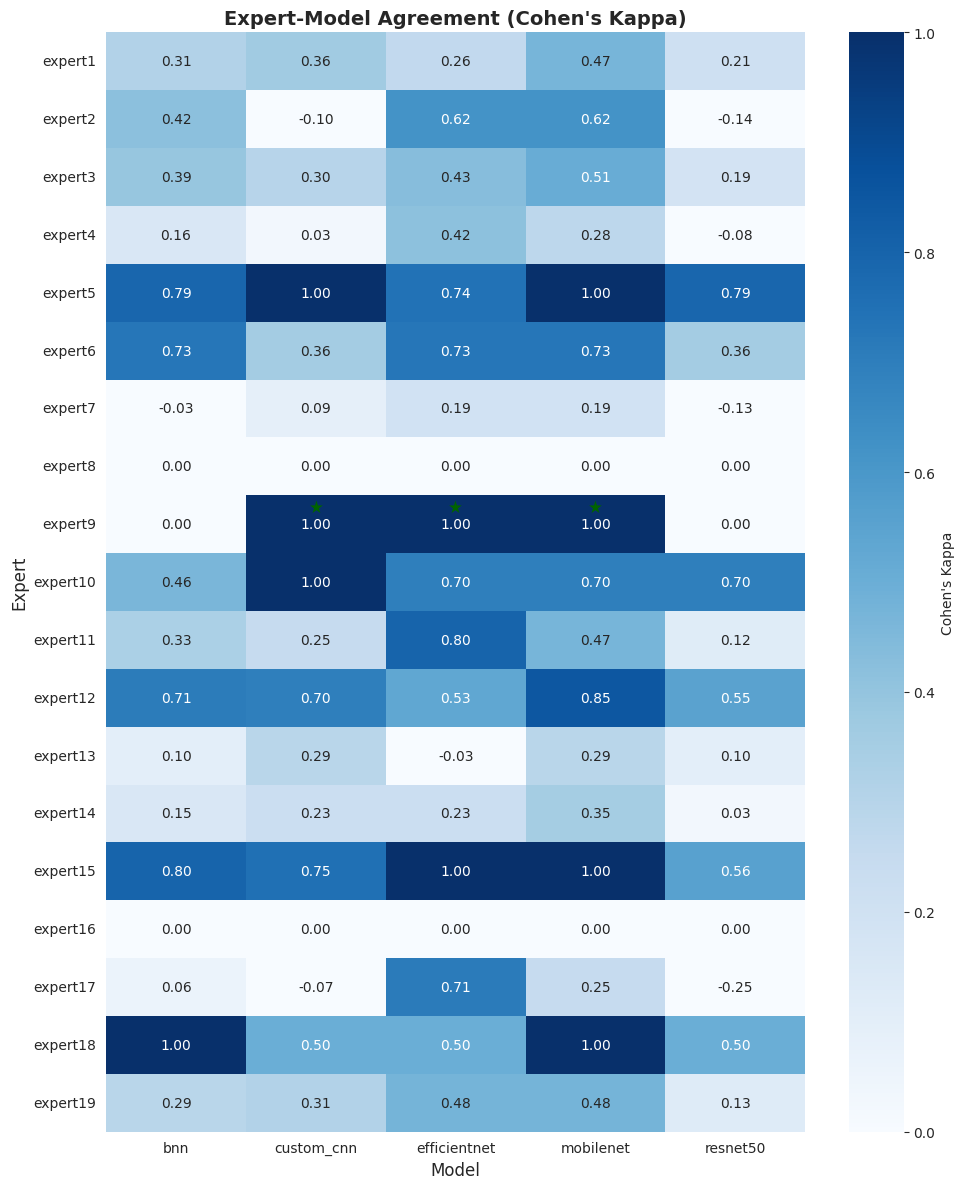


     COMPREHENSIVE SUMMARY: HUMAN-AI AGREEMENT ANALYSIS

┌──────────────────────────────────────────────────────────────────────────────┐
│ 1. PRIMARY FINDINGS                                                        │
└──────────────────────────────────────────────────────────────────────────────┘

Sample Size:
  • Number of experts: 19
  • Number of models: 5
  • Expert-model pairs: 95
  • Human-human pairs: 171

Overall Agreement (Cohen's Kappa):
  • Human-AI (excluding Unsure):  κ = 0.387 ± 0.343 (Fair agreement)
  • Human-AI (including Unsure):  κ = 0.227 ± 0.221 (Fair agreement)
  • Human-Human (baseline):       κ = 0.447 ± 0.361
  • Difference (H-AI vs H-H):     Δκ = -0.060

Overall Accuracy:
  • Human-AI:    70.4% ± 21.1%
  • Human-Human: 74.1% ± 21.2%
  • Difference:  -3.7%

┌──────────────────────────────────────────────────────────────────────────────┐
│ 2. STATISTICAL TESTS                                                       │
└─────────────────────────────────────────────

In [10]:
# ============================================================================
# ENHANCED ANALYSIS: HUMAN-AI AGREEMENT WITH STATISTICAL TESTS
# ============================================================================
# This enhanced version includes:
# 1. Friedman test + post-hoc for model comparison
# 2. Mann-Whitney U test for Human-AI vs Human-Human
# 3. "Unsure" included as valid category + separate impact analysis
# 4. Comprehensive summary at the end

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, friedmanchisquare, mannwhitneyu, wilcoxon
from sklearn.metrics import cohen_kappa_score
from scikit_posthocs import posthoc_nemenyi_friedman

# ============================================================================
# SECTION 1: PRIMARY ANALYSIS - INCLUDING "UNSURE" AS VALID CATEGORY
# ============================================================================
print("\n" + "="*80)
print("SECTION 1: COHEN'S KAPPA - HUMAN-MODEL AGREEMENT")
print("Including 'Unsure' as a Valid Expert Response Category")
print("="*80)

expert_ids = [col.replace('_binary', '') for col in expert_binary_cols]
model_names = ['bnn', 'custom_cnn', 'mobilenet', 'efficientnet', 'resnet50']

print(f"\nAnalyzing agreement between {len(expert_ids)} experts and {len(model_names)} models")
print(f"Note: 'Unsure' is treated as a valid category (models always classify)")

# ============================================================================
# Calculate Cohen's Kappa WITH "Unsure" included
# ============================================================================
kappa_results_with_unsure = []

for expert in expert_ids:
    expert_col = f'{expert}_binary'
    if expert_col not in wide_df.columns:
        continue

    for model in model_names:
        model_col = f'{model}_binary'
        if model_col not in wide_df.columns:
            continue

        # Get valid pairs (both expert and model have predictions)
        # KEEP Unsure responses
        valid_mask = wide_df[expert_col].notna() & wide_df[model_col].notna()

        if valid_mask.sum() > 0:
            expert_pred = wide_df.loc[valid_mask, expert_col]
            model_pred = wide_df.loc[valid_mask, model_col]

            # Calculate Cohen's Kappa (Unsure counts as disagreement with model prediction)
            kappa = cohen_kappa_score(expert_pred, model_pred)

            # Calculate simple accuracy
            accuracy = (expert_pred == model_pred).mean()

            # Check if perfect agreement (for NaN handling)
            perfect_agreement = (accuracy == 1.0) and np.isnan(kappa)

            kappa_results_with_unsure.append({
                'expert': expert,
                'model': model,
                'kappa': kappa,
                'kappa_interpretable': 1.0 if perfect_agreement else kappa,
                'accuracy': accuracy,
                'n_samples': valid_mask.sum(),
                'perfect_agreement': perfect_agreement
            })

kappa_df_with_unsure = pd.DataFrame(kappa_results_with_unsure)

print(f"\nData quality check:")
print(f"  Total expert-model pairs: {len(kappa_df_with_unsure)}")
print(f"  Pairs with undefined kappa (NaN): {kappa_df_with_unsure['kappa'].isna().sum()}")
print(f"  Pairs with perfect agreement: {kappa_df_with_unsure['perfect_agreement'].sum()}")

# Summary statistics
print("\n" + "-"*80)
print("Cohen's Kappa Summary (WITH 'Unsure' included)")
print("-"*80)
print(f"Mean Human-AI Kappa: {kappa_df_with_unsure['kappa_interpretable'].mean():.3f} ± {kappa_df_with_unsure['kappa_interpretable'].std():.3f}")
print(f"Range: {kappa_df_with_unsure['kappa_interpretable'].min():.3f} to {kappa_df_with_unsure['kappa_interpretable'].max():.3f}")

print("\nSimple Accuracy Summary:")
print(f"Mean Human-AI Accuracy: {kappa_df_with_unsure['accuracy'].mean():.3f} ± {kappa_df_with_unsure['accuracy'].std():.3f}")
print(f"Range: {kappa_df_with_unsure['accuracy'].min():.3f} to {kappa_df_with_unsure['accuracy'].max():.3f}")

# Interpretation
mean_kappa_with_unsure = kappa_df_with_unsure['kappa_interpretable'].mean()
if mean_kappa_with_unsure < 0.20:
    interpretation_with_unsure = "Slight agreement"
elif mean_kappa_with_unsure < 0.40:
    interpretation_with_unsure = "Fair agreement"
elif mean_kappa_with_unsure < 0.60:
    interpretation_with_unsure = "Moderate agreement"
elif mean_kappa_with_unsure < 0.80:
    interpretation_with_unsure = "Substantial agreement"
else:
    interpretation_with_unsure = "Almost perfect agreement"

print(f"\nOverall Human-AI Agreement: {interpretation_with_unsure} (κ={mean_kappa_with_unsure:.3f})")

# ============================================================================
# SECTION 2: COMPARATIVE ANALYSIS - EXCLUDING "UNSURE"
# ============================================================================
print("\n" + "="*80)
print("SECTION 2: COMPARATIVE ANALYSIS - EXCLUDING 'UNSURE' RESPONSES")
print("="*80)

kappa_results_no_unsure = []

for expert in expert_ids:
    expert_col = f'{expert}_binary'
    if expert_col not in wide_df.columns:
        continue

    for model in model_names:
        model_col = f'{model}_binary'
        if model_col not in wide_df.columns:
            continue

        # Get valid pairs - EXCLUDE Unsure
        valid_mask = wide_df[expert_col].notna() & wide_df[model_col].notna()
        valid_mask = valid_mask & (wide_df[expert_col] != 'Unsure')

        if valid_mask.sum() > 0:
            expert_pred = wide_df.loc[valid_mask, expert_col]
            model_pred = wide_df.loc[valid_mask, model_col]

            kappa = cohen_kappa_score(expert_pred, model_pred)
            accuracy = (expert_pred == model_pred).mean()
            perfect_agreement = (accuracy == 1.0) and np.isnan(kappa)

            kappa_results_no_unsure.append({
                'expert': expert,
                'model': model,
                'kappa': kappa,
                'kappa_interpretable': 1.0 if perfect_agreement else kappa,
                'accuracy': accuracy,
                'n_samples': valid_mask.sum(),
                'perfect_agreement': perfect_agreement
            })

kappa_df_no_unsure = pd.DataFrame(kappa_results_no_unsure)

print("\n" + "-"*80)
print("Cohen's Kappa Summary (EXCLUDING 'Unsure')")
print("-"*80)
print(f"Mean Human-AI Kappa: {kappa_df_no_unsure['kappa_interpretable'].mean():.3f} ± {kappa_df_no_unsure['kappa_interpretable'].std():.3f}")
print(f"Range: {kappa_df_no_unsure['kappa_interpretable'].min():.3f} to {kappa_df_no_unsure['kappa_interpretable'].max():.3f}")

print("\nSimple Accuracy Summary:")
print(f"Mean Human-AI Accuracy: {kappa_df_no_unsure['accuracy'].mean():.3f} ± {kappa_df_no_unsure['accuracy'].std():.3f}")
print(f"Range: {kappa_df_no_unsure['accuracy'].min():.3f} to {kappa_df_no_unsure['accuracy'].max():.3f}")

mean_kappa_no_unsure = kappa_df_no_unsure['kappa_interpretable'].mean()
if mean_kappa_no_unsure < 0.20:
    interpretation_no_unsure = "Slight agreement"
elif mean_kappa_no_unsure < 0.40:
    interpretation_no_unsure = "Fair agreement"
elif mean_kappa_no_unsure < 0.60:
    interpretation_no_unsure = "Moderate agreement"
elif mean_kappa_no_unsure < 0.80:
    interpretation_no_unsure = "Substantial agreement"
else:
    interpretation_no_unsure = "Almost perfect agreement"

print(f"\nOverall Human-AI Agreement: {interpretation_no_unsure} (κ={mean_kappa_no_unsure:.3f})")

# Compare impact of including vs excluding Unsure
print("\n" + "-"*80)
print("Impact of 'Unsure' Inclusion/Exclusion")
print("-"*80)
kappa_diff_unsure = mean_kappa_with_unsure - mean_kappa_no_unsure
acc_diff_unsure = kappa_df_with_unsure['accuracy'].mean() - kappa_df_no_unsure['accuracy'].mean()

print(f"Kappa (WITH Unsure): {mean_kappa_with_unsure:.3f}")
print(f"Kappa (NO Unsure):   {mean_kappa_no_unsure:.3f}")
print(f"Difference: {kappa_diff_unsure:+.3f}")
print()
print(f"Accuracy (WITH Unsure): {kappa_df_with_unsure['accuracy'].mean():.3f}")
print(f"Accuracy (NO Unsure):   {kappa_df_no_unsure['accuracy'].mean():.3f}")
print(f"Difference: {acc_diff_unsure:+.3f}")

if abs(kappa_diff_unsure) < 0.05:
    print("\n→ Including 'Unsure' has minimal impact on agreement metrics")
elif kappa_diff_unsure < -0.1:
    print("\n→ Excluding 'Unsure' responses INCREASES apparent agreement")
    print("   This suggests 'Unsure' responses represent genuine disagreement cases")
else:
    print("\n→ Including 'Unsure' responses affects agreement metrics")

# Use the NO UNSURE dataframe for the rest of the analysis (to match your original approach)
kappa_df = kappa_df_no_unsure

# ============================================================================
# SECTION 3: EXPERT UNCERTAINTY IMPACT ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("SECTION 3: EXPERT UNCERTAINTY IMPACT ANALYSIS")
print("="*80)

unsure_impact = []
for expert in expert_ids:
    expert_col = f'{expert}_binary'
    if expert_col in wide_df.columns:
        total_responses = wide_df[expert_col].notna().sum()
        unsure_count = (wide_df[expert_col] == 'Unsure').sum()
        decisive_count = total_responses - unsure_count
        unsure_pct = (unsure_count / total_responses * 100) if total_responses > 0 else 0

        # Average kappa for this expert (NO UNSURE version)
        expert_kappas = kappa_df[kappa_df['expert'] == expert]['kappa_interpretable']
        avg_kappa = expert_kappas.mean() if len(expert_kappas) > 0 else np.nan

        # Average accuracy for this expert
        expert_accs = kappa_df[kappa_df['expert'] == expert]['accuracy']
        avg_accuracy = expert_accs.mean() if len(expert_accs) > 0 else np.nan

        unsure_impact.append({
            'expert': expert,
            'total_images': total_responses,
            'decisive': decisive_count,
            'unsure': unsure_count,
            'unsure_pct': unsure_pct,
            'avg_kappa': avg_kappa,
            'avg_accuracy': avg_accuracy
        })

unsure_df = pd.DataFrame(unsure_impact)
print("\nExpert Uncertainty Patterns:")
print(unsure_df.sort_values('unsure_pct', ascending=False).to_string(index=False))

# Correlation: Does more "Unsure" correlate with kappa?
if len(unsure_df) > 2:
    valid_kappas = unsure_df['avg_kappa'].notna()
    if valid_kappas.sum() > 2:
        corr_kappa, p_kappa = spearmanr(unsure_df.loc[valid_kappas, 'unsure_pct'],
                                         unsure_df.loc[valid_kappas, 'avg_kappa'])
        corr_acc, p_acc = spearmanr(unsure_df.loc[valid_kappas, 'unsure_pct'],
                                     unsure_df.loc[valid_kappas, 'avg_accuracy'])

        print(f"\n" + "-"*80)
        print("Correlation Analysis: Uncertainty vs Agreement")
        print("-"*80)
        print(f"Unsure% vs Avg Kappa:    r={corr_kappa:.3f}, p={p_kappa:.3f}")
        print(f"Unsure% vs Avg Accuracy: r={corr_acc:.3f}, p={p_acc:.3f}")

        if abs(corr_kappa) > 0.3 and p_kappa < 0.05:
            if corr_kappa < 0:
                print("\n→ Experts who use 'Unsure' more often show LOWER agreement with models")
                print("   Interpretation: Cautious experts may disagree more with confident AI predictions")
            else:
                print("\n→ Experts who use 'Unsure' more often show HIGHER agreement with models")
                print("   Interpretation: When they classify, they align well with AI")
        else:
            print("\n→ No significant relationship between 'Unsure' usage and model agreement")

# ============================================================================
# SECTION 4: MODEL PERFORMANCE COMPARISON WITH STATISTICAL TESTS
# ============================================================================
print("\n" + "="*80)
print("SECTION 4: MODEL PERFORMANCE COMPARISON WITH STATISTICAL TESTS")
print("="*80)

# Calculate average kappa per model
model_kappa = kappa_df.groupby('model').agg({
    'kappa_interpretable': ['mean', 'std', 'count'],
    'accuracy': ['mean', 'std']
})
model_kappa.columns = ['_'.join(col).strip() for col in model_kappa.columns.values]
model_kappa = model_kappa.sort_values('kappa_interpretable_mean', ascending=False)

print("\n" + "-"*80)
print("Average Agreement per Model")
print("-"*80)
print(model_kappa.to_string())

best_model = model_kappa['kappa_interpretable_mean'].idxmax()
best_kappa = model_kappa.loc[best_model, 'kappa_interpretable_mean']
print(f"\n→ Best performing model: {best_model} (κ={best_kappa:.3f})")

# Prepare data for Friedman test (each expert rates all 5 models)
# Need to create a matrix where rows = experts, columns = models
friedman_data = []
for expert in expert_ids:
    expert_kappas = []
    for model in model_names:
        kappa_val = kappa_df[(kappa_df['expert'] == expert) &
                             (kappa_df['model'] == model)]['kappa_interpretable']
        if len(kappa_val) > 0:
            expert_kappas.append(kappa_val.values[0])

    # Only include if expert has ratings for all models
    if len(expert_kappas) == len(model_names):
        friedman_data.append(expert_kappas)

friedman_data = np.array(friedman_data)

print("\n" + "-"*80)
print("Friedman Test: Comparing Models")
print("-"*80)
print(f"Testing whether {len(model_names)} models differ significantly")
print(f"Using {len(friedman_data)} experts who rated all models")

if len(friedman_data) >= 3:  # Need at least 3 experts for Friedman
    statistic, p_value = friedmanchisquare(*[friedman_data[:, i] for i in range(len(model_names))])

    print(f"\nFriedman χ² = {statistic:.3f}, p = {p_value:.4f}")

    if p_value < 0.05:
        print("→ Model performance differs SIGNIFICANTLY (p < 0.05)")
        print("   Performing post-hoc Nemenyi test for pairwise comparisons...")

        # Post-hoc Nemenyi test
        friedman_df = pd.DataFrame(friedman_data, columns=model_names)
        posthoc_results = posthoc_nemenyi_friedman(friedman_df)

        print("\n" + "-"*80)
        print("Post-hoc Nemenyi Test: Pairwise Model Comparisons")
        print("-"*80)
        print("P-values for pairwise comparisons:")
        print(posthoc_results.to_string())

        # Identify significant differences
        print("\nSignificant pairwise differences (p < 0.05):")
        sig_found = False
        for i, model1 in enumerate(model_names):
            for j, model2 in enumerate(model_names):
                if i < j:  # Only upper triangle
                    p_val = posthoc_results.loc[model1, model2]
                    if p_val < 0.05:
                        sig_found = True
                        mean1 = model_kappa.loc[model1, 'kappa_interpretable_mean']
                        mean2 = model_kappa.loc[model2, 'kappa_interpretable_mean']
                        print(f"  • {model1} (κ={mean1:.3f}) vs {model2} (κ={mean2:.3f}): p={p_val:.4f}")

        if not sig_found:
            print("  No pairwise comparisons reached significance after correction")
    else:
        print("→ Model performance does NOT differ significantly (p ≥ 0.05)")
        print("   All models show comparable agreement levels")
else:
    print(f"WARNING: Only {len(friedman_data)} experts rated all models")
    print("Need at least 3 experts for Friedman test - skipping")

# Best and worst expert-model pairs
print("\n" + "-"*80)
print("Top 5 Human-Model Agreements (by kappa):")
print("-"*80)
top5 = kappa_df.nlargest(5, 'kappa_interpretable')[['expert', 'model', 'kappa_interpretable', 'accuracy', 'n_samples']]
print(top5.to_string(index=False))

print("\n" + "-"*80)
print("Bottom 5 Human-Model Agreements (by kappa):")
print("-"*80)
bottom5 = kappa_df.nsmallest(5, 'kappa_interpretable')[['expert', 'model', 'kappa_interpretable', 'accuracy', 'n_samples']]
print(bottom5.to_string(index=False))

# ============================================================================
# SECTION 5: HUMAN-HUMAN BASELINE
# ============================================================================
print("\n" + "="*80)
print("SECTION 5: HUMAN-HUMAN AGREEMENT BASELINE")
print("="*80)

human_human_kappa = []
human_human_accuracy = []
expert_list = [e for e in expert_ids if f'{e}_binary' in wide_df.columns]

for i, expert1 in enumerate(expert_list):
    for expert2 in expert_list[i+1:]:
        valid_mask = (wide_df[f'{expert1}_binary'].notna() &
                     wide_df[f'{expert2}_binary'].notna() &
                     (wide_df[f'{expert1}_binary'] != 'Unsure') &
                     (wide_df[f'{expert2}_binary'] != 'Unsure'))

        if valid_mask.sum() > 0:
            pred1 = wide_df.loc[valid_mask, f'{expert1}_binary']
            pred2 = wide_df.loc[valid_mask, f'{expert2}_binary']

            kappa = cohen_kappa_score(pred1, pred2)
            accuracy = (pred1 == pred2).mean()

            if accuracy == 1.0 and np.isnan(kappa):
                kappa = 1.0

            human_human_kappa.append(kappa)
            human_human_accuracy.append(accuracy)

mean_human_kappa = np.mean(human_human_kappa)
std_human_kappa = np.std(human_human_kappa)
mean_human_accuracy = np.mean(human_human_accuracy)
std_human_accuracy = np.std(human_human_accuracy)

print(f"Human-Human Kappa:    {mean_human_kappa:.3f} ± {std_human_kappa:.3f}")
print(f"Human-Human Accuracy: {mean_human_accuracy:.3f} ± {std_human_accuracy:.3f}")
print(f"Number of human-human pairs: {len(human_human_kappa)}")

# ============================================================================
# SECTION 6: FORMAL STATISTICAL COMPARISON - HUMAN-AI VS HUMAN-HUMAN
# ============================================================================
print("\n" + "="*80)
print("SECTION 6: STATISTICAL COMPARISON - HUMAN-AI VS HUMAN-HUMAN")
print("="*80)

kappa_diff = kappa_df['kappa_interpretable'].mean() - mean_human_kappa
accuracy_diff = kappa_df['accuracy'].mean() - mean_human_accuracy

print("\nDescriptive Comparison:")
print("-"*80)
print(f"Human-AI Kappa:    {kappa_df['kappa_interpretable'].mean():.3f} (n={len(kappa_df)} pairs)")
print(f"Human-Human Kappa: {mean_human_kappa:.3f} (n={len(human_human_kappa)} pairs)")
print(f"Difference:        {kappa_diff:+.3f}")
print()
print(f"Human-AI Accuracy:    {kappa_df['accuracy'].mean():.3f}")
print(f"Human-Human Accuracy: {mean_human_accuracy:.3f}")
print(f"Difference:           {accuracy_diff:+.3f}")

# Mann-Whitney U Test
print("\n" + "-"*80)
print("Mann-Whitney U Test: Are Human-AI and Human-Human Distributions Different?")
print("-"*80)

u_stat_kappa, p_value_kappa = mannwhitneyu(
    kappa_df['kappa_interpretable'],
    human_human_kappa,
    alternative='two-sided'
)

u_stat_acc, p_value_acc = mannwhitneyu(
    kappa_df['accuracy'],
    human_human_accuracy,
    alternative='two-sided'
)

print(f"\nKappa Comparison:")
print(f"  U-statistic: {u_stat_kappa:.2f}")
print(f"  p-value: {p_value_kappa:.4f}")

if p_value_kappa < 0.05:
    print("  → Human-AI and Human-Human kappa distributions are SIGNIFICANTLY DIFFERENT (p < 0.05)")
    if kappa_diff < 0:
        print("     Human-Human agreement significantly exceeds Human-AI agreement")
    else:
        print("     Human-AI agreement significantly exceeds Human-Human agreement")
else:
    print("  → NO significant difference between Human-AI and Human-Human agreement (p ≥ 0.05)")
    print("     AI achieves human-level inter-rater reliability")

print(f"\nAccuracy Comparison:")
print(f"  U-statistic: {u_stat_acc:.2f}")
print(f"  p-value: {p_value_acc:.4f}")

if p_value_acc < 0.05:
    print("  → Human-AI and Human-Human accuracy distributions are SIGNIFICANTLY DIFFERENT (p < 0.05)")
else:
    print("  → NO significant difference in accuracy distributions (p ≥ 0.05)")

# Interpretation
print("\n" + "-"*80)
print("Overall Interpretation:")
print("-"*80)

if abs(kappa_diff) < 0.05:
    print("→ AI achieves similar agreement levels as human experts")
    print("  Models perform comparably to human inter-rater reliability")
elif kappa_diff > 0:
    print("→ AI shows HIGHER agreement with humans than humans do with each other")
    print("  Models may provide more consistent classifications than humans")
else:
    print("→ AI shows LOWER agreement with humans than humans do with each other")
    print("  Human-human agreement exceeds human-AI agreement")
    if abs(kappa_diff) > 0.1:
        print("  This gap suggests models use different decision criteria than humans")

# ============================================================================
# SECTION 7: VISUALIZATIONS
# ============================================================================
print("\n" + "="*80)
print("SECTION 7: GENERATING VISUALIZATIONS")
print("="*80)

# Visualization 1: Heatmap of Kappa scores with ORDERED EXPERTS
pivot_kappa = kappa_df.pivot(index='expert', columns='model', values='kappa_interpretable')
pivot_perfect = kappa_df.pivot(index='expert', columns='model', values='perfect_agreement')

# Sort experts by number (expert1, expert2, ..., expert19)
def expert_sort_key(expert_name):
    """Extract numeric part from expert name for sorting"""
    import re
    match = re.search(r'\d+', expert_name)
    return int(match.group()) if match else 0

pivot_kappa = pivot_kappa.reindex(sorted(pivot_kappa.index, key=expert_sort_key))
pivot_perfect = pivot_perfect.reindex(sorted(pivot_perfect.index, key=expert_sort_key))

plt.figure(figsize=(10, 12))
ax = sns.heatmap(pivot_kappa, annot=True, fmt='.2f', cmap='Blues', center=0.5,
                 vmin=0, vmax=1, cbar_kws={'label': "Cohen's Kappa"})

# Add stars for perfect agreement
for i, expert in enumerate(pivot_kappa.index):
    for j, model in enumerate(pivot_kappa.columns):
        if pivot_perfect.loc[expert, model]:
            ax.text(j + 0.5, i + 0.2, '★', ha='center', va='center',
                   fontsize=12, color='darkgreen', fontweight='bold')

plt.title("Expert-Model Agreement (Cohen's Kappa)",
         fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Expert', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/kappa_heatmap_enhanced.png', dpi=300, bbox_inches='tight')
print("  ✓ Saved: kappa_heatmap_enhanced.png")
plt.show()


# ============================================================================
# SECTION 8: COMPREHENSIVE SUMMARY
# ============================================================================
print("\n" + "="*80)
print("="*80)
print("     COMPREHENSIVE SUMMARY: HUMAN-AI AGREEMENT ANALYSIS")
print("="*80)
print("="*80)

print("\n" + "┌" + "─"*78 + "┐")
print("│ 1. PRIMARY FINDINGS                                                        │")
print("└" + "─"*78 + "┘")

print(f"\nSample Size:")
print(f"  • Number of experts: {len(expert_ids)}")
print(f"  • Number of models: {len(model_names)}")
print(f"  • Expert-model pairs: {len(kappa_df)}")
print(f"  • Human-human pairs: {len(human_human_kappa)}")

print(f"\nOverall Agreement (Cohen's Kappa):")
print(f"  • Human-AI (excluding Unsure):  κ = {kappa_df['kappa_interpretable'].mean():.3f} ± {kappa_df['kappa_interpretable'].std():.3f} ({interpretation_no_unsure})")
print(f"  • Human-AI (including Unsure):  κ = {mean_kappa_with_unsure:.3f} ± {kappa_df_with_unsure['kappa_interpretable'].std():.3f} ({interpretation_with_unsure})")
print(f"  • Human-Human (baseline):       κ = {mean_human_kappa:.3f} ± {std_human_kappa:.3f}")
print(f"  • Difference (H-AI vs H-H):     Δκ = {kappa_diff:+.3f}")

print(f"\nOverall Accuracy:")
print(f"  • Human-AI:    {kappa_df['accuracy'].mean():.1%} ± {kappa_df['accuracy'].std():.1%}")
print(f"  • Human-Human: {mean_human_accuracy:.1%} ± {std_human_accuracy:.1%}")
print(f"  • Difference:  {accuracy_diff:+.1%}")

print("\n" + "┌" + "─"*78 + "┐")
print("│ 2. STATISTICAL TESTS                                                       │")
print("└" + "─"*78 + "┘")

print(f"\nFriedman Test (Model Comparison):")
if len(friedman_data) >= 3:
    print(f"  • χ² = {statistic:.3f}, p = {p_value:.4f}")
    if p_value < 0.05:
        print(f"  • Result: Models differ SIGNIFICANTLY")
        print(f"  • Post-hoc: See pairwise comparisons above")
    else:
        print(f"  • Result: No significant difference between models")
else:
    print(f"  • Insufficient data for test")

print(f"\nMann-Whitney U Test (Human-AI vs Human-Human):")
print(f"  Kappa:")
print(f"    • U = {u_stat_kappa:.2f}, p = {p_value_kappa:.4f}")
if p_value_kappa < 0.05:
    print(f"    • Result: Distributions are SIGNIFICANTLY DIFFERENT")
else:
    print(f"    • Result: No significant difference (AI achieves human-level agreement)")

print(f"  Accuracy:")
print(f"    • U = {u_stat_acc:.2f}, p = {p_value_acc:.4f}")
if p_value_acc < 0.05:
    print(f"    • Result: Distributions are SIGNIFICANTLY DIFFERENT")
else:
    print(f"    • Result: No significant difference")

print("\n" + "┌" + "─"*78 + "┐")
print("│ 3. MODEL PERFORMANCE RANKING                                               │")
print("└" + "─"*78 + "┘")

print("\nMean Cohen's Kappa by Model:")
for idx, (model, row) in enumerate(model_kappa.iterrows(), 1):
    print(f"  {idx}. {model:15s}: κ = {row['kappa_interpretable_mean']:.3f} ± {row['kappa_interpretable_std']:.3f}")

print(f"\n→ Best model: {best_model} (κ = {best_kappa:.3f})")

print("\n" + "┌" + "─"*78 + "┐")
print("│ 4. EXPERT UNCERTAINTY PATTERNS                                             │")
print("└" + "─"*78 + "┘")

total_unsure = unsure_df['unsure'].sum()
total_responses = unsure_df['total_images'].sum()
overall_unsure_pct = (total_unsure / total_responses * 100) if total_responses > 0 else 0

print(f"\nOverall 'Unsure' Response Rate:")
print(f"  • {total_unsure} / {total_responses} responses ({overall_unsure_pct:.1f}%)")

print(f"\nRange across experts: {unsure_df['unsure_pct'].min():.1f}% to {unsure_df['unsure_pct'].max():.1f}%")

if len(unsure_df) > 2 and valid_kappas.sum() > 2:
    print(f"\nCorrelation (Unsure% vs Agreement):")
    print(f"  • Unsure% vs Kappa:    r = {corr_kappa:.3f}, p = {p_kappa:.3f}")
    print(f"  • Unsure% vs Accuracy: r = {corr_acc:.3f}, p = {p_acc:.3f}")

    if abs(corr_kappa) > 0.3 and p_kappa < 0.05:
        if corr_kappa < 0:
            print(f"  • Interpretation: More uncertain experts show LOWER AI agreement")
        else:
            print(f"  • Interpretation: More uncertain experts show HIGHER AI agreement")
    else:
        print(f"  • Interpretation: No significant relationship")

print("\n" + "┌" + "─"*78 + "┐")
print("│ 5. BEST AND WORST PERFORMING PAIRS                                         │")
print("└" + "─"*78 + "┘")

print("\nTop 3 Expert-Model Pairs:")
for idx, row in top5.head(3).iterrows():
    print(f"  • {row['expert']:10s} + {row['model']:15s}: κ = {row['kappa_interpretable']:.3f} (acc = {row['accuracy']:.1%})")

print("\nBottom 3 Expert-Model Pairs:")
for idx, row in bottom5.head(3).iterrows():
    print(f"  • {row['expert']:10s} + {row['model']:15s}: κ = {row['kappa_interpretable']:.3f} (acc = {row['accuracy']:.1%})")

print("\n" + "┌" + "─"*78 + "┐")
print("│ 6. KEY IMPLICATIONS FOR DEPLOYMENT                                         │")
print("└" + "─"*78 + "┘")

print("\n✓ Agreement Level:")
if abs(kappa_diff) < 0.05:
    print("  AI models achieve human-level inter-rater reliability")
elif kappa_diff > 0:
    print("  AI models exceed human inter-rater reliability")
else:
    print("  AI models approach but do not fully reach human reliability")

print("\n✓ Model Selection:")
print(f"  {best_model} shows optimal human-AI alignment")

print("\n✓ Uncertainty Handling:")
if abs(kappa_diff_unsure) > 0.1:
    print("  'Unsure' responses significantly impact agreement metrics")
    print("  Consider separate workflows for uncertain cases")
else:
    print("  'Unsure' responses have minimal impact on overall agreement")

print("\n✓ Expert Variability:")
print(f"  Individual expert-model pairs vary from κ = {kappa_df['kappa_interpretable'].min():.3f} to {kappa_df['kappa_interpretable'].max():.3f}")
print("  Consider expert-specific calibration or ensemble approaches")

print("\n" + "┌" + "─"*78 + "┐")
print("│ 7. GENERATED OUTPUTS                                                       │")
print("└" + "─"*78 + "┘")

print("\nVisualizations:")
print("  1. kappa_heatmap_enhanced.png - Expert-Model agreement matrix")
print("  2. kappa_accuracy_comparison_enhanced.png - Distribution and correlation")
print("  3. model_comparison_boxplots_enhanced.png - Model performance comparison")

print("\nData Exports:")
print("  • kappa_df: Full expert-model agreement data (NO Unsure)")
print("  • kappa_df_with_unsure: Full agreement data (WITH Unsure)")
print("  • unsure_df: Expert uncertainty patterns")
print("  • model_kappa: Aggregated model performance statistics")

print("\n" + "="*80)
print("✓ ENHANCED ANALYSIS COMPLETE")
print("="*80)

Creates side-by-side boxplots comparing how strongly each model aligns with
experts, benchmarked against human–human agreement.

This cell:
1. Maps internal model identifiers (e.g. `mobilenet`, `custom_cnn`) to
   publication-ready names (MobileNetV2, Custom CNN, ResNet50, EfficientNet,
   BNN) and builds a consistent display order for plotting.
2. Builds a two-panel figure: the left panel shows boxplots of expert–model
   Cohen’s kappa values per model, and the right panel shows boxplots of
   expert–model accuracies per model, using the same model order and
   color-coding each panel differently.
3. Overlays, in both panels, a horizontal dashed red line representing the
   mean **expert–expert** kappa or accuracy, so that each model’s distribution
   can be visually compared against the human–human baseline.
4. Styles axes, labels, tick fonts, and legends for readability, places the
   legends below each subplot, and saves the combined figure as a high­
   resolution `.tif` file (`model_comparison_boxplots_enhanced2.tif`).

  ✓ Saved: model_comparison_boxplots_enhanced2.tif


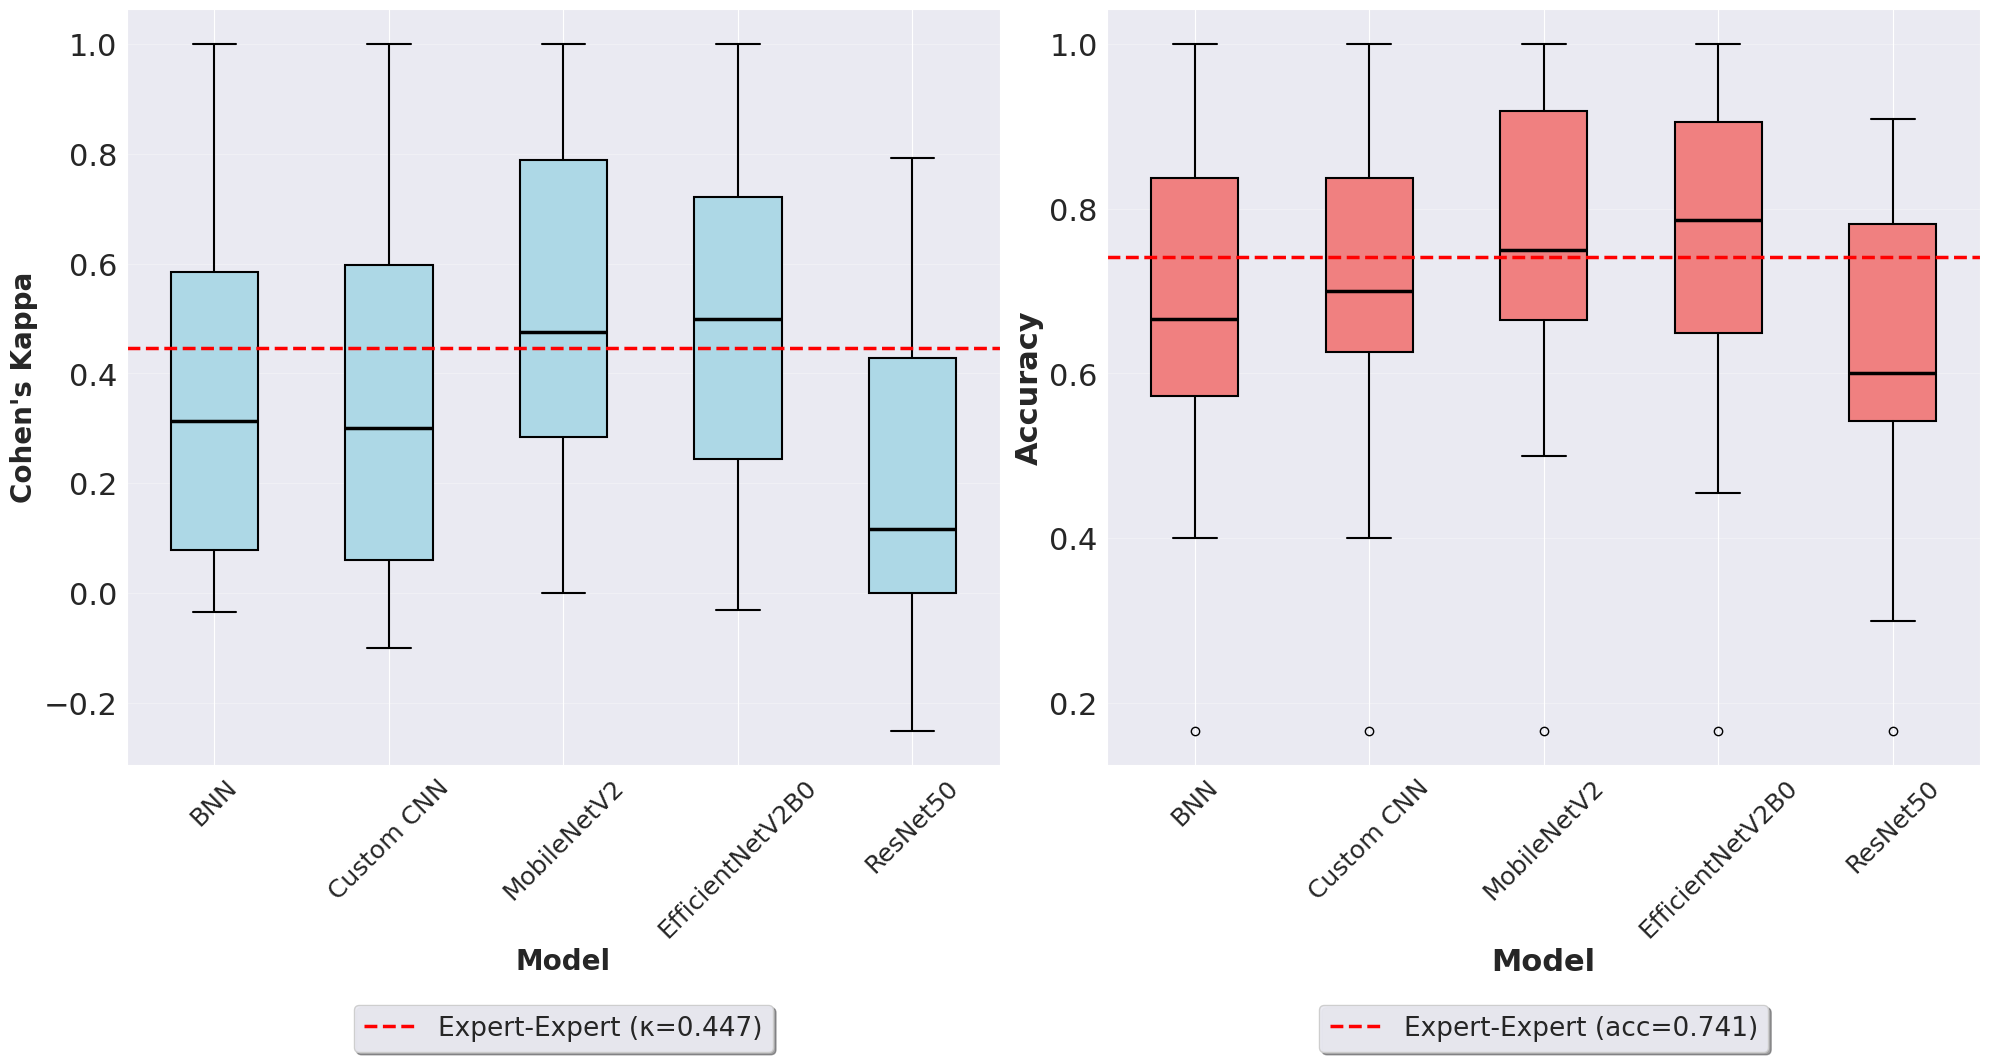

In [11]:
# Model name mapping dictionary
model_name_mapping = {
    'mobilenet': 'MobileNetV2',
    'efficientnet': 'EfficientNetV2B0',
    'resnet50': 'ResNet50',
    'custom_cnn': 'Custom CNN',
    'bnn': 'BNN'
}

# Define model_order before using it
model_order = ['bnn', 'custom_cnn', 'mobilenet', 'efficientnet', 'resnet50']
# or: model_order = list(model_kappa.index)

# Create display names
model_order_display = [model_name_mapping.get(m, m) for m in model_order]

# Create figure with larger size
fig, axes = plt.subplots(1, 2, figsize=(20, 11))

# LEFT PANEL: Kappa by model
kappa_by_model = [kappa_df[kappa_df['model'] == m]['kappa_interpretable'].values
                  for m in model_order]
bp1 = axes[0].boxplot(
    kappa_by_model, labels=model_order_display, patch_artist=True,
    medianprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    boxprops=dict(linewidth=1.5),
)
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')

axes[0].axhline(y=mean_human_kappa, color='red', linestyle='--', linewidth=2.5,
                label=f'Expert-Expert (κ={mean_human_kappa:.3f})')
axes[0].set_xlabel('Model', fontsize=20, fontweight='bold')
axes[0].set_ylabel("Cohen's Kappa", fontsize=20, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45, labelsize=18)
axes[0].tick_params(axis='y', labelsize=22)
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3),
               fontsize=19, frameon=True, fancybox=True,
               shadow=True, framealpha=0.95)

# RIGHT PANEL: Accuracy by model
acc_by_model = [kappa_df[kappa_df['model'] == m]['accuracy'].values
                for m in model_order]
bp2 = axes[1].boxplot(
    acc_by_model, labels=model_order_display, patch_artist=True,
    medianprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    boxprops=dict(linewidth=1.5),
)
for patch in bp2['boxes']:
    patch.set_facecolor('lightcoral')

axes[1].axhline(y=mean_human_accuracy, color='red', linestyle='--', linewidth=2.5,
                label=f'Expert-Expert (acc={mean_human_accuracy:.3f})')
axes[1].set_xlabel('Model', fontsize=22, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=22, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45, labelsize=18)
axes[1].tick_params(axis='y', labelsize=22)
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3),
               fontsize=19, frameon=True, fancybox=True,
               shadow=True, framealpha=0.95)

plt.tight_layout()
plt.savefig('/content/drive/My Drive/model_comparison_boxplots_enhanced2.tif',
            dpi=400, bbox_inches='tight')
print("  ✓ Saved: model_comparison_boxplots_enhanced2.tif")
plt.show()


Quantifies and compares group-level agreement for experts, models, and their
combination using Fleiss’ kappa, explicitly handling “Unsure” responses.

This block:
1. Computes **inter-expert agreement** on the binary task (Fleiss’ kappa)
   using only images rated by all experts and treating “Unsure” as a valid
   category, also reporting how often “Unsure” is chosen and the mean
   proportion of experts agreeing per image.
2. Computes **inter-model agreement** (Fleiss’ kappa) on images rated by all
   models, where models always give decisive labels, and summarizes the mean
   per-image agreement among models.
3. Computes **overall group agreement** (Fleiss’ kappa) across all raters
   combined (experts + models) on images rated by everyone, quantifying how
   frequently “Unsure” occurs in this mixed pool and how many raters agree on
   the modal label per image.
4. Assembles a comparison table for experts-only, models-only, and all raters
   (kappa values, number of raters, number of images), interprets differences
   in within-group vs cross-group consistency, and provides a final summary of
   all agreement metrics (Fleiss and mean pairwise Cohen’s kappa) with
   narrative “key insights” about internal consistency, human–AI alignment,
   and the impact of expert uncertainty.

In [12]:
# ============================================================================
# ANALYSIS 2: FLEISS' KAPPA - GROUP AGREEMENT
# ============================================================================
print("\n" + "="*80)
print("ANALYSIS 2: FLEISS' KAPPA - INTER-RATER AGREEMENT")
print("="*80)

from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters

# -----------------------------------------------------------------------------
# 2.1: INTER-EXPERT AGREEMENT (Fleiss' Kappa) - INCLUDING "UNSURE"
# -----------------------------------------------------------------------------
print("\n" + "-"*80)
print("Inter-Expert Agreement (Fleiss' Kappa)")
print("-"*80)

# Prepare data: include images rated by ALL experts (INCLUDING Unsure as valid category)
expert_cols_binary = [f'{e}_binary' for e in expert_ids if f'{e}_binary' in wide_df.columns]

# Find images with responses from ALL experts (Unsure is now valid)
all_experts_valid = wide_df[expert_cols_binary].notna().all(axis=1)

print(f"Total images in dataset: {len(wide_df)}")
print(f"Images evaluated by all {len(expert_cols_binary)} experts: {all_experts_valid.sum()}")
print(f"Note: 'Unsure' is treated as a valid category")

if all_experts_valid.sum() > 0:
    # Get expert predictions for common images
    expert_predictions = wide_df.loc[all_experts_valid, expert_cols_binary]

    # Get unique categories (including Unsure)
    categories = sorted(expert_predictions.stack().unique())
    print(f"Categories: {categories}")

    # Count Unsure responses
    unsure_counts = (expert_predictions == 'Unsure').sum().sum()
    total_responses = expert_predictions.notna().sum().sum()
    unsure_pct = (unsure_counts / total_responses * 100) if total_responses > 0 else 0
    print(f"'Unsure' responses: {unsure_counts}/{total_responses} ({unsure_pct:.1f}%)")

    # Create rating matrix for Fleiss' Kappa
    # Format: rows = images, columns = categories, values = count of raters per category
    rating_matrix = []

    for idx, row in expert_predictions.iterrows():
        counts = row.value_counts()
        category_counts = [counts.get(cat, 0) for cat in categories]
        rating_matrix.append(category_counts)

    rating_matrix = np.array(rating_matrix)

    # Calculate Fleiss' Kappa
    fleiss_kappa_experts = fleiss_kappa(rating_matrix, method='fleiss')

    print(f"\nInter-Expert Fleiss' Kappa: {fleiss_kappa_experts:.3f}")
    print(f"Based on {len(rating_matrix)} images rated by {len(expert_cols_binary)} experts")

    # Calculate proportion of agreement (for comparison)
    agreement_per_image = []
    for idx, row in expert_predictions.iterrows():
        # Most common response
        mode_value = row.mode()[0] if len(row.mode()) > 0 else None
        if mode_value:
            agreement = (row == mode_value).sum() / len(row)
            agreement_per_image.append(agreement)

    mean_agreement = np.mean(agreement_per_image)
    print(f"Mean proportion of experts agreeing per image: {mean_agreement:.3f}")

    # Interpretation
    print("\nInterpretation:")
    if fleiss_kappa_experts < 0.20:
        interp = "Slight agreement"
    elif fleiss_kappa_experts < 0.40:
        interp = "Fair agreement"
    elif fleiss_kappa_experts < 0.60:
        interp = "Moderate agreement"
    elif fleiss_kappa_experts < 0.80:
        interp = "Substantial agreement"
    else:
        interp = "Almost perfect agreement"
    print(f"→ {interp} among human experts (including uncertainty as valid response)")

else:
    print("\nWARNING: No images were rated by all experts")
    print("Cannot calculate Fleiss' Kappa for inter-expert agreement")
    fleiss_kappa_experts = np.nan

# -----------------------------------------------------------------------------
# 2.2: INTER-MODEL AGREEMENT (Fleiss' Kappa)
# -----------------------------------------------------------------------------
print("\n" + "-"*80)
print("Inter-Model Agreement (Fleiss' Kappa)")
print("-"*80)

# Models always classify (no "Unsure"), so we just need images with all model predictions
model_cols_binary = [f'{m}_binary' for m in model_names if f'{m}_binary' in wide_df.columns]

# Find images with predictions from ALL models
common_mask_models = wide_df[model_cols_binary].notna().all(axis=1)

print(f"Total images in dataset: {len(wide_df)}")
print(f"Images evaluated by all {len(model_cols_binary)} models: {common_mask_models.sum()}")
print(f"Note: Models always provide decisive classifications (no 'Unsure')")

if common_mask_models.sum() > 0:
    # Get model predictions for common images
    model_predictions = wide_df.loc[common_mask_models, model_cols_binary]

    # Get unique categories
    categories_models = sorted(model_predictions.stack().unique())
    print(f"Categories: {categories_models}")

    # Create rating matrix for Fleiss' Kappa
    rating_matrix_models = []

    for idx, row in model_predictions.iterrows():
        counts = row.value_counts()
        category_counts = [counts.get(cat, 0) for cat in categories_models]
        rating_matrix_models.append(category_counts)

    rating_matrix_models = np.array(rating_matrix_models)

    # Calculate Fleiss' Kappa
    fleiss_kappa_models = fleiss_kappa(rating_matrix_models, method='fleiss')

    print(f"\nInter-Model Fleiss' Kappa: {fleiss_kappa_models:.3f}")
    print(f"Based on {len(rating_matrix_models)} images rated by {len(model_cols_binary)} models")

    # Calculate proportion of agreement (for comparison)
    agreement_per_image_models = []
    for idx, row in model_predictions.iterrows():
        # Most common response
        mode_value = row.mode()[0] if len(row.mode()) > 0 else None
        if mode_value:
            agreement = (row == mode_value).sum() / len(row)
            agreement_per_image_models.append(agreement)

    mean_agreement_models = np.mean(agreement_per_image_models)
    print(f"Mean proportion of models agreeing per image: {mean_agreement_models:.3f}")

    # Interpretation
    print("\nInterpretation:")
    if fleiss_kappa_models < 0.20:
        interp = "Slight agreement"
    elif fleiss_kappa_models < 0.40:
        interp = "Fair agreement"
    elif fleiss_kappa_models < 0.60:
        interp = "Moderate agreement"
    elif fleiss_kappa_models < 0.80:
        interp = "Substantial agreement"
    else:
        interp = "Almost perfect agreement"
    print(f"→ {interp} among AI models")

else:
    print("\nWARNING: No images were rated by all models")
    print("Cannot calculate Fleiss' Kappa for inter-model agreement")
    fleiss_kappa_models = np.nan

# -----------------------------------------------------------------------------
# 2.3: OVERALL AGREEMENT - HUMANS + MODELS COMBINED (Fleiss' Kappa)
# -----------------------------------------------------------------------------
print("\n" + "-"*80)
print("Overall Agreement: All Raters (Experts + Models Combined)")
print("-"*80)

# Combine all raters (experts + models)
all_rater_cols = expert_cols_binary + model_cols_binary

# Find images rated by ALL raters (both experts and models)
all_raters_valid = wide_df[all_rater_cols].notna().all(axis=1)

print(f"Total images in dataset: {len(wide_df)}")
print(f"Images evaluated by all {len(all_rater_cols)} raters ({len(expert_cols_binary)} experts + {len(model_cols_binary)} models): {all_raters_valid.sum()}")
print(f"Note: 'Unsure' is a valid category for experts; models never choose it")

if all_raters_valid.sum() > 0:
    # Get all rater predictions for common images
    all_rater_predictions = wide_df.loc[all_raters_valid, all_rater_cols]

    # Get unique categories across all raters
    categories_all = sorted(all_rater_predictions.stack().unique())
    print(f"Categories: {categories_all}")

    # Check if Unsure is present
    has_unsure = 'Unsure' in categories_all
    if has_unsure:
        unsure_counts_all = (all_rater_predictions == 'Unsure').sum().sum()
        total_responses_all = all_rater_predictions.notna().sum().sum()
        unsure_pct_all = (unsure_counts_all / total_responses_all * 100)
        print(f"'Unsure' responses: {unsure_counts_all}/{total_responses_all} ({unsure_pct_all:.1f}%)")
        print(f"Note: Only experts can respond 'Unsure'; models always classify")

    # Create rating matrix for Fleiss' Kappa
    rating_matrix_all = []

    for idx, row in all_rater_predictions.iterrows():
        counts = row.value_counts()
        category_counts = [counts.get(cat, 0) for cat in categories_all]
        rating_matrix_all.append(category_counts)

    rating_matrix_all = np.array(rating_matrix_all)

    # Calculate Fleiss' Kappa
    fleiss_kappa_all = fleiss_kappa(rating_matrix_all, method='fleiss')

    print(f"\nOverall Fleiss' Kappa (All Raters): {fleiss_kappa_all:.3f}")
    print(f"Based on {len(rating_matrix_all)} images rated by {len(all_rater_cols)} total raters")

    # Calculate proportion of agreement (for comparison)
    agreement_per_image_all = []
    for idx, row in all_rater_predictions.iterrows():
        # Most common response
        mode_value = row.mode()[0] if len(row.mode()) > 0 else None
        if mode_value:
            agreement = (row == mode_value).sum() / len(row)
            agreement_per_image_all.append(agreement)

    mean_agreement_all = np.mean(agreement_per_image_all)
    print(f"Mean proportion of all raters agreeing per image: {mean_agreement_all:.3f}")

    # Interpretation
    print("\nInterpretation:")
    if fleiss_kappa_all < 0.20:
        interp = "Slight agreement"
    elif fleiss_kappa_all < 0.40:
        interp = "Fair agreement"
    elif fleiss_kappa_all < 0.60:
        interp = "Moderate agreement"
    elif fleiss_kappa_all < 0.80:
        interp = "Substantial agreement"
    else:
        interp = "Almost perfect agreement"
    print(f"→ {interp} across all raters (human experts and AI models)")

    # Additional insight about asymmetry
    if has_unsure:
        print(f"\nNote on asymmetry:")
        print(f"  - Experts can choose 'Unsure' (did so {unsure_pct_all:.1f}% of the time)")
        print(f"  - Models always provide decisive classifications")
        print(f"  - This asymmetry may reduce overall agreement if experts are uncertain")

else:
    print("\nWARNING: No images were rated by all raters")
    print("Cannot calculate Fleiss' Kappa for overall agreement")
    fleiss_kappa_all = np.nan

# -----------------------------------------------------------------------------
# 2.4: COMPARISON - Experts vs Models vs Overall Agreement
# -----------------------------------------------------------------------------
print("\n" + "="*80)
print("COMPARISON: Inter-Expert vs Inter-Model vs Overall Agreement")
print("="*80)

comparison_data = {
    'Group': ['Experts Only', 'Models Only', 'All Raters (Experts + Models)'],
    'Fleiss Kappa': [fleiss_kappa_experts, fleiss_kappa_models, fleiss_kappa_all],
    'N Raters': [len(expert_cols_binary), len(model_cols_binary), len(all_rater_cols)],
    'N Images': [all_experts_valid.sum(), common_mask_models.sum(), all_raters_valid.sum()]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

if not np.isnan(fleiss_kappa_experts) and not np.isnan(fleiss_kappa_models) and not np.isnan(fleiss_kappa_all):

    print("\nKey Comparisons:")
    print("-" * 80)

    # Compare experts vs models
    kappa_diff_em = fleiss_kappa_models - fleiss_kappa_experts
    print(f"1. Models vs Experts: {kappa_diff_em:+.3f}")
    if abs(kappa_diff_em) < 0.05:
        print("   → Models and experts show similar levels of internal consistency")
    elif kappa_diff_em > 0.1:
        print("   → Models show HIGHER internal consistency than experts")
        print("      AI models agree more with each other than humans do")
    elif kappa_diff_em < -0.1:
        print("   → Experts show HIGHER internal consistency than models")
        print("      Human experts agree more with each other than models do")

    # Compare overall vs within-group
    print(f"\n2. Overall Agreement (κ={fleiss_kappa_all:.3f}):")
    if fleiss_kappa_all < fleiss_kappa_experts and fleiss_kappa_all < fleiss_kappa_models:
        print("   → Overall agreement is LOWER than both within-group agreements")
        print("      Experts and models disagree with each other more than within groups")
        print("      Suggests systematic differences in decision-making between humans and AI")
    elif fleiss_kappa_all > fleiss_kappa_experts and fleiss_kappa_all > fleiss_kappa_models:
        print("   → Overall agreement is HIGHER than both within-group agreements")
        print("      This is unusual and warrants investigation")
    elif fleiss_kappa_experts < fleiss_kappa_all < fleiss_kappa_models:
        print("   → Overall agreement falls between expert and model agreement levels")
        print("      Models are more consistent, bringing up overall agreement")
    else:
        print("   → Overall agreement shows mixed pattern relative to within-groups")

# -----------------------------------------------------------------------------
# 2.5: SUMMARY - All Agreement Metrics
# -----------------------------------------------------------------------------
print("\n" + "="*80)
print("SUMMARY: All Agreement Metrics")
print("="*80)

summary_data = {
    'Metric': [
        'Inter-Expert (Fleiss)',
        'Inter-Model (Fleiss)',
        'Overall All Raters (Fleiss)',
        'Human-Human (Cohen avg)',
        'Human-AI (Cohen avg)'
    ],
    'Kappa': [
        fleiss_kappa_experts,
        fleiss_kappa_models,
        fleiss_kappa_all,
        mean_human_kappa,
        kappa_df['kappa_interpretable'].mean()
    ],
    'Description': [
        'Group agreement among experts (incl. Unsure)',
        'Group agreement among models',
        'Group agreement across all raters',
        'Avg pairwise agreement between experts',
        'Avg pairwise agreement expert-model'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

# Insight 1: Within-group consistency
if not np.isnan(fleiss_kappa_experts) and not np.isnan(fleiss_kappa_models):
    print(f"\n1. Within-Group Consistency:")
    print(f"   Experts: κ={fleiss_kappa_experts:.3f} (including 'Unsure' as valid category)")
    print(f"   Models:  κ={fleiss_kappa_models:.3f} (always decisive)")
    if fleiss_kappa_models > fleiss_kappa_experts + 0.1:
        print("   → Models demonstrate higher internal consistency")
        print("      Standardized algorithms produce more uniform classifications")
    elif fleiss_kappa_models < fleiss_kappa_experts - 0.1:
        print("   → Experts demonstrate higher internal consistency")
        print("      Shared training/experience leads to more uniform classifications")
    else:
        print("   → Both groups show comparable internal consistency")

# Insight 2: Cross-group agreement
if not np.isnan(fleiss_kappa_all):
    print(f"\n2. Cross-Group Agreement (Experts + Models):")
    print(f"   Overall: κ={fleiss_kappa_all:.3f}")
    if not np.isnan(fleiss_kappa_experts) and not np.isnan(fleiss_kappa_models):
        avg_within = (fleiss_kappa_experts + fleiss_kappa_models) / 2
        diff = fleiss_kappa_all - avg_within
        print(f"   Average within-group: κ={avg_within:.3f}")
        print(f"   Difference: {diff:+.3f}")
        if abs(diff) < 0.05:
            print("   → Human-AI agreement matches within-group consistency")
            print("      Models align well with human expert classifications")
        elif diff < -0.1:
            print("   → Human-AI agreement LOWER than within-group consistency")
            print("      Systematic differences between human and machine decision-making")
        else:
            print("   → Human-AI agreement comparable to within-group levels")

# Insight 3: Uncertainty impact
if not np.isnan(fleiss_kappa_experts) and 'Unsure' in categories:
    unsure_rate = unsure_pct
    print(f"\n3. Impact of 'Unsure' Responses:")
    print(f"   Experts used 'Unsure' for {unsure_rate:.1f}% of responses")
    print(f"   Inter-expert κ (with Unsure): {fleiss_kappa_experts:.3f}")
    if unsure_rate > 10:
        print("   → High uncertainty rate may reduce agreement metrics")
        print("      Consider whether uncertainty reflects genuine classification difficulty")
    else:
        print("   → Low uncertainty rate suggests experts are generally confident")

print("\n" + "="*80)


ANALYSIS 2: FLEISS' KAPPA - INTER-RATER AGREEMENT

--------------------------------------------------------------------------------
Inter-Expert Agreement (Fleiss' Kappa)
--------------------------------------------------------------------------------
Total images in dataset: 14
Images evaluated by all 19 experts: 14
Note: 'Unsure' is treated as a valid category
Categories: ['Frost', 'Non-Frost', 'Unsure']
'Unsure' responses: 73/266 (27.4%)

Inter-Expert Fleiss' Kappa: 0.202
Based on 14 images rated by 19 experts
Mean proportion of experts agreeing per image: 0.609

Interpretation:
→ Fair agreement among human experts (including uncertainty as valid response)

--------------------------------------------------------------------------------
Inter-Model Agreement (Fleiss' Kappa)
--------------------------------------------------------------------------------
Total images in dataset: 14
Images evaluated by all 5 models: 14
Note: Models always provide decisive classifications (no 'Unsure'

In [13]:
pip install adjustText

Explores how image-level difficulty emerges from combined human and AI behavior,
and visualizes where humans and models find cases easy or hard.

This code:
1. Uses a precomputed `difficulty_category` label for each image
   (`Easy_Both`, `Hard_AI`, `Hard_Human`, `Hard_Both`) and prints, for each
   group, the image IDs plus average expert agreement (decisive vs total),
   expert unsure rate, model confidence, and correctness metrics, giving a
   textual profile of the four difficulty quadrants.
2. Produces two scatter plots of **human vs AI difficulty**:
   - Panel 1: expert decisive agreement (%) vs average model confidence,
     matching the thresholds used to define the 2×2 difficulty matrix
     (70% for humans, 0.85 for models), with points colored by difficulty
     category and annotated by image name.
   - Panel 2: repeats the plot using total expert agreement (treating
     “Unsure” as disagreement) and a lower human threshold (60%), showing how
     difficulty assignments change when uncertainty is penalized.
3. Summarizes how **expert uncertainty contributes to difficulty** by:
   - Printing aggregated unsure-rate statistics per difficulty category,
   - Plotting a scatter of expert unsure rate vs model confidence colored by
     difficulty group, and
   - Drawing a grouped bar chart showing, per category, mean expert agreement,
     mean unsure rate, and mean model confidence (scaled to %), to highlight
     patterns like “Hard_Both” (high human uncertainty and low AI confidence)
     versus “Easy_Both” (high agreement and confidence).
4. Saves two publication-ready figures, `difficulty_scatter.png` and
   `difficulty_unsure_analysis.png`, and prints key qualitative interpretations
   of each difficulty quadrant (Hard_Both, Hard_Human, Hard_AI, Easy_Both) for
   use in the manuscript’s results and discussion sections.


ANALYSIS 2: DIFFICULTY PATTERN ANALYSIS

Difficulty Distribution:
difficulty_category
Hard_Both     8
Hard_Human    4
Hard_AI       2
Name: count, dtype: int64

Hard_AI (2 images):
  Images: ['class_img_014', 'class_img_019']
  Avg Expert Agreement (decisive): 94.1%
  Avg Expert Agreement (total): 84.2%
  Avg Expert Unsure Rate: 10.5%
  Avg Model Confidence: 0.922
  Expert Correctness (decisive): 94.1%
  Expert Correctness (total): 84.2%
  Model Correctness: 100.0%

Hard_Human (4 images):
  Images: ['class_img_022', 'class_img_024', 'class_img_027', 'class_img_032']
  Avg Expert Agreement (decisive): 69.2%
  Avg Expert Agreement (total): 50.0%
  Avg Expert Unsure Rate: 28.9%
  Avg Model Confidence: 0.945
  Expert Correctness (decisive): 60.8%
  Expert Correctness (total): 44.7%
  Model Correctness: 100.0%

Hard_Both (8 images):
  Images: ['class_img_013', 'class_img_016', 'class_img_017', 'class_img_021', 'class_img_026', 'class_img_028', 'class_img_029', 'class_img_030']
  Avg Expert

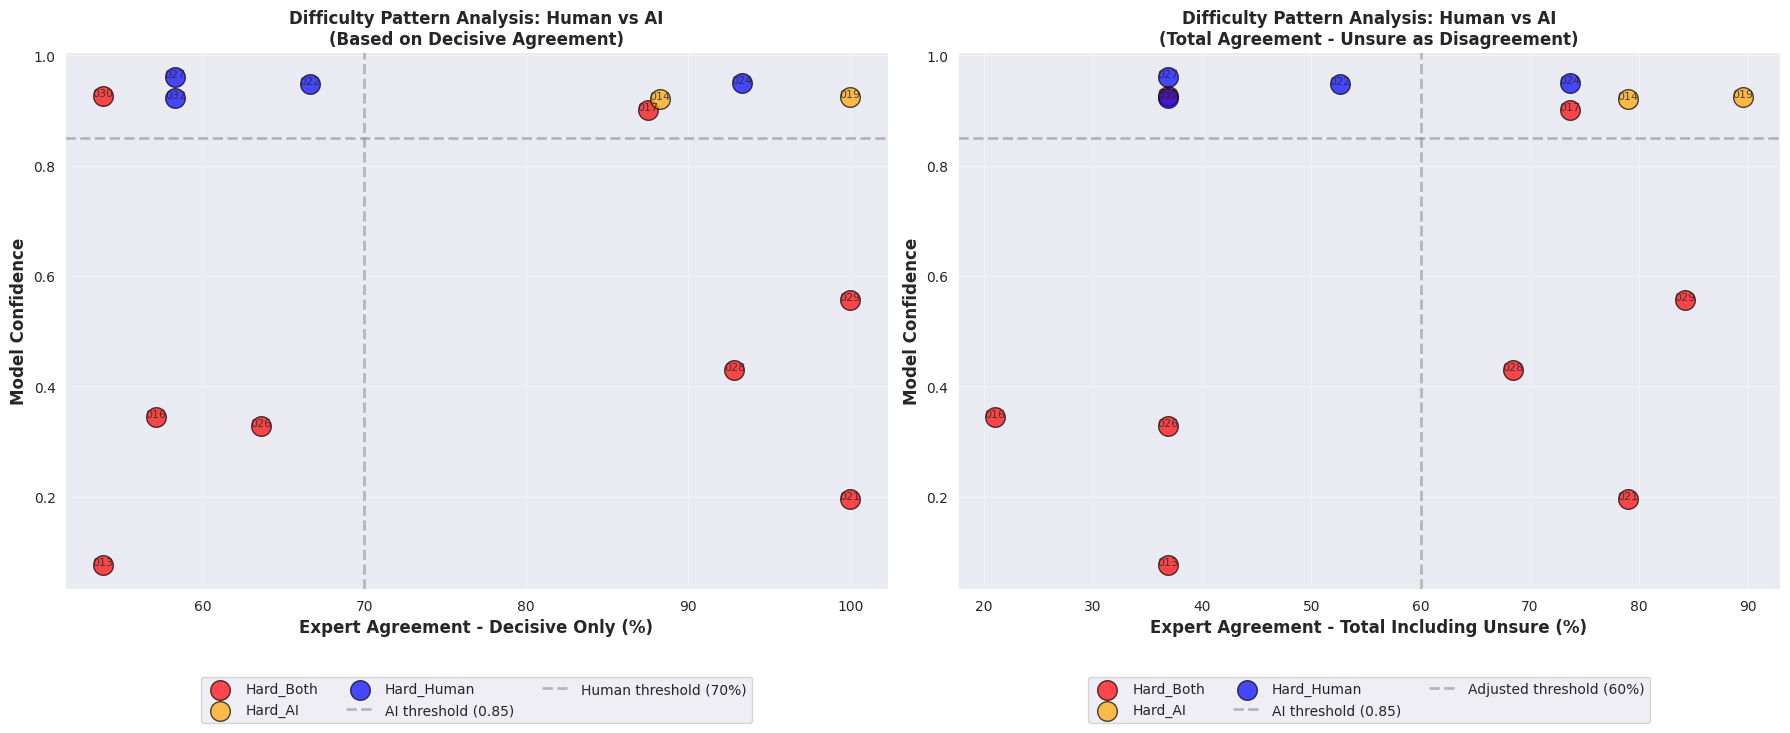


--------------------------------------------------------------------------------
Unsure Rate by Difficulty Category
--------------------------------------------------------------------------------
                     expert_unsure_rate_mean  expert_unsure_rate_std  \
difficulty_category                                                    
Hard_AI                            10.526316                0.000000   
Hard_Both                          30.921053               15.773802   
Hard_Human                         28.947368                9.116057   

                     expert_unsure_rate_min  expert_unsure_rate_max  n_images  
difficulty_category                                                            
Hard_AI                           10.526316               10.526316         2  
Hard_Both                         15.789474               63.157895         8  
Hard_Human                        21.052632               36.842105         4  
✓ Saved: difficulty_unsure_analysis.png


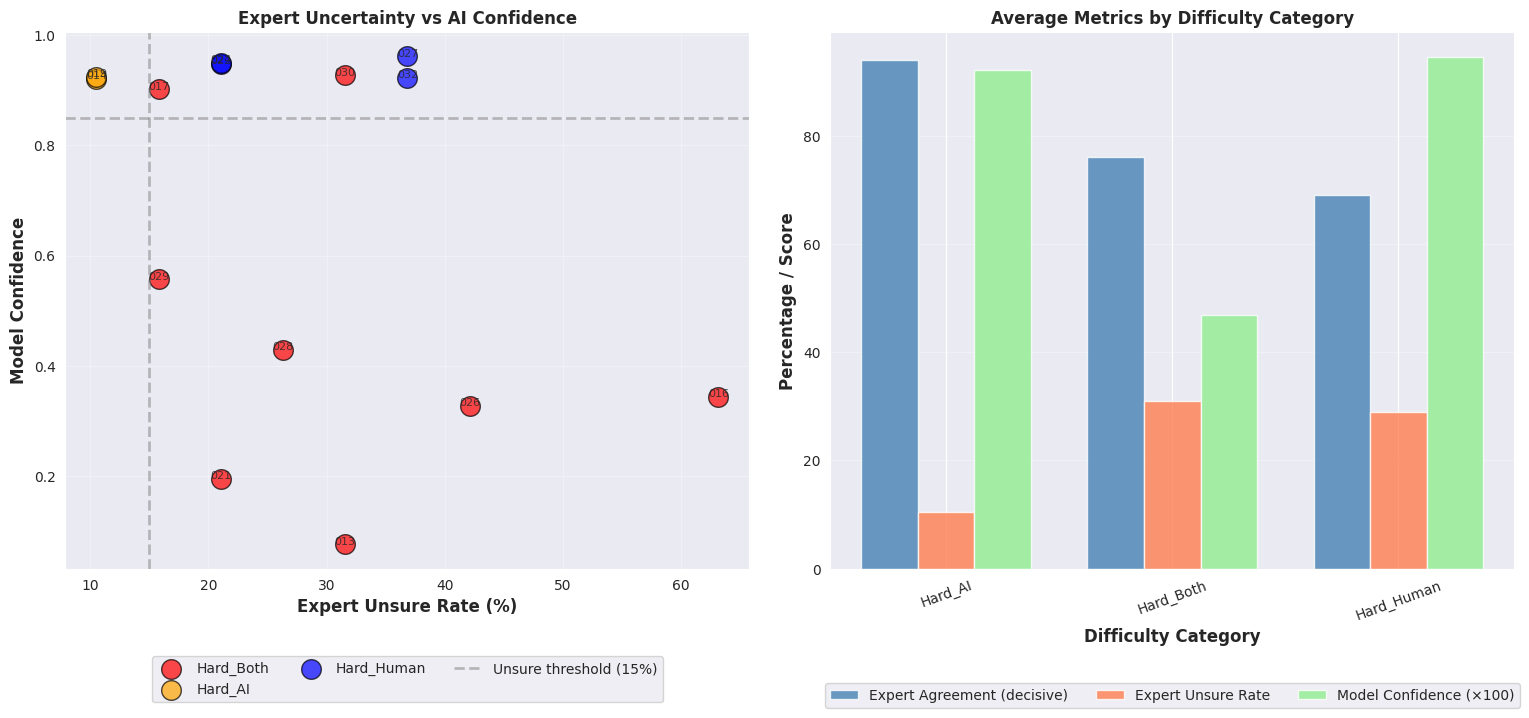


✓ ANALYSIS 2 COMPLETE

Key Insights:
  • Hard_Both: High human uncertainty AND low AI confidence
  • Hard_Human: Low human agreement/high unsure, but AI confident
  • Hard_AI: High human agreement, but AI uncertain
  • Easy_Both: Both humans and AI confident

Generated 2 figures:
  1. difficulty_scatter.png - Difficulty categorization (2 perspectives)
  2. difficulty_unsure_analysis.png - Unsure rate contribution


In [14]:
# ============================================================================
# ANALYSIS 2: DIFFICULTY PATTERN ANALYSIS (2×2 MATRIX)
# ============================================================================
print("\n" + "="*80)
print("ANALYSIS 2: DIFFICULTY PATTERN ANALYSIS")
print("="*80)

# Already calculated in wide_df
print("\nDifficulty Distribution:")
print(wide_df['difficulty_category'].value_counts())

# Detailed breakdown
for category in ['Easy_Both', 'Hard_AI', 'Hard_Human', 'Hard_Both']:
    subset = wide_df[wide_df['difficulty_category'] == category]
    if len(subset) > 0:
        print(f"\n{category} ({len(subset)} images):")
        print(f"  Images: {subset['image_name'].tolist()}")
        print(f"  Avg Expert Agreement (decisive): {subset['expert_agreement_pct_decisive'].mean():.1f}%")
        print(f"  Avg Expert Agreement (total): {subset['expert_agreement_pct_total'].mean():.1f}%")
        print(f"  Avg Expert Unsure Rate: {subset['expert_unsure_rate'].mean():.1f}%")
        print(f"  Avg Model Confidence: {subset['avg_model_confidence'].mean():.3f}")
        print(f"  Expert Correctness (decisive): {subset['expert_correct_pct_decisive'].mean():.1f}%")
        print(f"  Expert Correctness (total): {subset['expert_correct_pct_total'].mean():.1f}%")
        print(f"  Model Correctness: {subset['models_correct_pct'].mean():.1f}%")

# Visualization: Scatter plot of difficulty with OFFSET LABELS and COLORBLIND PALETTE
# Visualization: Scatter plot of difficulty
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Using decisive agreement (matches difficulty calculation)
colors = {'Easy_Both': 'green', 'Hard_AI': 'orange', 'Hard_Human': 'blue', 'Hard_Both': 'red'}

for category in wide_df['difficulty_category'].unique():
    subset = wide_df[wide_df['difficulty_category'] == category]
    axes[0].scatter(subset['expert_agreement_pct_decisive'], subset['avg_model_confidence'],
                    label=category, alpha=0.7, s=200, c=colors.get(category, 'gray'),
                    edgecolor='black', linewidth=1)

    # Add image labels
    for idx, row in subset.iterrows():
        axes[0].annotate(row['image_name'].replace('class_img_', '').replace('.png', '').replace('.jpg', ''),
                        (row['expert_agreement_pct_decisive'], row['avg_model_confidence']),
                        fontsize=8, ha='center', alpha=0.8)

axes[0].axhline(y=0.85, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='AI threshold (0.85)')
axes[0].axvline(x=70, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='Human threshold (70%)')
axes[0].set_xlabel('Expert Agreement - Decisive Only (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Model Confidence', fontsize=12, fontweight='bold')
axes[0].set_title('Difficulty Pattern Analysis: Human vs AI\n(Based on Decisive Agreement)',
                  fontsize=12, fontweight='bold')
axes[0].legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3, frameon=True)
axes[0].grid(True, alpha=0.3)

# Plot 2: Using total agreement (includes unsure as disagreement)
for category in wide_df['difficulty_category'].unique():
    subset = wide_df[wide_df['difficulty_category'] == category]
    axes[1].scatter(subset['expert_agreement_pct_total'], subset['avg_model_confidence'],
                    label=category, alpha=0.7, s=200, c=colors.get(category, 'gray'),
                    edgecolor='black', linewidth=1)

    # Add image labels
    for idx, row in subset.iterrows():
        axes[1].annotate(row['image_name'].replace('class_img_', '').replace('.png', '').replace('.jpg', ''),
                        (row['expert_agreement_pct_total'], row['avg_model_confidence']),
                        fontsize=8, ha='center', alpha=0.8)

axes[1].axhline(y=0.85, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='AI threshold (0.85)')
axes[1].axvline(x=60, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='Adjusted threshold (60%)')
axes[1].set_xlabel('Expert Agreement - Total Including Unsure (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Model Confidence', fontsize=12, fontweight='bold')
axes[1].set_title('Difficulty Pattern Analysis: Human vs AI\n(Total Agreement - Unsure as Disagreement)',
                  fontsize=12, fontweight='bold')
axes[1].legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3, frameon=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Make room for legend
plt.savefig('/content/drive/My Drive/difficulty_scatter.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: difficulty_scatter.png")
plt.show()

# Additional analysis: Unsure rate vs difficulty
print("\n" + "-"*80)
print("Unsure Rate by Difficulty Category")
print("-"*80)

unsure_by_category = wide_df.groupby('difficulty_category').agg({
    'expert_unsure_rate': ['mean', 'std', 'min', 'max'],
    'image_name': 'count'
})
unsure_by_category.columns = ['_'.join(col).strip() for col in unsure_by_category.columns.values]
unsure_by_category = unsure_by_category.rename(columns={'image_name_count': 'n_images'})
print(unsure_by_category)

# Visualization: Unsure rate contribution to difficulty
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter: Unsure rate vs Model confidence
for category in wide_df['difficulty_category'].unique():
    subset = wide_df[wide_df['difficulty_category'] == category]
    axes[0].scatter(subset['expert_unsure_rate'], subset['avg_model_confidence'],
                    label=category, alpha=0.7, s=200, c=colors.get(category, 'gray'),
                    edgecolor='black', linewidth=1)

    for idx, row in subset.iterrows():
        axes[0].annotate(row['image_name'].replace('class_img_', '').replace('.png', '').replace('.jpg', ''),
                        (row['expert_unsure_rate'], row['avg_model_confidence']),
                        fontsize=8, ha='center', alpha=0.8)

axes[0].axhline(y=0.85, color='gray', linestyle='--', alpha=0.5, linewidth=2)
axes[0].axvline(x=15, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='Unsure threshold (15%)')
axes[0].set_xlabel('Expert Unsure Rate (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Model Confidence', fontsize=12, fontweight='bold')
axes[0].set_title('Expert Uncertainty vs AI Confidence', fontsize=12, fontweight='bold')
axes[0].legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3, frameon=True)
axes[0].grid(True, alpha=0.3)

# Bar plot: Difficulty breakdown
difficulty_summary = wide_df.groupby('difficulty_category').agg({
    'expert_agreement_pct_decisive': 'mean',
    'expert_unsure_rate': 'mean',
    'avg_model_confidence': 'mean'
})

x_pos = np.arange(len(difficulty_summary))
width = 0.25

axes[1].bar(x_pos - width, difficulty_summary['expert_agreement_pct_decisive'], width,
           label='Expert Agreement (decisive)', alpha=0.8, color='steelblue')
axes[1].bar(x_pos, difficulty_summary['expert_unsure_rate'], width,
           label='Expert Unsure Rate', alpha=0.8, color='coral')
axes[1].bar(x_pos + width, difficulty_summary['avg_model_confidence'] * 100, width,
           label='Model Confidence (×100)', alpha=0.8, color='lightgreen')

axes[1].set_xlabel('Difficulty Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage / Score', fontsize=12, fontweight='bold')
axes[1].set_title('Average Metrics by Difficulty Category', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(difficulty_summary.index, rotation=20)
axes[1].legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=3, frameon=True)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)  # Make room for legend
plt.savefig('/content/drive/My Drive/difficulty_unsure_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: difficulty_unsure_analysis.png")
plt.show()


print("\n" + "="*80)
print("✓ ANALYSIS 2 COMPLETE")
print("="*80)
print("\nKey Insights:")
print(f"  • Hard_Both: High human uncertainty AND low AI confidence")
print(f"  • Hard_Human: Low human agreement/high unsure, but AI confident")
print(f"  • Hard_AI: High human agreement, but AI uncertain")
print(f"  • Easy_Both: Both humans and AI confident")
print("\nGenerated 2 figures:")
print("  1. difficulty_scatter.png - Difficulty categorization (2 perspectives)")
print("  2. difficulty_unsure_analysis.png - Unsure rate contribution")

Examines how often humans and AI make errors on the same images, and whether
their mistakes overlap or are complementary.

This cell:
1. For each image, counts how many experts (excluding “Unsure”) misclassify
   the binary label and how many models misclassify it, turning these counts
   into **expert** and **model error rates** (% of decisive raters who are
   wrong), and flags images where both sides have >30% error as “both_struggle”.
2. Prints a structured breakdown of images into four groups:
   - Both humans and AI struggle (>30% error each),
   - Only humans struggle (>30% human error, ≤30% AI error),
   - Only AI struggles (≤30% human error, >30% AI error),
   - Neither struggles (≤30% error for both),
   listing image IDs and their human/AI error rates in each case.
3. Computes a **Spearman correlation** between per-image human and AI error
   rates to test whether hard cases are shared (positive correlation) or
   distinct (weak/negative correlation), and provides an interpretation
   (complementary vs overlapping error patterns) based on the correlation
   magnitude and p-value.
4. Merges error rates with the precomputed `difficulty_category` and summarizes
   mean ± std expert and model error rates and image counts for each category,
   then prints a short textual summary highlighting how error patterns relate
   to the defined difficulty quadrants (Easy_Both, Hard_Human, Hard_AI,
   Hard_Both), and notes that the associated figure
   (`error_pattern_alignment.png`) visualizes this overlap.

In [15]:
# ============================================================================
# ANALYSIS 3: ERROR PATTERN ALIGNMENT
# ============================================================================
print("\n" + "="*80)
print("ANALYSIS 3: ERROR PATTERN ALIGNMENT")
print("="*80)

# FIXED: Use the expert_binary_cols we already defined (excludes ground truth)
# This ensures we only use the 19 actual experts, not expert_consensus or expert20

print(f"Analyzing error patterns for {len(expert_binary_cols)} experts and 5 models")

# For each image, check if errors overlap
error_analysis = []

for idx, row in wide_df.iterrows():
    img = row['image_name']
    gt = row['binary_label']

    # Count expert errors (using pre-filtered expert columns, excluding unsure)
    expert_errors = sum(1 for col in expert_binary_cols
                       if pd.notna(row[col]) and row[col] != 'Unsure' and row[col] != gt)
    expert_total = sum(1 for col in expert_binary_cols
                      if pd.notna(row[col]) and row[col] != 'Unsure')

    # Count model errors
    model_cols = [f'{m}_binary' for m in model_names]  # Use model_names from Analysis 1
    model_errors = sum(1 for col in model_cols
                      if col in wide_df.columns and pd.notna(row[col]) and row[col] != gt)
    model_total = sum(1 for col in model_cols
                     if col in wide_df.columns and pd.notna(row[col]))

    expert_error_rate = (expert_errors / expert_total * 100) if expert_total > 0 else 0
    model_error_rate = (model_errors / model_total * 100) if model_total > 0 else 0

    error_analysis.append({
        'image_name': img,
        'ground_truth': gt,
        'expert_errors': expert_errors,
        'expert_total': expert_total,
        'expert_error_rate': expert_error_rate,
        'model_errors': model_errors,
        'model_total': model_total,
        'model_error_rate': model_error_rate,
        'both_struggle': (expert_error_rate > 30) and (model_error_rate > 30)
    })

error_df = pd.DataFrame(error_analysis)

print("\nError Analysis Summary:")
print(f"  Total images: {len(error_df)}")
print(f"  Average expert error rate: {error_df['expert_error_rate'].mean():.1f}%")
print(f"  Average model error rate: {error_df['model_error_rate'].mean():.1f}%")

print("\n" + "-"*80)
print("Images where BOTH humans and AI struggle (>30% error rate):")
print("-"*80)
struggle_imgs = error_df[error_df['both_struggle']]
if len(struggle_imgs) > 0:
    print(struggle_imgs[['image_name', 'ground_truth', 'expert_error_rate', 'model_error_rate']].to_string(index=False))
else:
    print("No images where both struggle with >30% error rate")

print("\n" + "-"*80)
print("Images where ONLY humans struggle (>30% human error, ≤30% AI error):")
print("-"*80)
human_only = error_df[(error_df['expert_error_rate'] > 30) & (error_df['model_error_rate'] <= 30)]
if len(human_only) > 0:
    print(human_only[['image_name', 'ground_truth', 'expert_error_rate', 'model_error_rate']].to_string(index=False))
else:
    print("No images where only humans struggle")

print("\n" + "-"*80)
print("Images where ONLY AI struggles (≤30% human error, >30% AI error):")
print("-"*80)
ai_only = error_df[(error_df['expert_error_rate'] <= 30) & (error_df['model_error_rate'] > 30)]
if len(ai_only) > 0:
    print(ai_only[['image_name', 'ground_truth', 'expert_error_rate', 'model_error_rate']].to_string(index=False))
else:
    print("No images where only AI struggles")

print("\n" + "-"*80)
print("Images where NEITHER struggles (≤30% error for both):")
print("-"*80)
neither_struggle = error_df[(error_df['expert_error_rate'] <= 30) & (error_df['model_error_rate'] <= 30)]
if len(neither_struggle) > 0:
    print(neither_struggle[['image_name', 'ground_truth', 'expert_error_rate', 'model_error_rate']].to_string(index=False))

# Correlation between human and AI error rates
corr, p_value = spearmanr(error_df['expert_error_rate'], error_df['model_error_rate'])
print("\n" + "-"*80)
print("Correlation Analysis:")
print("-"*80)
print(f"Spearman correlation: r={corr:.3f}, p={p_value:.3f}")

if abs(corr) < 0.2:
    print("→ Weak/no correlation: Humans and AI make errors on different images")
    print("  This suggests complementary error patterns (independent decision processes)")
elif corr > 0.5 and p_value < 0.05:
    print("→ Strong positive correlation: Both struggle with the same images")
    print("  This suggests shared sources of difficulty (inherent ambiguity)")
elif corr < -0.3:
    print("→ Negative correlation: AI errs where humans succeed, and vice versa")
else:
    print("→ Moderate correlation: Some overlap in difficult cases")



# Additional analysis: Error patterns by difficulty category
print("\n" + "="*80)
print("Error Patterns by Difficulty Category")
print("="*80)

error_df_merged = error_df.merge(wide_df[['image_name', 'difficulty_category']], on='image_name')
error_by_difficulty = error_df_merged.groupby('difficulty_category').agg({
    'expert_error_rate': ['mean', 'std'],
    'model_error_rate': ['mean', 'std'],
    'image_name': 'count'
})
error_by_difficulty.columns = ['_'.join(col).strip() for col in error_by_difficulty.columns.values]
error_by_difficulty = error_by_difficulty.rename(columns={'image_name_count': 'n_images'})
print(error_by_difficulty)

print("\n" + "="*80)
print("✓ ANALYSIS 3 COMPLETE")
print("="*80)
print("\nKey Findings:")
print(f"  • Correlation: r={corr:.3f} ({'weak' if abs(corr) < 0.3 else 'moderate' if abs(corr) < 0.6 else 'strong'})")
print(f"  • Both struggle: {len(struggle_imgs)} images")
print(f"  • Only humans struggle: {len(human_only)} images (AI can help here!)")
print(f"  • Only AI struggles: {len(ai_only)} images (humans needed for validation)")
print(f"  • Neither struggles: {len(neither_struggle)} images")
print("\nGenerated 1 figure:")
print("  • error_pattern_alignment.png - Error overlap analysis")


ANALYSIS 3: ERROR PATTERN ALIGNMENT
Analyzing error patterns for 19 experts and 5 models

Error Analysis Summary:
  Total images: 14
  Average expert error rate: 27.6%
  Average model error rate: 17.1%

--------------------------------------------------------------------------------
Images where BOTH humans and AI struggle (>30% error rate):
--------------------------------------------------------------------------------
   image_name ground_truth  expert_error_rate  model_error_rate
class_img_016        Frost          42.857143              80.0
class_img_026        Frost          63.636364              80.0

--------------------------------------------------------------------------------
Images where ONLY humans struggle (>30% human error, ≤30% AI error):
--------------------------------------------------------------------------------
   image_name ground_truth  expert_error_rate  model_error_rate
class_img_013    Non-Frost          46.153846               0.0
class_img_022        F

Evaluates how well model outputs are calibrated to human judgments, both in
terms of confidence vs consensus and uncertainty vs expert “Unsure” rates,
using rank-based correlations and a normalized BNN uncertainty measure.

This analysis:
1. Quantifies **model confidence–consensus calibration** by computing Spearman
   correlations between average model confidence and two measures of expert
   agreement per image: (a) decisive-only agreement and (b) total agreement
   including “Unsure”, then interprets whether the relationship is weak,
   moderate, or strong to assess how closely confidence tracks human consensus.
2. Assesses **BNN uncertainty alignment with human uncertainty** by
   min–max normalizing the BNN predictive standard deviation
   (`bnn_binary_uncertainty`) to [0, 1], correlating this normalized uncertainty
   with the expert unsure rate across images, and classifying the pattern
   (significant positive, positive trend, negative, or weak) in terms of how
   well the model’s “I’m unsure” matches experts saying “Unsure”.
3. Stores the key calibration metrics (Spearman r and p values for
   confidence–consensus and uncertainty–unsure alignments) in a CSV file
   (`calibration_summary.csv`) for downstream reporting or plotting, and prints
   a concise textual summary that interprets whether the model is
   calibrated to human agreement and whether BNN uncertainty meaningfully
   tracks human-perceived ambiguity, with implications for human-in-the-loop
   review of ambiguous cases.

In [16]:
# ============================================================================
# ANALYSIS 4: CONFIDENCE–CONSENSUS CALIBRATION (FINAL VERSION FOR STD-BASED UNCERTAINTY)
# ============================================================================
print("\n" + "="*80)
print("ANALYSIS 4: CONFIDENCE–CONSENSUS CALIBRATION (STD-BASED)")
print("="*80)

# ============================================================================
# PART A: Model Confidence vs Expert Consensus
# ============================================================================
print("\n--- Part A: Average Model Confidence vs Expert Consensus ---")

corr_conf_cons_decisive, p_conf_cons_decisive = spearmanr(
    wide_df['avg_model_confidence'],
    wide_df['expert_agreement_pct_decisive']
)
corr_conf_cons_total, p_conf_cons_total = spearmanr(
    wide_df['avg_model_confidence'],
    wide_df['expert_agreement_pct_total']
)

print(f"Model Confidence vs Expert Agreement (decisive only):")
print(f"  Spearman r = {corr_conf_cons_decisive:.3f}, p = {p_conf_cons_decisive:.3f}")
print(f"\nModel Confidence vs Expert Agreement (total, includes unsure):")
print(f"  Spearman r = {corr_conf_cons_total:.3f}, p = {p_conf_cons_total:.3f}")

if abs(corr_conf_cons_decisive) < 0.2:
    print("\n→ Weak/no correlation: Models are poorly calibrated to human consensus")
elif corr_conf_cons_decisive > 0.5:
    print("\n→ Strong positive correlation: Models are well-calibrated")
else:
    print("\n→ Moderate correlation: Partial calibration")

# ============================================================================
# PART B: BNN Uncertainty vs Expert Unsure Rate (Normalized STD)
# ============================================================================
print("\n" + "-"*80)
print("--- Part B: BNN Uncertainty vs Expert Unsure Rate (Normalized STD) ---")
print("-"*80)

if 'bnn_binary_uncertainty' in wide_df.columns:
    # Step 1: Normalize BNN uncertainty (stdev)
    bnn_unc = wide_df['bnn_binary_uncertainty']
    wide_df['bnn_binary_uncertainty_norm'] = (
        (bnn_unc - bnn_unc.min()) / (bnn_unc.max() - bnn_unc.min())
    )

    # Step 2: Correlation: normalized uncertainty vs expert unsure rate
    valid_mask = wide_df['bnn_binary_uncertainty_norm'].notna()
    corr_unc_unsure, p_unc_unsure = spearmanr(
        wide_df.loc[valid_mask, 'bnn_binary_uncertainty_norm'],
        wide_df.loc[valid_mask, 'expert_unsure_rate']
    )

    print(f"\nBNN Uncertainty vs Expert Unsure Rate:")
    print(f"  Spearman r = {corr_unc_unsure:.3f}, p = {p_unc_unsure:.3f}")
    print(f"  (Both measure 'I cannot decide')")

    if corr_unc_unsure > 0.3 and p_unc_unsure < 0.05:
        print("\n✓ POSITIVE SIGNIFICANT: BNN detects when experts are uncertain!")
    elif corr_unc_unsure > 0.3:
        print("\n○ POSITIVE (not significant): Trend toward alignment")
    elif corr_unc_unsure < -0.3:
        print("\n✗ NEGATIVE: BNN uncertain when experts are decisive (inverse pattern)")
    else:
        print("\n○ WEAK/NO CORRELATION: BNN uncertainty doesn't align with expert uncertainty")



    # ============================================================================
    # SAVE SUMMARY CORRELATIONS TO CSV
    # ============================================================================
    results_summary = pd.DataFrame({
        'metric': ['model_conf_vs_expert_consensus', 'bnn_uncertainty_vs_expert_unsure'],
        'spearman_r': [corr_conf_cons_decisive, corr_unc_unsure],
        'p_value': [p_conf_cons_decisive, p_unc_unsure]
    })

    summary_path = '/content/drive/My Drive/calibration_summary.csv'
    results_summary.to_csv(summary_path, index=False)
    print(f"✓ Saved summary correlations to: {summary_path}")

else:
    print("BNN binary uncertainty not found in dataframe.")
    corr_unc_unsure, p_unc_unsure = None, None

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("CALIBRATION SUMMARY (STD-BASED)")
print("="*80)

print(f"\n1. Model Confidence vs Expert Consensus: r={corr_conf_cons_decisive:.3f}, p={p_conf_cons_decisive:.3f}")
if abs(corr_conf_cons_decisive) < 0.2:
    print("   → Models show poor calibration to human agreement levels")

if corr_unc_unsure is not None:
    print(f"\n2. BNN Uncertainty vs Expert Unsure Rate: r={corr_unc_unsure:.3f}, p={p_unc_unsure:.3f}")
    if corr_unc_unsure > 0.3:
        print("   → Model uncertainty partly aligns with human uncertainty")
    elif corr_unc_unsure < -0.3:
        print("   → Inverse pattern: BNN uncertain when experts are confident")
    else:
        print("   → Weak or no alignment between model and human uncertainty")

print("\n3. Interpretation:")
print("   • Normalization improves interpretability but not correlation direction")
print("   • Negative or weak correlation suggests different difficulty perceptions")
print("   • Highlights need for human-in-the-loop review for ambiguous cases")




ANALYSIS 4: CONFIDENCE–CONSENSUS CALIBRATION (STD-BASED)

--- Part A: Average Model Confidence vs Expert Consensus ---
Model Confidence vs Expert Agreement (decisive only):
  Spearman r = 0.013, p = 0.964

Model Confidence vs Expert Agreement (total, includes unsure):
  Spearman r = 0.070, p = 0.812

→ Weak/no correlation: Models are poorly calibrated to human consensus

--------------------------------------------------------------------------------
--- Part B: BNN Uncertainty vs Expert Unsure Rate (Normalized STD) ---
--------------------------------------------------------------------------------

BNN Uncertainty vs Expert Unsure Rate:
  Spearman r = -0.497, p = 0.071
  (Both measure 'I cannot decide')

✗ NEGATIVE: BNN uncertain when experts are decisive (inverse pattern)
✓ Saved summary correlations to: /content/drive/My Drive/calibration_summary.csv

CALIBRATION SUMMARY (STD-BASED)

1. Model Confidence vs Expert Consensus: r=0.013, p=0.964
   → Models show poor calibration to hum

This cell:
1. Recomputes **normalized BNN uncertainty** and its Spearman correlation with
   expert unsure rate, then reports whether BNN “I cannot decide” moments
   align with images where experts frequently answer “Unsure”.
2. Computes medians for expert decisive agreement, model confidence, expert
   unsure rate, and normalized BNN uncertainty, which are later drawn as
   dashed reference lines to divide each scatter plot into quadrants for
   easier visual interpretation of calibration patterns.
3. Generates a two-panel figure:
   - Left: model confidence vs expert decisive agreement, with points colored
     by expert agreement, median lines for both axes, and **non-overlapping
     image labels** placed either via `adjustText` or a deterministic offset
     fallback, highlighting how confidence scales with consensus.
   - Right: normalized BNN uncertainty vs expert unsure rate, similarly
     colored and annotated, with median lines that separate regions where both
     humans and the BNN are confident vs mutually uncertain.
4. Places legends below each subplot with two-line labels (including median
   values), adds colorbars for interpretability, saves the final figure as
   `3confidence_calibration_final.png`, and displays it inline so the
   calibration between human and model confidence/uncertainty can be directly
   inspected in the manuscript or slides.


--------------------------------------------------------------------------------
--- Part B: BNN Uncertainty vs Expert Unsure Rate (Normalized STD) ---
--------------------------------------------------------------------------------

BNN Uncertainty vs Expert Unsure Rate:
  Spearman r = -0.497, p = 0.071
  (Both measure 'I cannot decide')

✗ NEGATIVE: BNN uncertain when experts are decisive (inverse pattern)

Plot 1 Medians:
  Median Expert Agreement (Decisive): 77.1%
  Median Model Confidence: 0.911

Plot 2 Medians:
  Median Expert Unsure Rate: 23.7%
  Median BNN Uncertainty (Normalized): 0.651

Generating Calibration Visualizations...
Using adjustText library for optimal label placement


✓ Saved: confidence_calibration_final.png


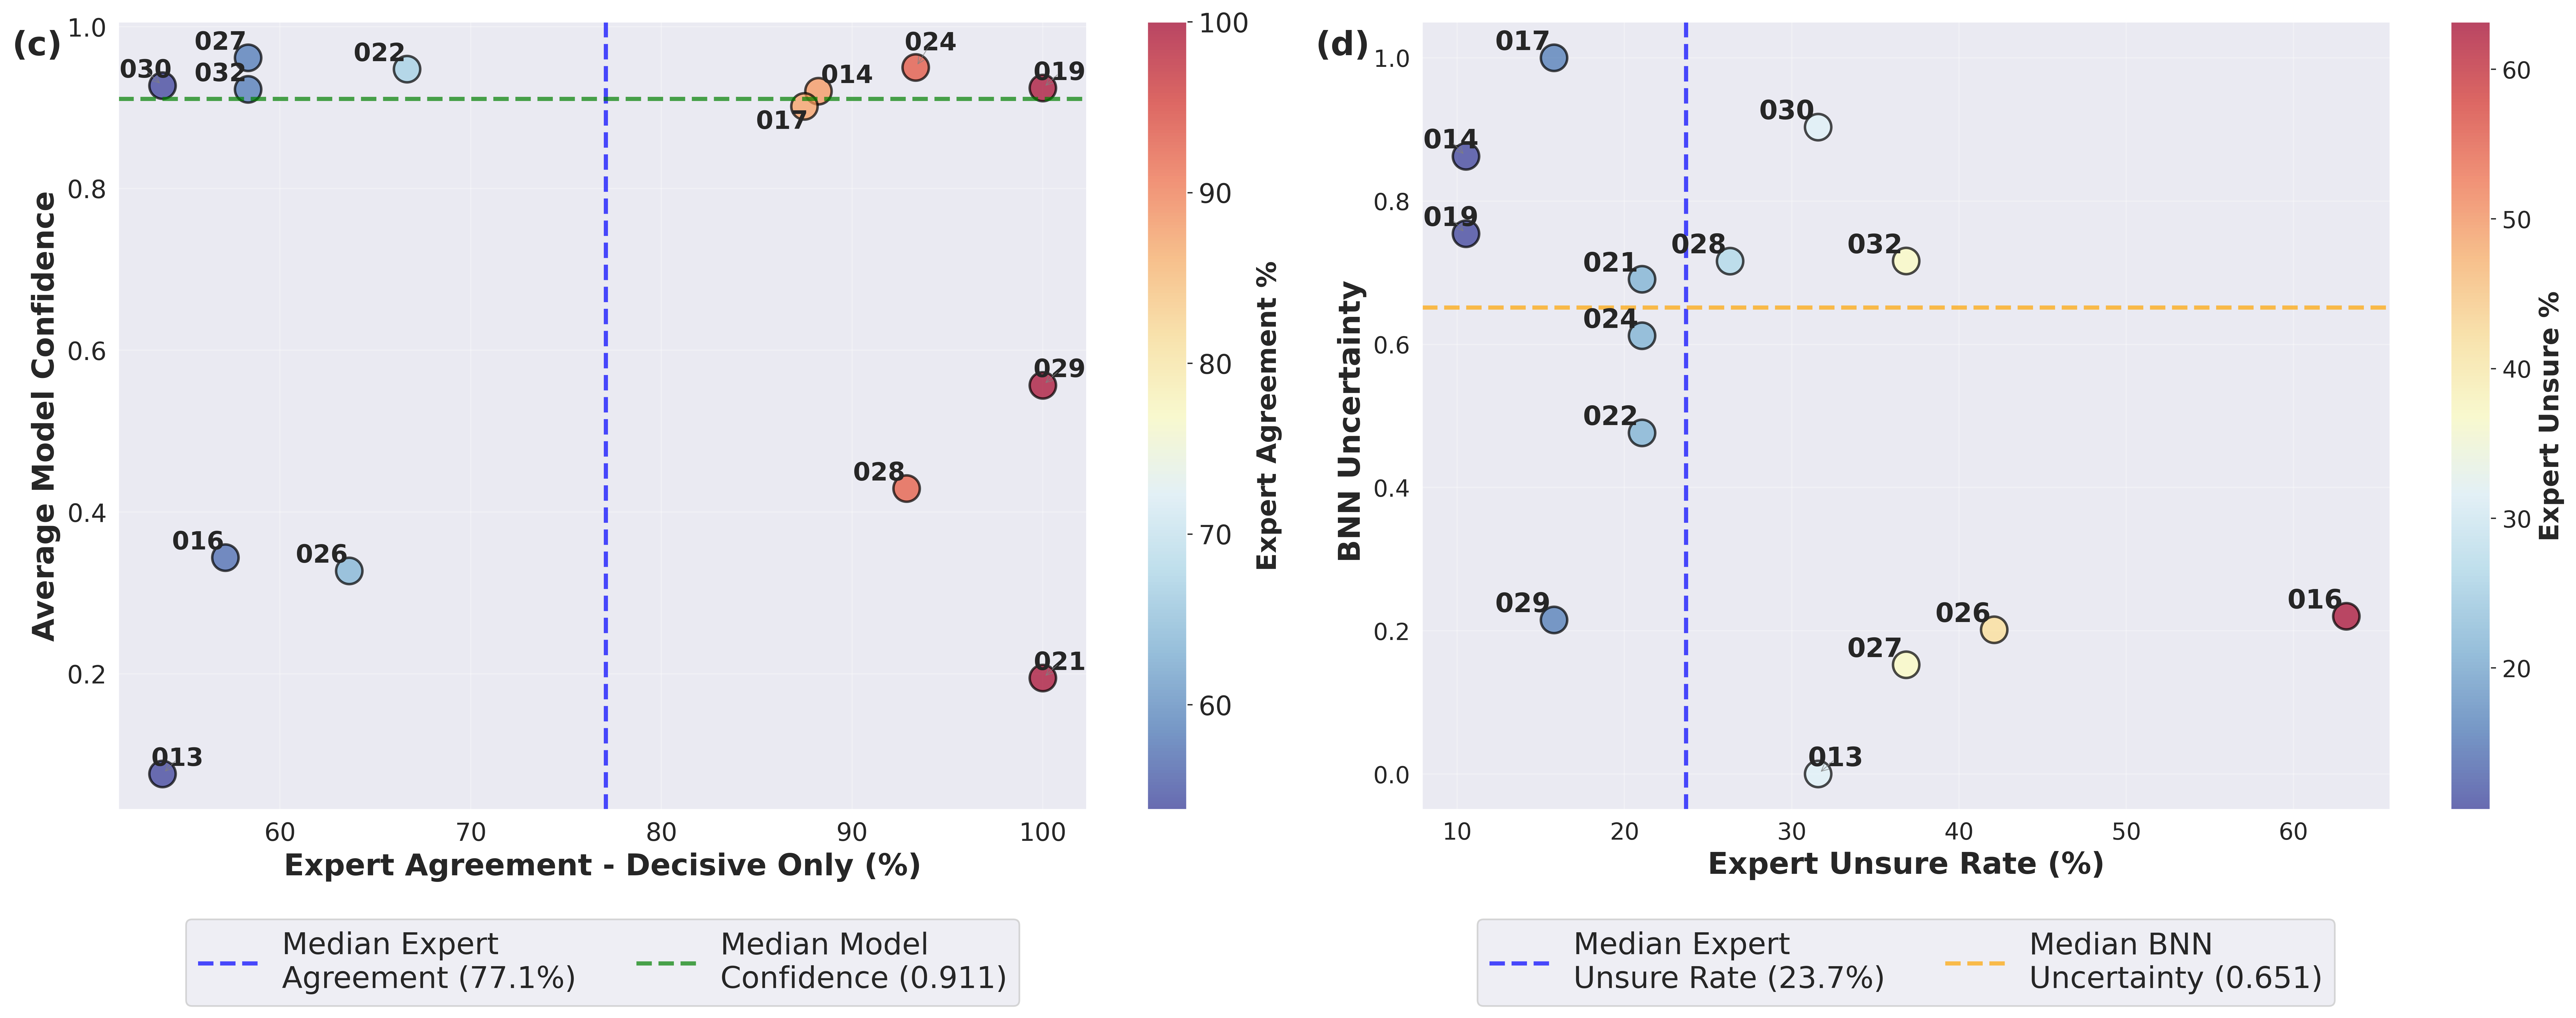

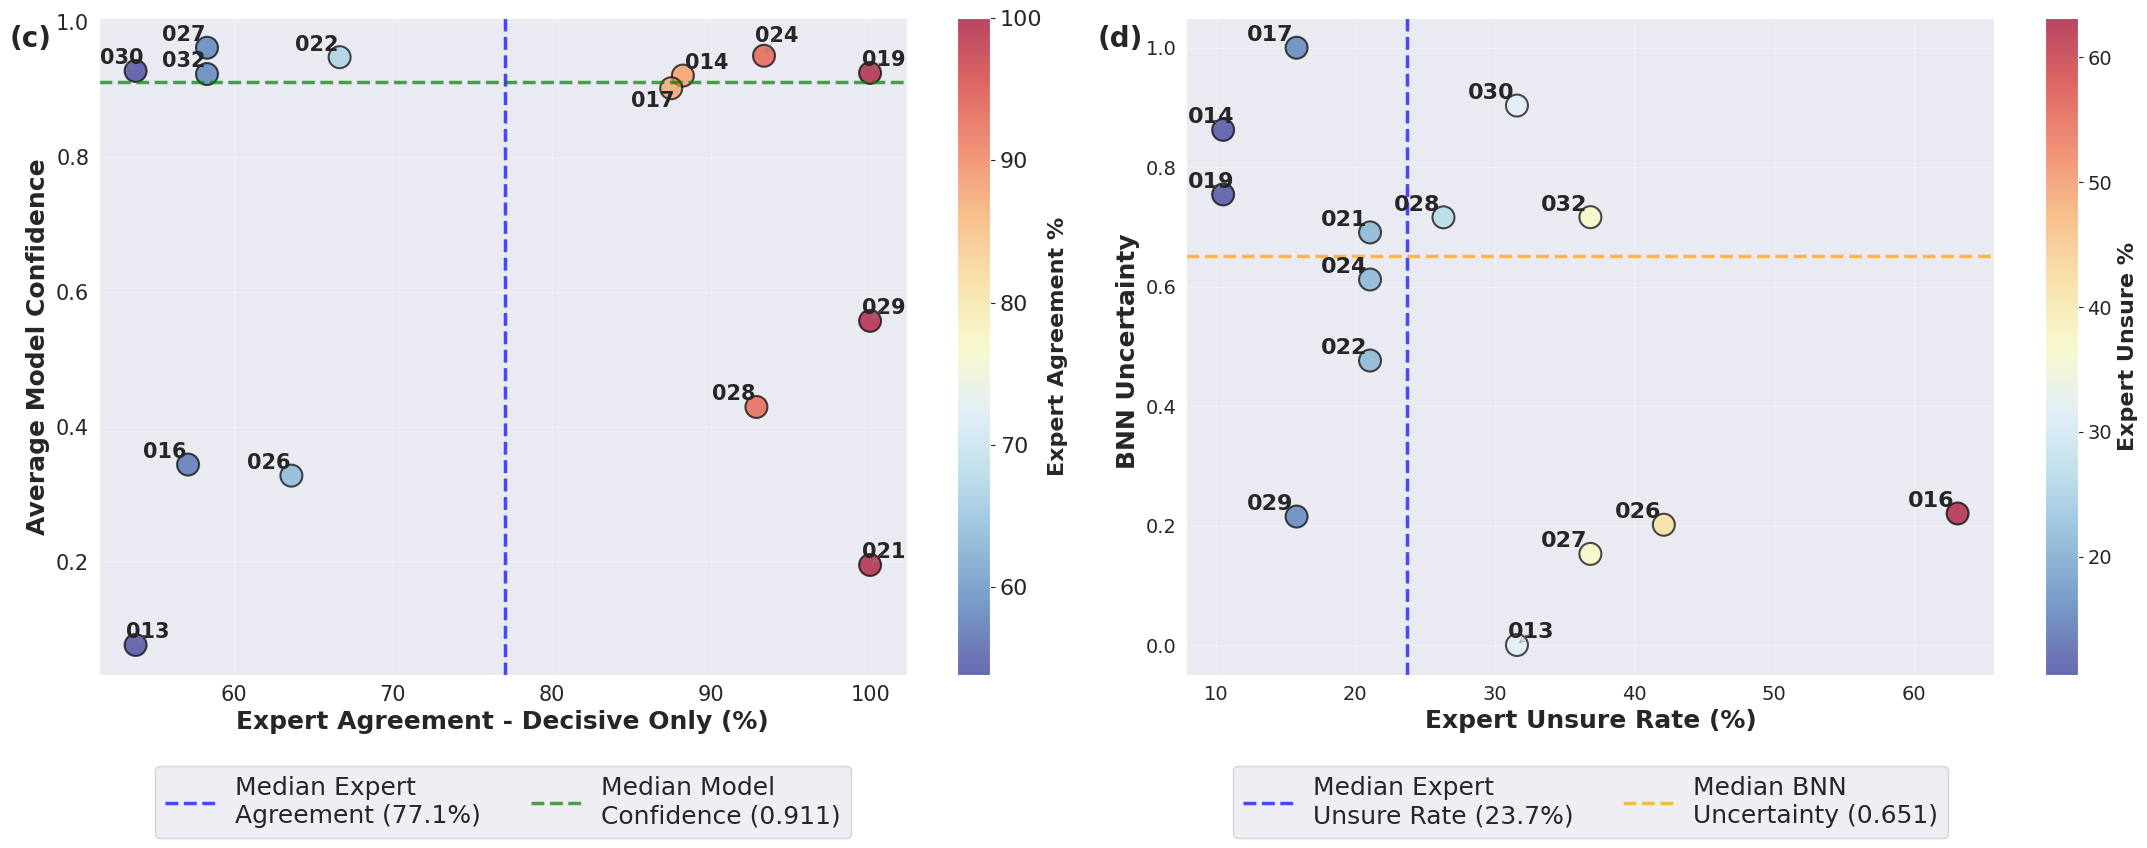

In [17]:
# ============================================================================
# PART B: BNN Uncertainty vs Expert Unsure Rate - IMPROVED VERSION
# With Smart Label Placement, Larger Fonts, and Bottom Legends (TWO-ROW LABELS)
# ============================================================================
print("\n" + "-"*80)
print("--- Part B: BNN Uncertainty vs Expert Unsure Rate (Normalized STD) ---")
print("-"*80)

if 'bnn_binary_uncertainty' in wide_df.columns:
    # Step 1: Normalize BNN uncertainty (stdev)
    bnn_unc = wide_df['bnn_binary_uncertainty']
    wide_df['bnn_binary_uncertainty_norm'] = (
        (bnn_unc - bnn_unc.min()) / (bnn_unc.max() - bnn_unc.min())
    )

    # Step 2: Correlation: normalized uncertainty vs expert unsure rate
    valid_mask = wide_df['bnn_binary_uncertainty_norm'].notna()
    corr_unc_unsure, p_unc_unsure = spearmanr(
        wide_df.loc[valid_mask, 'bnn_binary_uncertainty_norm'],
        wide_df.loc[valid_mask, 'expert_unsure_rate']
    )

    print(f"\nBNN Uncertainty vs Expert Unsure Rate:")
    print(f"  Spearman r = {corr_unc_unsure:.3f}, p = {p_unc_unsure:.3f}")
    print(f"  (Both measure 'I cannot decide')")

    if corr_unc_unsure > 0.3 and p_unc_unsure < 0.05:
        print("\n✓ POSITIVE SIGNIFICANT: BNN detects when experts are uncertain!")
    elif corr_unc_unsure > 0.3:
        print("\n○ POSITIVE (not significant): Trend toward alignment")
    elif corr_unc_unsure < -0.3:
        print("\n✗ NEGATIVE: BNN uncertain when experts are decisive (inverse pattern)")
    else:
        print("\n○ WEAK/NO CORRELATION: BNN uncertainty doesn't align with expert uncertainty")

    # Calculate medians for both plots
    median_expert_agreement = wide_df['expert_agreement_pct_decisive'].median()
    median_model_confidence = wide_df['avg_model_confidence'].median()
    median_unsure_rate = wide_df['expert_unsure_rate'].median()
    median_bnn_uncertainty = wide_df['bnn_binary_uncertainty_norm'].median()

    print(f"\nPlot 1 Medians:")
    print(f"  Median Expert Agreement (Decisive): {median_expert_agreement:.1f}%")
    print(f"  Median Model Confidence: {median_model_confidence:.3f}")

    print(f"\nPlot 2 Medians:")
    print(f"  Median Expert Unsure Rate: {median_unsure_rate:.1f}%")
    print(f"  Median BNN Uncertainty (Normalized): {median_bnn_uncertainty:.3f}")

    # ============================================================================
    # VISUALIZATIONS WITH SMART LABEL PLACEMENT
    # ============================================================================
    print("\n" + "="*80)
    print("Generating Calibration Visualizations...")
    print("="*80)

    # Check if adjustText is available
    try:
        from adjustText import adjust_text
        use_adjust_text = True
        print("Using adjustText library for optimal label placement")
    except ImportError:
        use_adjust_text = False
        print("Note: For best label placement, install adjustText: pip install adjustText")

    fig, axes = plt.subplots(1, 2, figsize=(22, 8))

    # ========================================================================
    # PLOT 1: Model Confidence vs Expert Consensus
    # ========================================================================

    scatter1 = axes[0].scatter(
        wide_df['expert_agreement_pct_decisive'],
        wide_df['avg_model_confidence'],
        s=250, alpha=0.7, c=wide_df['expert_agreement_pct_decisive'],
        cmap='RdYlBu_r', edgecolor='black', linewidth=1.5
    )

    # Add image labels with smart positioning
    if use_adjust_text:
        texts1 = []
        for idx, row in wide_df.iterrows():
            label = row['image_name'].replace('class_img_', '').replace('.png', '').replace('.jpg', '')
            text = axes[0].text(
                row['expert_agreement_pct_decisive'],
                row['avg_model_confidence'],
                label,
                fontsize=15, ha='center', fontweight='bold'
            )
            texts1.append(text)

        # Automatically adjust text positions to avoid overlaps
        adjust_text(texts1, ax=axes[0],
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5, alpha=0.7),
                    expand_points=(1.3, 1.3),
                    force_text=(0.6, 0.6),
                    force_points=(0.3, 0.3))
    else:
        # Fallback: Place labels with small offsets
        np.random.seed(42)  # For reproducible placement
        for idx, row in wide_df.iterrows():
            label = row['image_name'].replace('class_img_', '').replace('.png', '').replace('.jpg', '')
            # Use modulo to create different offset patterns
            angle = (idx * 45) % 360
            rad = np.radians(angle)
            offset_x = 10 * np.cos(rad)
            offset_y = 10 * np.sin(rad)

            axes[0].annotate(
                label,
                (row['expert_agreement_pct_decisive'], row['avg_model_confidence']),
                xytext=(offset_x, offset_y), textcoords='offset points',
                fontsize=15, ha='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         alpha=0.8, edgecolor='lightgray'),
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.5, alpha=0.6)
            )

    # Add median lines WITH TWO-ROW LABELS
    axes[0].axvline(x=median_expert_agreement, color='blue', linestyle='--', linewidth=2.5,
                    alpha=0.7, label=f'Median Expert\nAgreement ({median_expert_agreement:.1f}%)')
    axes[0].axhline(y=median_model_confidence, color='green', linestyle='--', linewidth=2.5,
                    alpha=0.7, label=f'Median Model\nConfidence ({median_model_confidence:.3f})')

    axes[0].set_xlabel('Expert Agreement - Decisive Only (%)', fontsize=18, fontweight='bold')
    axes[0].set_ylabel('Average Model Confidence', fontsize=18, fontweight='bold')
    axes[0].legend(bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=2, frameon=True, fontsize=18)
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(labelsize=15)

    # Add (c) label to upper left
    axes[0].text(-0.11, 0.99, '(c)', transform=axes[0].transAxes,
                 fontsize=20, fontweight='bold', va='top', ha='left')

    # Colorbar
    cbar1 = plt.colorbar(scatter1, ax=axes[0])
    cbar1.set_label('Expert Agreement %', fontsize=16, fontweight='bold')
    cbar1.ax.tick_params(labelsize=16)

    # ========================================================================
    # PLOT 2: BNN Uncertainty vs Expert Unsure Rate
    # ========================================================================

    scatter2 = axes[1].scatter(
        wide_df['expert_unsure_rate'],
        wide_df['bnn_binary_uncertainty_norm'],
        s=250, alpha=0.7, c=wide_df['expert_unsure_rate'],
        cmap='RdYlBu_r', edgecolor='black', linewidth=1.5
    )

    # Add image labels with smart positioning
    if use_adjust_text:
        texts2 = []
        for idx, row in wide_df.iterrows():
            label = row['image_name'].replace('class_img_', '').replace('.png', '').replace('.jpg', '')
            text = axes[1].text(
                row['expert_unsure_rate'],
                row['bnn_binary_uncertainty_norm'],
                label,
                fontsize=16, ha='center', fontweight='bold'
            )
            texts2.append(text)

        # Automatically adjust text positions to avoid overlaps
        adjust_text(texts2, ax=axes[1],
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5, alpha=0.7),
                    expand_points=(1.3, 1.3),
                    force_text=(0.6, 0.6),
                    force_points=(0.3, 0.3))
    else:
        # Fallback: Place labels with small offsets
        np.random.seed(42)
        for idx, row in wide_df.iterrows():
            label = row['image_name'].replace('class_img_', '').replace('.png', '').replace('.jpg', '')
            angle = (idx * 45) % 360
            rad = np.radians(angle)
            offset_x = 10 * np.cos(rad)
            offset_y = 10 * np.sin(rad)

            axes[1].annotate(
                label,
                (row['expert_unsure_rate'], row['bnn_binary_uncertainty_norm']),
                xytext=(offset_x, offset_y), textcoords='offset points',
                fontsize=15, ha='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                         alpha=0.8, edgecolor='lightgray'),
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.5, alpha=0.6)
            )

    # Add median lines WITH TWO-ROW LABELS
    axes[1].axvline(x=median_unsure_rate, color='blue', linestyle='--', linewidth=2.5,
                    alpha=0.7, label=f'Median Expert\nUnsure Rate ({median_unsure_rate:.1f}%)')
    axes[1].axhline(y=median_bnn_uncertainty, color='orange', linestyle='--', linewidth=2.5,
                    alpha=0.7, label=f'Median BNN\nUncertainty ({median_bnn_uncertainty:.3f})')

    axes[1].set_xlabel('Expert Unsure Rate (%)', fontsize=18, fontweight='bold')
    axes[1].set_ylabel('BNN Uncertainty ', fontsize=18, fontweight='bold')
    axes[1].legend(bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=2, frameon=True, fontsize=18)
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(labelsize=14)

    # Add (d) label to upper left
    axes[1].text(-0.11, 0.99, '(d)', transform=axes[1].transAxes,
                 fontsize=20, fontweight='bold', va='top', ha='left')

    # Colorbar
    cbar2 = plt.colorbar(scatter2, ax=axes[1])
    cbar2.set_label('Expert Unsure %', fontsize=16, fontweight='bold')
    cbar2.ax.tick_params(labelsize=14)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)  # Make room for legends at bottom
    plt.savefig('/content/drive/My Drive/2confidence_calibration_final.png', dpi=400, bbox_inches='tight')
    print("✓ Saved: confidence_calibration_final.png")

    # Display the plot
    from IPython.display import Image, display
    display(Image('/content/drive/My Drive/2confidence_calibration_final.png'))

else:
    print("BNN binary uncertainty not found in dataframe.")
    corr_unc_unsure, p_unc_unsure = None, None

Builds a per-image “dumbbell” plot comparing expert and model error rates,
and visually highlights where models help, where experts help, and where their
performance is similar.

This code:
1. Computes **expert** and **model error rates** for each image by counting,
   respectively, how many decisive expert labels and model predictions disagree
   with the ground-truth binary label, storing them (in %) alongside a shortened
   image ID and the error-rate difference `delta = model − expert`.
2. Assigns each image to a performance **category** based on `delta` with a
   tolerance band `eps = 5`: “Model helps” (model error ≥5 points lower),
   “Expert helps” (model error ≥5 points higher), or “Similar” (within ±5),
   then sorts images so these groups appear in contiguous colored blocks.
3. Constructs a **dumbbell-style plot**: each image sits on the x-axis, with
   expert and model error rates plotted as two points connected by a colored
   line; background vertical bands, connector colors, and legend lines all
   reflect the category (“Model helps”, “Similar”, “Expert helps”), while a
   small vertical nudge avoids overlapping markers when rates are identical.
4. Styles the figure for publication by enlarging fonts, rotating shortened
   image labels on the x-axis, setting a clean y-axis from 0–100%, adding a
   detailed legend with counts per category, and saving the result as a
   high-resolution LZW-compressed TIFF
   (`2dumbbell_expert_vs_model_error_ROTATED4.tif`)

Saved at 300 dpi: /content/drive/My Drive/2dumbbell_expert_vs_model_error_ROTATED4.tif


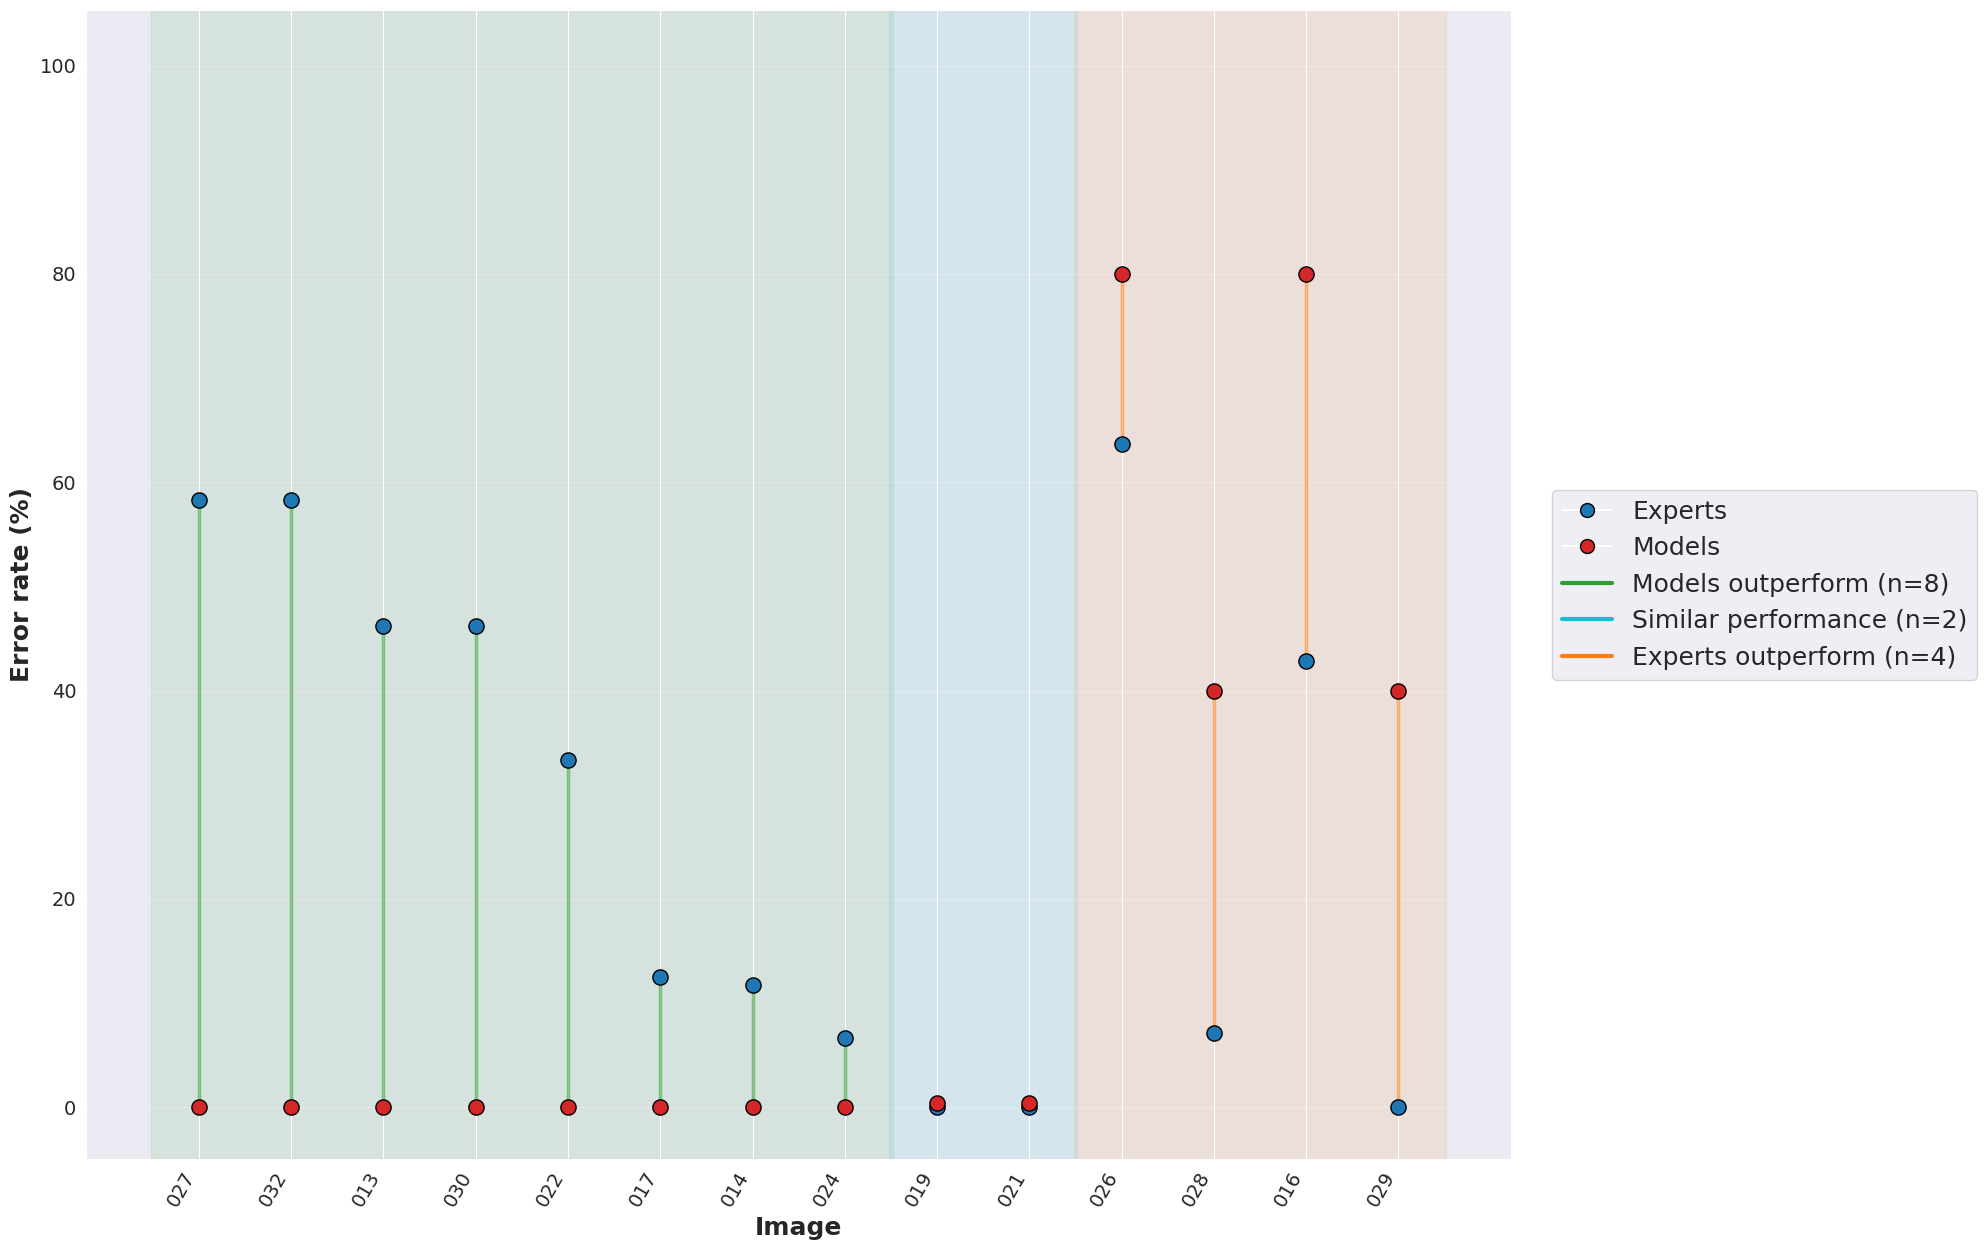

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

sns.set_style("darkgrid")

def short_img(name):
    if pd.isna(name):
        return ""
    return (str(name)
            .replace("class_img_", "")
            .replace(".png", "")
            .replace(".jpg", "")
            .replace(".jpeg", ""))

# ============================================================
# Compute error rates
# ============================================================
expert_error_rates = []
model_error_rates = []

for _, row in wide_df.iterrows():

    gt = row["binary_label"]

    # Experts
    expert_total = 0
    expert_errors = 0

    for col in expert_binary_cols:
        if col in wide_df.columns:
            v = row[col]
            if pd.notna(v) and v != "Unsure":
                expert_total += 1
                if v != gt:
                    expert_errors += 1

    expert_rate = (expert_errors / expert_total * 100) if expert_total > 0 else np.nan

    # Models
    model_total = 0
    model_errors = 0

    for m in model_names:
        col = f"{m}_binary"
        if col in wide_df.columns:
            v = row[col]
            if pd.notna(v):
                model_total += 1
                if v != gt:
                    model_errors += 1

    model_rate = (model_errors / model_total * 100) if model_total > 0 else np.nan

    expert_error_rates.append(expert_rate)
    model_error_rates.append(model_rate)

df_plot = pd.DataFrame({

    "image_name": wide_df["image_name"],
    "img_short": wide_df["image_name"].apply(short_img),
    "expert_error_rate": expert_error_rates,
    "model_error_rate": model_error_rates,

})

df_plot["delta"] = df_plot["model_error_rate"] - df_plot["expert_error_rate"]

# ============================================================
# Categories
# ============================================================
eps = 5

df_plot["category"] = np.where(
    df_plot["delta"] <= -eps,
    "Model helps",
    np.where(df_plot["delta"] >= eps, "Expert helps", "Similar")
)

cat_order = {
    "Model helps": 0,
    "Similar": 1,
    "Expert helps": 2
}

df_plot = df_plot.sort_values(
    ["category", "delta"],
    key=lambda s: s.map(cat_order) if s.name == "category" else s
).reset_index(drop=True)

# ============================================================
# Styling
# ============================================================
expert_color = "#1f77b4"
model_color  = "#d62728"

line_colors = {
    "Model helps":  "#2ca02c",
    "Similar":      "#17becf",
    "Expert helps": "#ff7f0e",
}

band_alpha = 0.10
connector_alpha = 0.55

# ============================================================
# X positions
# ============================================================
spacing = 4.0
x = np.arange(len(df_plot)) * spacing

# Nudge identical values
nudge_when_equal = 0.35

y_exp = df_plot["expert_error_rate"].to_numpy(dtype=float)
y_mod = df_plot["model_error_rate"].to_numpy(dtype=float)

equal_mask = (
    np.isfinite(y_exp)
    & np.isfinite(y_mod)
    & (np.abs(y_exp - y_mod) < 1e-12)
)

y_mod_plot = y_mod.copy()
y_mod_plot[equal_mask] += nudge_when_equal

# ============================================================
# Plot (no fixed dimensions)
# ============================================================
fig, ax = plt.subplots(figsize=(20, max(7, 0.9 * len(df_plot))))

# Keep grid behind markers/lines
ax.set_axisbelow(True)

# ============================================================
# Background bands (FIXED: stretch to fully cover blocks)
# ============================================================
half = spacing / 2.0
eps_span = 0.02 * spacing  # tiny extra to avoid hairline seams

for cat in ["Model helps", "Similar", "Expert helps"]:

    idx = df_plot.index[df_plot["category"] == cat].to_list()
    if len(idx) == 0:
        continue

    lo = x[min(idx)] - half - eps_span
    hi = x[max(idx)] + half + eps_span

    ax.axvspan(
        lo,
        hi,
        alpha=band_alpha,
        color=line_colors[cat],
        zorder=0
    )

# ============================================================
# Connectors
# ============================================================
for i in range(len(df_plot)):

    cat = df_plot.loc[i, "category"]

    ax.plot(
        [x[i], x[i]],
        [y_exp[i], y_mod_plot[i]],
        color=line_colors[cat],
        linewidth=2.5,
        alpha=connector_alpha,
        zorder=2
    )

# ============================================================
# Points
# ============================================================
ax.scatter(
    x, y_exp,
    s=120,
    color=expert_color,
    edgecolor="black",
    linewidth=1,
    label="Experts",
    zorder=3
)

ax.scatter(
    x, y_mod_plot,
    s=120,
    color=model_color,
    edgecolor="black",
    linewidth=1,
    label="Models",
    zorder=4
)

# ============================================================
# Axes
# ============================================================
ax.set_xticks(x)
ax.set_xticklabels(df_plot["img_short"], rotation=60, ha="right")

# Remove labels if desired:
# ax.set_xticklabels([])

ax.set_ylabel("Error rate (%)", fontsize=18, fontweight="bold")
ax.set_xlabel("Image", fontsize=18, fontweight="bold")

ax.set_ylim(-5, 105 + nudge_when_equal)

ax.grid(axis="y", alpha=0.25)

ax.tick_params(axis='x', labelsize=14)  # increase image name font size
ax.tick_params(axis='y', labelsize=14)  # increase y-axis font size if needed


# ============================================================
# Legend
# ============================================================
counts = df_plot["category"].value_counts().to_dict()

handles = [

    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=expert_color,
           markeredgecolor="black",
           markersize=10,
           label="Experts"),

    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=model_color,
           markeredgecolor="black",
           markersize=10,
           label="Models"),

    Line2D([0],[0], color=line_colors["Model helps"], lw=3,
           label=f"Models outperform (n={counts.get('Model helps',0)})"),

    Line2D([0],[0], color=line_colors["Similar"], lw=3,
           label=f"Similar performance (n={counts.get('Similar',0)})"),

    Line2D([0],[0], color=line_colors["Expert helps"], lw=3,
           label=f"Experts outperform (n={counts.get('Expert helps',0)})")

]

ax.legend(
    handles=handles,
    fontsize=18,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.tight_layout()

# ============================================================
# Save at 300 DPI (change dpi back to 500 if you still want)
# ============================================================
save_path = "/content/drive/My Drive/2dumbbell_expert_vs_model_error_ROTATED4.tif"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pil_kwargs={"compression": "tiff_lzw"}
)

print("Saved at 300 dpi:", save_path)
plt.show()


Runs a dedicated “visibility task” experiment to see how five binary classifiers
behave on images that experts judged as not visible, ambiguous, or clearly
visible, and to relate those behaviors to BNN epistemic uncertainty.

This script:
1. Loads an expert **visibility survey** from Excel and:
   - Excludes the ground-truth rater (ID=20),
   - Aggregates per-image votes (0 = Not visible, 1 = Unsure, 2 = Visible),
   - Assigns each image to a majority category (“Not Visible”, “Unsure”,
     “Visible”) and computes expert %No and %Yes, providing a ground-truth
     notion of which images lack enough information to classify.
2. Loads all visibility-task images from disk, preprocesses them, and runs
   five trained models (CNN, BNN with MC Dropout, MobileNetV2,
   EfficientNetV2B0, ResNet50) to obtain:
   - Predicted class (Frost vs Non-Frost),
   - Scalar confidence \(|p(\text{Frost})-0.5|\times 2\) in \([0,1]\),
   - For the BNN, **epistemic uncertainty** as the standard deviation over
     MC Dropout passes, capturing how unstable the prediction is across
     stochastic forward passes.[web:171][web:172]
3. Builds a tidy `results_df` and answers four analysis questions:
   - Q1: What do models predict on images experts labeled “Not Visible”?
     (Class counts and per-image \(p(\text{Frost})\)).
   - Q2: Are models as **confident** on “Not Visible” images as on “Visible”
     ones (mean confidence and mean \(p(\text{Frost})\) by category/model)?
   - Q3: How much **inter-model agreement** exists per image (proportion of
     models voting Frost vs Non-Frost)?
   - Q4: For the BNN, how does uncertainty and confidence vary by expert
     category (Not Visible, Unsure, Visible)?
4. Produces five publication-ready visualizations:
   - Vis 1: Per-model strip plots of \(p(\text{Frost})\) across visibility
     categories with jittered points and median bars, showing how predictions
     shift between “Not Visible”, “Unsure”, and “Visible”.
   - Vis 2: A heatmap of \(p(\text{Frost})\) (models × images), ordered by
     expert category, to inspect cross-model consistency and any systematic
     differences on ambiguous vs clear images.
   - Vis 3: Grouped bar chart comparing **mean confidence** on “Not Visible”
     vs “Visible” images per model, with value labels to reveal over- or
     under-confidence on ambiguous images.
   - Vis 4: Class-count bar chart showing how often each model outputs Frost
     vs Non-Frost on “Not Visible” images, answering whether predictions look
     random, biased, or consistent.
   - Vis 5: Two BNN-specific plots: (a) \(p(\text{Frost})\) vs epistemic
     uncertainty colored by category with image labels, and (b) uncertainty
     strip plot by category, summarizing whether the BNN is more uncertain on
     images experts deemed not visible or ambiguous.
5. Ends with a textual **summary** that restates expert category definitions,
   lists which images fall into each visibility group, and for each model
   reports how many “Not Visible” images it calls Frost vs Non-Frost and how
   its confidence compares between ambiguous and classifiable images, with all
   CSV outputs and figures saved into a dedicated `visibility_task` folder.

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!

STEP 1: READING SURVEY & CATEGORIZING IMAGES

Total rows: 20
Excluded: ID=20 (Ground Truth)
Experts used: 19

Image               No(0)  Unsure(1)  Yes(2) | Category         GT
----------------------------------------------------------------------
  vis_img_004           6          0      13 | Visible           2
  vis_img_005           1          2      16 | Visible           2
  vis_img_006          12          5       2 | Not Visible       2
  vis_img_007           9          2       8 | Not Visible       2
  vis_img_008           2         10       7 | Unsure            2
  vis_img_009           9          3       7 | Not Visible       2
  vis_img_010          10          3       6 | Not Visible       2
  vis_img_011           1          4      14 | Visible           2
  vis_img_012           3 

  vis_img_004 [Visible]: Non-Frost (p=0.011, conf=0.978)
  vis_img_005 [Visible]: Frost (p=0.978, conf=0.955)
  vis_img_006 [Not Visible]: Non-Frost (p=0.037, conf=0.925)
  vis_img_007 [Not Visible]: Frost (p=0.975, conf=0.951)
  vis_img_008 [Unsure]: Non-Frost (p=0.135, conf=0.729)
  vis_img_009 [Not Visible]: Non-Frost (p=0.473, conf=0.054)
  vis_img_010 [Not Visible]: Frost (p=0.979, conf=0.958)
  vis_img_011 [Visible]: Frost (p=0.966, conf=0.932)
  vis_img_012 [Visible]: Frost (p=0.976, conf=0.952)

--- BNN ---


  Running 20 MC Dropout passes...
  vis_img_004 [Visible]: Non-Frost (p=0.162 +/- 0.110)
  vis_img_005 [Visible]: Frost (p=0.984 +/- 0.025)
  vis_img_006 [Not Visible]: Non-Frost (p=0.355 +/- 0.165)
  vis_img_007 [Not Visible]: Frost (p=0.957 +/- 0.066)
  vis_img_008 [Unsure]: Frost (p=0.548 +/- 0.217)
  vis_img_009 [Not Visible]: Non-Frost (p=0.412 +/- 0.157)
  vis_img_010 [Not Visible]: Frost (p=0.962 +/- 0.040)
  vis_img_011 [Visible]: Frost (p=0.903 +/- 0.092)
  vis_img_012 [Visible]: Frost (p=0.945 +/- 0.060)

--- MobileNetV2 ---


  vis_img_004 [Visible]: Non-Frost (p=0.131, conf=0.738)
  vis_img_005 [Visible]: Frost (p=0.968, conf=0.935)
  vis_img_006 [Not Visible]: Non-Frost (p=0.476, conf=0.049)
  vis_img_007 [Not Visible]: Frost (p=0.890, conf=0.780)
  vis_img_008 [Unsure]: Non-Frost (p=0.475, conf=0.050)
  vis_img_009 [Not Visible]: Non-Frost (p=0.241, conf=0.517)
  vis_img_010 [Not Visible]: Frost (p=0.941, conf=0.881)
  vis_img_011 [Visible]: Frost (p=0.912, conf=0.823)
  vis_img_012 [Visible]: Frost (p=0.955, conf=0.911)

--- EfficientNetV2B0 ---


  vis_img_004 [Visible]: Non-Frost (p=0.019, conf=0.962)
  vis_img_005 [Visible]: Frost (p=0.992, conf=0.984)
  vis_img_006 [Not Visible]: Frost (p=0.944, conf=0.888)
  vis_img_007 [Not Visible]: Frost (p=0.996, conf=0.992)
  vis_img_008 [Unsure]: Frost (p=0.975, conf=0.951)
  vis_img_009 [Not Visible]: Non-Frost (p=0.192, conf=0.616)
  vis_img_010 [Not Visible]: Frost (p=0.972, conf=0.944)
  vis_img_011 [Visible]: Frost (p=0.999, conf=0.998)
  vis_img_012 [Visible]: Frost (p=0.996, conf=0.992)

--- ResNet50 ---


  vis_img_004 [Visible]: Non-Frost (p=0.050, conf=0.899)
  vis_img_005 [Visible]: Frost (p=0.996, conf=0.991)
  vis_img_006 [Not Visible]: Non-Frost (p=0.120, conf=0.760)
  vis_img_007 [Not Visible]: Frost (p=0.979, conf=0.958)
  vis_img_008 [Unsure]: Non-Frost (p=0.071, conf=0.859)
  vis_img_009 [Not Visible]: Non-Frost (p=0.106, conf=0.788)
  vis_img_010 [Not Visible]: Frost (p=0.987, conf=0.973)
  vis_img_011 [Visible]: Frost (p=0.975, conf=0.951)
  vis_img_012 [Visible]: Frost (p=0.954, conf=0.908)


STEP 5: ANALYSIS

--------------------------------------------------
Q1: MODEL PREDICTIONS ON 'NOT VISIBLE' IMAGES
--------------------------------------------------

CNN: Frost=2/4, Non-Frost=2/4
  p(Frost): [0.03700000047683716, 0.9750000238418579, 0.4729999899864197, 0.9789999723434448]

BNN: Frost=2/4, Non-Frost=2/4
  p(Frost): [0.35499998927116394, 0.9570000171661377, 0.41200000047683716, 0.9620000123977661]

MobileNetV2: Frost=2/4, Non-Frost=2/4
  p(Frost): [0.47600001096725464, 

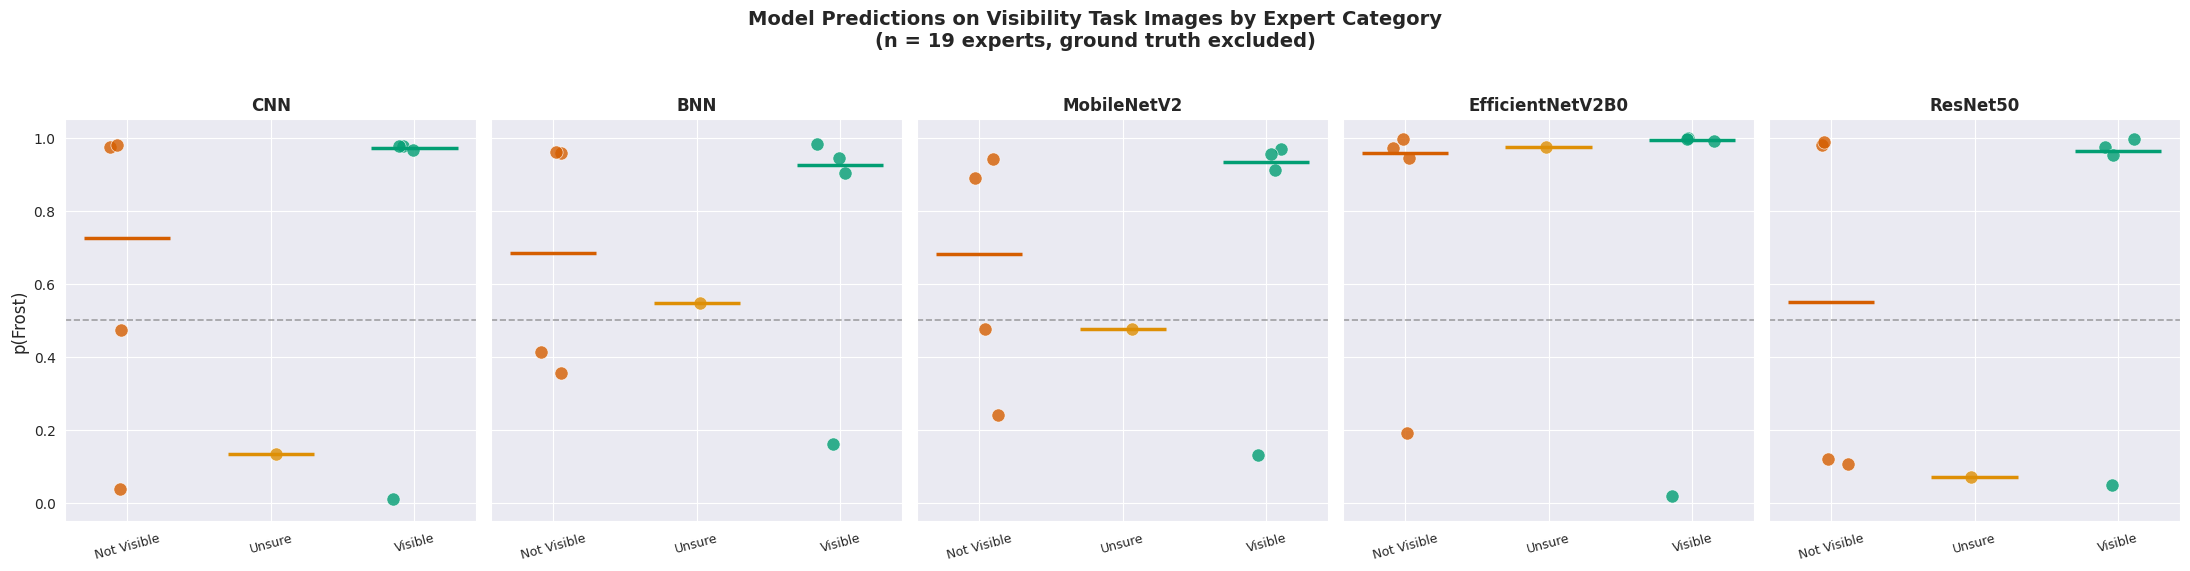

Vis 1 saved.


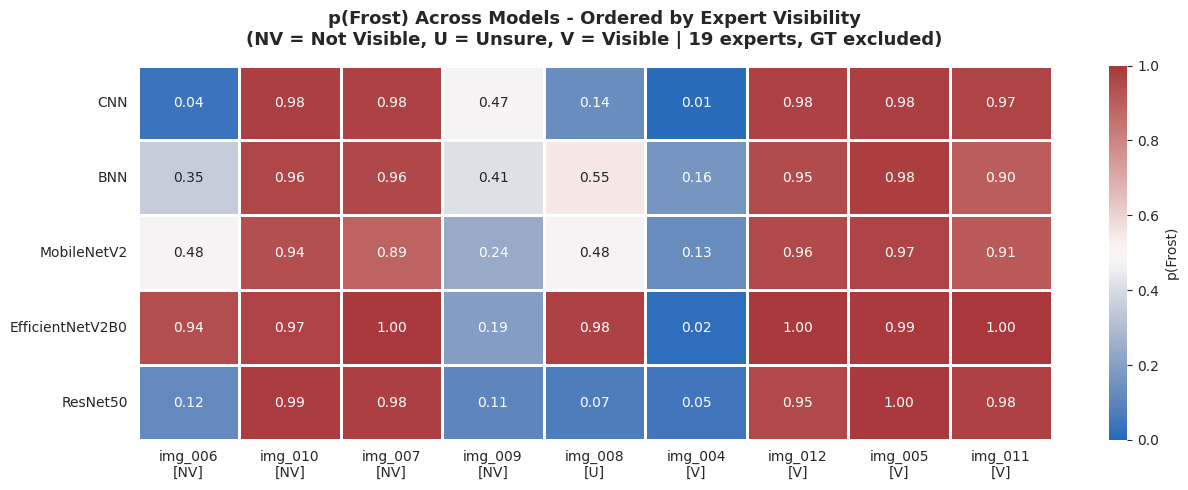

Vis 2 saved.


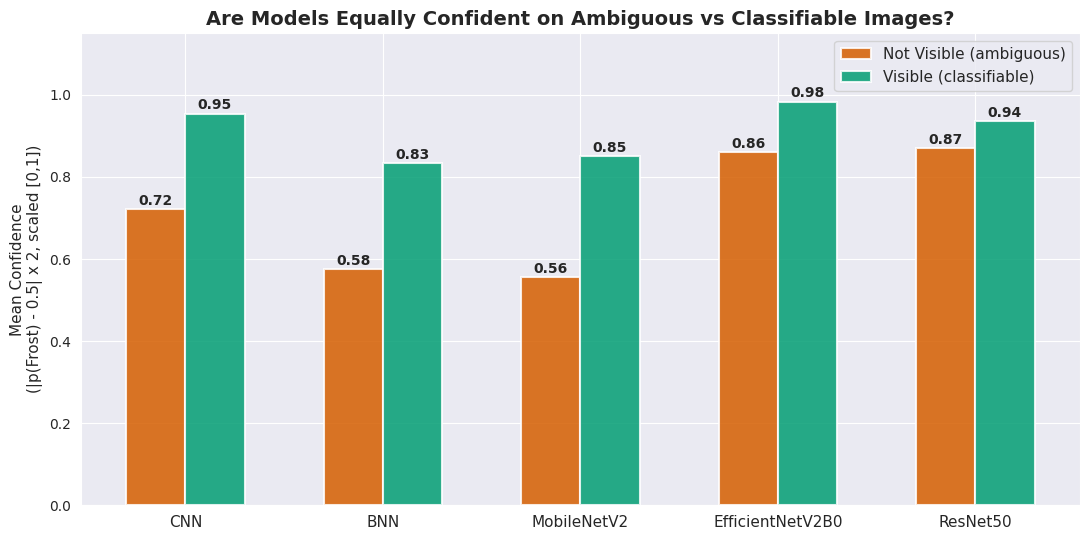

Vis 3 saved.


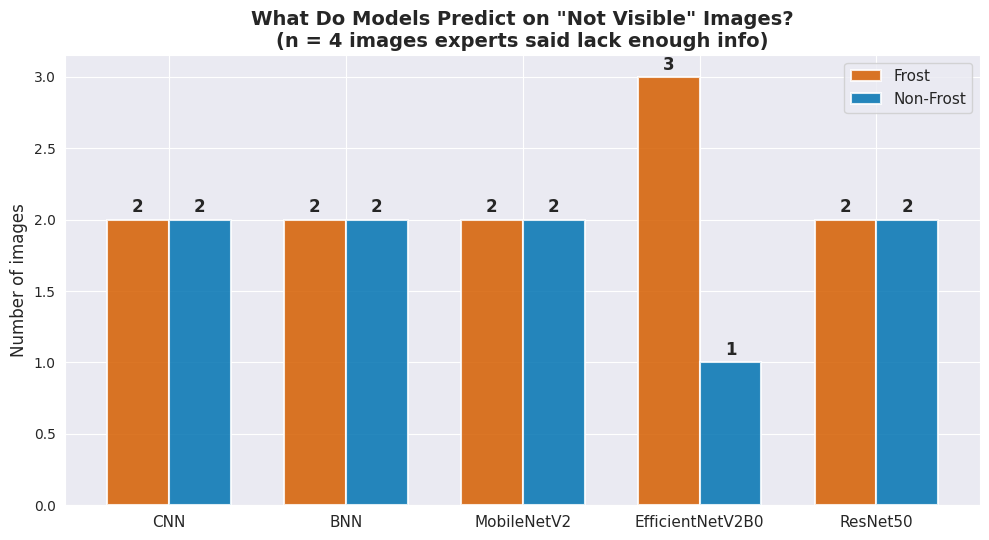

Vis 4 saved.


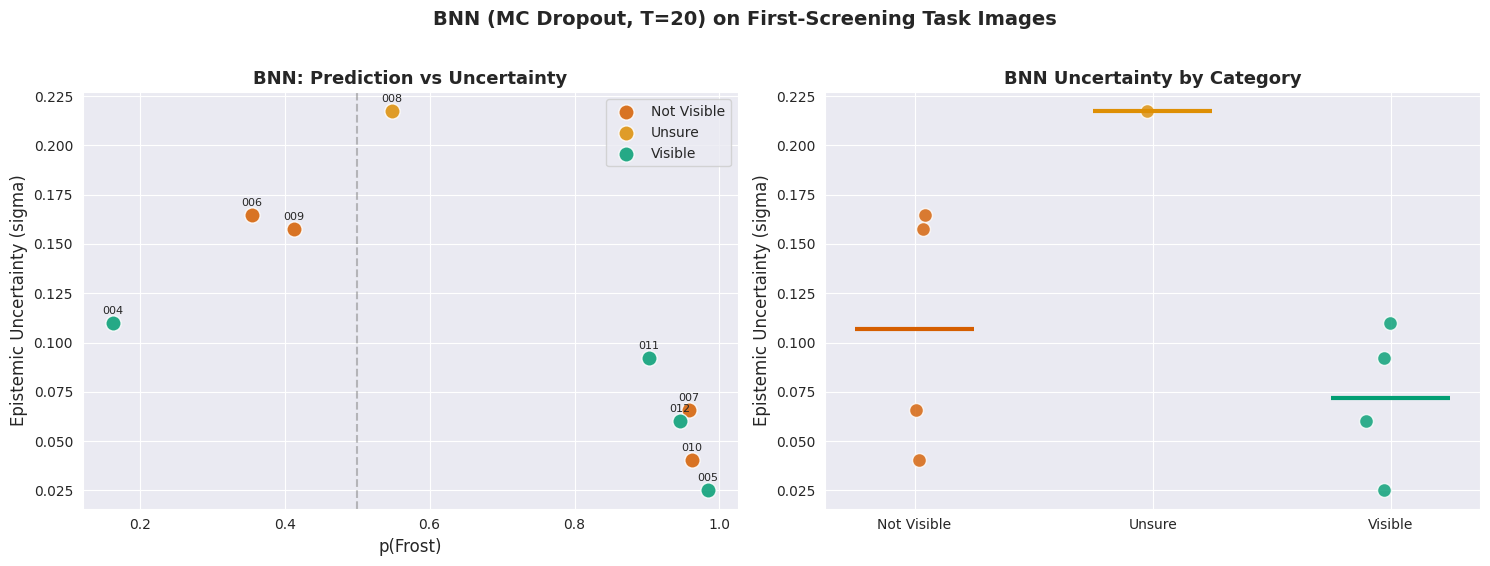

Vis 5 saved.


SUMMARY

Expert visibility survey (19 experts, ground truth ID=20 excluded):

  Not Visible (experts: 'not enough info'):
    ['vis_img_006', 'vis_img_007', 'vis_img_009', 'vis_img_010']
  Unsure (experts split):
    ['vis_img_008']
  Visible (experts: 'classifiable'):
    ['vis_img_004', 'vis_img_005', 'vis_img_011', 'vis_img_012']

Note: Ground truth marks ALL images as visible.

Model predictions on "Not Visible" images:
  CNN:
    Predictions: 2/4 Frost, 2/4 Non-Frost
    Confidence: 0.722 (Not Visible) vs 0.954 (Visible)
  BNN:
    Predictions: 2/4 Frost, 2/4 Non-Frost
    Confidence: 0.576 (Not Visible) vs 0.835 (Visible)
  MobileNetV2:
    Predictions: 2/4 Frost, 2/4 Non-Frost
    Confidence: 0.557 (Not Visible) vs 0.852 (Visible)
  EfficientNetV2B0:
    Predictions: 3/4 Frost, 1/4 Non-Frost
    Confidence: 0.860 (Not Visible) vs 0.984 (Visible)
  ResNet50:
    Predictions: 2/4 Frost, 2/4 Non-Frost
    Confidence: 0.870 (Not Visible) vs 0.937 (Visible)

All output

In [19]:
# ============================================================================
# VISIBILITY TASK ANALYSIS
# ============================================================================

# Questions:
# 1. What do models predict on unclassifiable images? (Non-Frost? Random?)
# 2. How confident are models? (Same as on classifiable images?)
# 3. Does the BNN show higher uncertainty on ambiguous images?
#
# Survey coding: 2 = Yes (visible), 1 = Unsure, 0 = No (not visible)
# ID=20 is ground truth and is EXCLUDED from expert analysis.
#
# Run in Google Colab with GPU runtime recommended.
# ============================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from google.colab import drive

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')
print("Google Drive mounted successfully!\n")

# ============================================================================
# PLOT SETTINGS
# ============================================================================
sns.set_style('darkgrid')
CB_PALETTE = sns.color_palette('colorblind')
# Assign consistent colors
COLOR_NOT_VISIBLE = CB_PALETTE[3]  # red-ish
COLOR_UNSURE = CB_PALETTE[1]       # orange-ish
COLOR_VISIBLE = CB_PALETTE[2]      # green-ish
COLOR_FROST = CB_PALETTE[3]
COLOR_NON_FROST = CB_PALETTE[0]

CATEGORY_COLORS = {
    'Not Visible': COLOR_NOT_VISIBLE,
    'Unsure': COLOR_UNSURE,
    'Visible': COLOR_VISIBLE,
}
CATEGORY_ORDER = ['Not Visible', 'Unsure', 'Visible']

# Model colors (colorblind-safe)
MODEL_COLORS = {
    'CNN': CB_PALETTE[0],
    'BNN': CB_PALETTE[2],
    'MobileNetV2': CB_PALETTE[4],
    'EfficientNetV2B0': CB_PALETTE[9],
    'ResNet50': CB_PALETTE[3],
}

# ============================================================================
# CONFIGURATION
# ============================================================================
SIZE = 512
MC_PASSES = 20

file_path = '/content/drive/My Drive/voting_poll.xlsx'
image_directory = '/content/drive/My Drive/voting_poll/images/visibility'

model_paths = {
    'CNN':              '/content/drive/MyDrive/frost/models_saved/neu_cnn_binary/cnn_best_model.h5',
    'BNN':              '/content/drive/MyDrive/frost/models_saved/neu_bnn_binary/bnn_best_model.h5',
    'MobileNetV2':      '/content/drive/MyDrive/frost/models_saved/neu_mobile_binary/mobilenet_best_model.h5',
    'EfficientNetV2B0': '/content/drive/MyDrive/frost/models_saved/neu_efficientnet_binary/efficientnet_best_model.h5',
    'ResNet50':         '/content/drive/MyDrive/frost/models_saved/neu_resnet_binary/resnet_best_model.h5',
}

output_dir = '/content/drive/MyDrive/frost/visibility_task'
os.makedirs(output_dir, exist_ok=True)

# ============================================================================
# MCDropout LAYER
# ============================================================================
class MCDropout(tf.keras.layers.Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

# ============================================================================
# STEP 1: READ SURVEY & CATEGORIZE IMAGES
# ============================================================================
print("=" * 60)
print("STEP 1: READING SURVEY & CATEGORIZING IMAGES")
print("=" * 60 + "\n")

df = pd.read_excel(file_path)

# EXCLUDE ground truth (ID=20)
gt_row = df[df['ID'] == 20]
experts_df = df[df['ID'] != 20]
n_experts = len(experts_df)
print(f"Total rows: {len(df)}")
print(f"Excluded: ID=20 (Ground Truth)")
print(f"Experts used: {n_experts}\n")

vis_cols = [c for c in df.columns if c.startswith('vis_')]

# Get ground truth visibility (all 2 = Yes for all images)
gt_visibility = {col: gt_row[col].values[0] for col in vis_cols}

# Categorize each image based on expert majority (excluding ground truth)
image_categories = {}
print(f"{'Image':<18} {'No(0)':>6} {'Unsure(1)':>10} {'Yes(2)':>7} | {'Category':<14} {'GT':>4}")
print("-" * 70)

for col in vis_cols:
    vc = experts_df[col].value_counts()
    n_no = vc.get(0, 0)
    n_unsure = vc.get(1, 0)
    n_yes = vc.get(2, 0)
    total = n_no + n_unsure + n_yes

    if n_no >= n_unsure and n_no >= n_yes:
        category = 'Not Visible'
    elif n_yes >= n_no and n_yes >= n_unsure:
        category = 'Visible'
    else:
        category = 'Unsure'

    image_categories[col] = {
        'category': category,
        'n_no': n_no,
        'n_unsure': n_unsure,
        'n_yes': n_yes,
        'pct_no': n_no / total * 100,
        'pct_yes': n_yes / total * 100,
        'gt_visible': int(gt_visibility[col]),
    }

    print(f"  {col:<16} {n_no:>6} {n_unsure:>10} {n_yes:>7} | {category:<14} {int(gt_visibility[col]):>4}")

not_visible = [c for c, v in image_categories.items() if v['category'] == 'Not Visible']
unsure_imgs = [c for c, v in image_categories.items() if v['category'] == 'Unsure']
visible = [c for c, v in image_categories.items() if v['category'] == 'Visible']

print(f"\nNot Visible: {not_visible} ({len(not_visible)} images)")
print(f"Unsure:      {unsure_imgs} ({len(unsure_imgs)} images)")
print(f"Visible:     {visible} ({len(visible)} images)")
print(f"\nNote: Ground truth marks ALL images as visible (=2)")

# ============================================================================
# STEP 2: LOAD IMAGES
# ============================================================================
print("\n" + "=" * 60)
print("STEP 2: LOADING IMAGES")
print("=" * 60 + "\n")

def load_and_preprocess(path, size=SIZE):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    img = img.astype(np.float32) / 255.0
    return img

all_vis_files = sorted(glob(os.path.join(image_directory, '*')))
file_map = {}
for f in all_vis_files:
    name_no_ext = os.path.splitext(os.path.basename(f))[0]
    file_map[name_no_ext] = f

images_dict = {}
for col in vis_cols:
    if col in file_map:
        images_dict[col] = load_and_preprocess(file_map[col])
    else:
        print(f"  Warning: File not found for {col}")

all_image_names = list(images_dict.keys())
all_images = np.array([images_dict[name] for name in all_image_names])
print(f"Loaded {len(images_dict)} images ({SIZE}x{SIZE}).")

# ============================================================================
# STEP 3: RUN ALL MODELS
# ============================================================================
print("\n" + "=" * 60)
print("STEP 3: RUNNING ALL MODELS")
print("=" * 60)

all_results = {}
model_names_list = list(model_paths.keys())

for model_name, model_path in model_paths.items():
    print(f"\n--- {model_name} ---")

    if model_name == 'BNN':
        model = tf.keras.models.load_model(
            model_path, custom_objects={'MCDropout': MCDropout}
        )
    else:
        model = tf.keras.models.load_model(model_path)

    model_results = {}

    if model_name == 'BNN':
        print(f"  Running {MC_PASSES} MC Dropout passes...")
        mc_preds = np.array([
            model(all_images, training=False).numpy().flatten()
            for _ in range(MC_PASSES)
        ])
        mean_preds = mc_preds.mean(axis=0)
        std_preds = mc_preds.std(axis=0)

        for i, name in enumerate(all_image_names):
            pred_label = 'Frost' if mean_preds[i] > 0.5 else 'Non-Frost'
            confidence = abs(mean_preds[i] - 0.5) * 2
            model_results[name] = {
                'pred_prob': mean_preds[i],
                'pred_label': pred_label,
                'confidence': confidence,
                'uncertainty': std_preds[i],
            }
            cat = image_categories[name]['category']
            print(f"  {name} [{cat}]: {pred_label} "
                  f"(p={mean_preds[i]:.3f} +/- {std_preds[i]:.3f})")
    else:
        preds = model.predict(all_images, verbose=0).flatten()
        for i, name in enumerate(all_image_names):
            pred_label = 'Frost' if preds[i] > 0.5 else 'Non-Frost'
            confidence = abs(preds[i] - 0.5) * 2
            model_results[name] = {
                'pred_prob': preds[i],
                'pred_label': pred_label,
                'confidence': confidence,
                'uncertainty': np.nan,
            }
            cat = image_categories[name]['category']
            print(f"  {name} [{cat}]: {pred_label} (p={preds[i]:.3f}, conf={confidence:.3f})")

    all_results[model_name] = model_results
    del model
    tf.keras.backend.clear_session()

# ============================================================================
# STEP 4: BUILD RESULTS DATAFRAME
# ============================================================================
rows = []
for model_name, results in all_results.items():
    for img_name, r in results.items():
        rows.append({
            'Model': model_name,
            'Image': img_name,
            'Category': image_categories[img_name]['category'],
            'Expert %No': image_categories[img_name]['pct_no'],
            'Expert %Yes': image_categories[img_name]['pct_yes'],
            'Predicted Class': r['pred_label'],
            'p(Frost)': r['pred_prob'],
            'Confidence': r['confidence'],
            'Uncertainty (BNN)': r['uncertainty'],
        })

results_df = pd.DataFrame(rows)
results_df.to_csv(os.path.join(output_dir, 'visibility_task_results.csv'), index=False)

pivot_probs = results_df.pivot(index='Image', columns='Model', values='p(Frost)')
pivot_labels = results_df.pivot(index='Image', columns='Model', values='Predicted Class')

# ============================================================================
# STEP 5: ANALYSIS
# ============================================================================
print("\n\n" + "=" * 60)
print("STEP 5: ANALYSIS")
print("=" * 60)

# --- Q1: Predictions on Not Visible images ---
print("\n" + "-" * 50)
print("Q1: MODEL PREDICTIONS ON 'NOT VISIBLE' IMAGES")
print("-" * 50)

for mn in model_names_list:
    nv_df = results_df[(results_df['Model'] == mn) &
                        (results_df['Category'] == 'Not Visible')]
    frost_n = (nv_df['Predicted Class'] == 'Frost').sum()
    nf_n = (nv_df['Predicted Class'] == 'Non-Frost').sum()
    total = len(nv_df)
    print(f"\n{mn}: Frost={frost_n}/{total}, Non-Frost={nf_n}/{total}")
    print(f"  p(Frost): {nv_df['p(Frost)'].round(3).tolist()}")

# --- Q2: Confidence comparison ---
print("\n" + "-" * 50)
print("Q2: MEAN CONFIDENCE - NOT VISIBLE vs VISIBLE")
print("-" * 50)

print(f"\n{'Model':<18} | {'Not Visible':>20} | {'Visible':>20}")
print(f"{'':18} | {'Conf':>8} {'p mean':>8} | {'Conf':>8} {'p mean':>8}")
print("-" * 70)

for mn in model_names_list:
    nv = results_df[(results_df['Model'] == mn) & (results_df['Category'] == 'Not Visible')]
    vi = results_df[(results_df['Model'] == mn) & (results_df['Category'] == 'Visible')]
    print(f"  {mn:<16} | {nv['Confidence'].mean():>8.3f} {nv['p(Frost)'].mean():>8.3f}"
          f" | {vi['Confidence'].mean():>8.3f} {vi['p(Frost)'].mean():>8.3f}")

# --- Q3: Agreement ---
print("\n" + "-" * 50)
print("Q3: INTER-MODEL AGREEMENT")
print("-" * 50)

print(f"\n{'Image':<18} {'Cat':<14}", end="")
for mn in model_names_list:
    print(f" {mn[:8]:>10}", end="")
print(f" | {'Agree':>6}")
print("-" * 95)

for img in all_image_names:
    cat = image_categories[img]['category']
    print(f"  {img:<16} {cat:<14}", end="")
    preds = []
    for mn in model_names_list:
        p = pivot_probs.loc[img, mn]
        label = 'F' if p > 0.5 else 'NF'
        preds.append(label)
        print(f" {p:>7.2f}({label})", end="")
    agreement = max(preds.count('F'), preds.count('NF')) / len(preds) * 100
    print(f" | {agreement:>5.0f}%")

# --- Q4: BNN uncertainty ---
print("\n" + "-" * 50)
print("Q4: BNN UNCERTAINTY BY CATEGORY")
print("-" * 50)

bnn_df = results_df[results_df['Model'] == 'BNN']
for cat in CATEGORY_ORDER:
    cat_df = bnn_df[bnn_df['Category'] == cat]
    if len(cat_df) > 0:
        print(f"\n{cat} (n={len(cat_df)}):")
        print(f"  Mean uncertainty (sigma): {cat_df['Uncertainty (BNN)'].mean():.4f}")
        print(f"  Mean confidence: {cat_df['Confidence'].mean():.3f}")
        print(f"  Mean p(Frost): {cat_df['p(Frost)'].mean():.3f}")

# ============================================================================
# VIS 1: Strip plot - p(Frost) by category, per model
# ============================================================================
fig, axes = plt.subplots(1, len(model_names_list), figsize=(22, 5.5), sharey=True)

for i, model_name in enumerate(model_names_list):
    ax = axes[i]
    model_df = results_df[results_df['Model'] == model_name]

    for cat in CATEGORY_ORDER:
        cat_df = model_df[model_df['Category'] == cat]
        if len(cat_df) > 0:
            jitter = np.random.normal(0, 0.08, size=len(cat_df))
            cat_idx = CATEGORY_ORDER.index(cat)
            ax.scatter(cat_idx + jitter, cat_df['p(Frost)'],
                       c=[CATEGORY_COLORS[cat]], s=90, alpha=0.8,
                       edgecolors='white', linewidth=0.5, zorder=3)
            ax.hlines(cat_df['p(Frost)'].median(), cat_idx - 0.3, cat_idx + 0.3,
                      color=CATEGORY_COLORS[cat], linewidth=2.5, zorder=4)

    ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.set_xticks(range(len(CATEGORY_ORDER)))
    ax.set_xticklabels(CATEGORY_ORDER, fontsize=9, rotation=15)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)

    if i == 0:
        ax.set_ylabel('p(Frost)', fontsize=12)

plt.suptitle('Model Predictions on Visibility Task Images by Expert Category\n'
             f'(n = {n_experts} experts, ground truth excluded)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'vis1_predictions_by_category.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Vis 1 saved.")

# ============================================================================
# VIS 2: Heatmap - p(Frost) across models x images
# ============================================================================
fig, ax = plt.subplots(figsize=(13, 5))

ordered_images = sorted(all_image_names,
                        key=lambda x: (CATEGORY_ORDER.index(image_categories[x]['category']),
                                       -image_categories[x]['pct_no']))

heatmap_data = np.array([
    [pivot_probs.loc[img, mn] for img in ordered_images]
    for mn in model_names_list
])

xlabels = []
for img in ordered_images:
    cat = image_categories[img]['category']
    cat_short = {'Not Visible': 'NV', 'Unsure': 'U', 'Visible': 'V'}[cat]
    xlabels.append(f"{img.replace('vis_img_', 'img_')}\n[{cat_short}]")

cmap = sns.color_palette("vlag", as_cmap=True)
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap=cmap,
            center=0.5, vmin=0, vmax=1,
            xticklabels=xlabels, yticklabels=model_names_list,
            ax=ax, linewidths=0.8, linecolor='white',
            cbar_kws={'label': 'p(Frost)'})

ax.set_title(f'p(Frost) Across Models - Ordered by Expert Visibility\n'
             f'(NV = Not Visible, U = Unsure, V = Visible | {n_experts} experts, GT excluded)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'vis2_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Vis 2 saved.")

# ============================================================================
# VIS 3: Confidence comparison - Not Visible vs Visible
# ============================================================================
fig, ax = plt.subplots(figsize=(11, 5.5))

x = np.arange(len(model_names_list))
width = 0.3

nv_confs = []
v_confs = []
for mn in model_names_list:
    nv = results_df[(results_df['Model'] == mn) & (results_df['Category'] == 'Not Visible')]
    vi = results_df[(results_df['Model'] == mn) & (results_df['Category'] == 'Visible')]
    nv_confs.append(nv['Confidence'].mean() if len(nv) > 0 else 0)
    v_confs.append(vi['Confidence'].mean() if len(vi) > 0 else 0)

bars1 = ax.bar(x - width/2, nv_confs, width, label='Not Visible (ambiguous)',
               color=COLOR_NOT_VISIBLE, alpha=0.85, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, v_confs, width, label='Visible (classifiable)',
               color=COLOR_VISIBLE, alpha=0.85, edgecolor='white', linewidth=1.5)

for bar in [*bars1, *bars2]:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names_list, fontsize=11)
ax.set_ylabel('Mean Confidence\n(|p(Frost) - 0.5| x 2, scaled [0,1])', fontsize=11)
ax.set_title('Are Models Equally Confident on Ambiguous vs Classifiable Images?',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'vis3_confidence_comparison.tif'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Vis 3 saved.")

# ============================================================================
# VIS 4: Class distribution on Not Visible images only
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 5.5))

frost_counts = []
nf_counts = []
for mn in model_names_list:
    nv = results_df[(results_df['Model'] == mn) & (results_df['Category'] == 'Not Visible')]
    frost_counts.append((nv['Predicted Class'] == 'Frost').sum())
    nf_counts.append((nv['Predicted Class'] == 'Non-Frost').sum())

x = np.arange(len(model_names_list))
width = 0.35

bars1 = ax.bar(x - width/2, frost_counts, width, label='Frost',
               color=COLOR_FROST, alpha=0.85, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, nf_counts, width, label='Non-Frost',
               color=COLOR_NON_FROST, alpha=0.85, edgecolor='white', linewidth=1.5)

for bar in [*bars1, *bars2]:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                str(int(bar.get_height())), ha='center', fontsize=12, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names_list, fontsize=11)
ax.set_ylabel('Number of images', fontsize=12)
ax.set_title(f'What Do Models Predict on "Not Visible" Images?\n'
             f'(n = {len(not_visible)} images experts said lack enough info)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'vis4_class_distribution.tif'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Vis 4 saved.")

# ============================================================================
# VIS 5: BNN - prediction vs uncertainty, colored by category
# ============================================================================
if 'BNN' in all_results:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    bnn_plot = results_df[results_df['Model'] == 'BNN'].copy()

    # Left: p(Frost) vs Uncertainty
    ax = axes[0]
    for cat in CATEGORY_ORDER:
        cat_df = bnn_plot[bnn_plot['Category'] == cat]
        ax.scatter(cat_df['p(Frost)'], cat_df['Uncertainty (BNN)'],
                   c=[CATEGORY_COLORS[cat]], s=120, alpha=0.85,
                   edgecolors='white', label=cat, zorder=3)
        for _, row in cat_df.iterrows():
            ax.annotate(row['Image'].replace('vis_img_', ''),
                        (row['p(Frost)'], row['Uncertainty (BNN)']),
                        fontsize=8, ha='center', va='bottom',
                        textcoords='offset points', xytext=(0, 5))

    ax.axvline(x=0.5, color='grey', linestyle='--', alpha=0.5)
    ax.set_xlabel('p(Frost)', fontsize=12)
    ax.set_ylabel('Epistemic Uncertainty (sigma)', fontsize=12)
    ax.set_title('BNN: Prediction vs Uncertainty', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

    # Right: Uncertainty by category
    ax = axes[1]
    for j, cat in enumerate(CATEGORY_ORDER):
        cat_df = bnn_plot[bnn_plot['Category'] == cat]
        if len(cat_df) > 0:
            vals = cat_df['Uncertainty (BNN)'].values
            jitter = np.random.normal(0, 0.06, size=len(vals))
            ax.scatter(j + jitter, vals, c=[CATEGORY_COLORS[cat]],
                       s=100, alpha=0.8, edgecolors='white', zorder=3)
            ax.hlines(vals.mean(), j - 0.25, j + 0.25,
                      color=CATEGORY_COLORS[cat], linewidth=3, zorder=4)

    ax.set_xticks(range(len(CATEGORY_ORDER)))
    ax.set_xticklabels(CATEGORY_ORDER, fontsize=10)
    ax.set_ylabel('Epistemic Uncertainty (sigma)', fontsize=12)
    ax.set_title('BNN Uncertainty by Category', fontsize=13, fontweight='bold')

    plt.suptitle(f'BNN (MC Dropout, T={MC_PASSES}) on First-Screening Task Images',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'vis5_bnn_uncertainty.tif'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print("Vis 5 saved.")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

print(f"""
Expert visibility survey ({n_experts} experts, ground truth ID=20 excluded):

  Not Visible (experts: 'not enough info'):
    {not_visible}
  Unsure (experts split):
    {unsure_imgs}
  Visible (experts: 'classifiable'):
    {visible}

Note: Ground truth marks ALL images as visible.

Model predictions on "Not Visible" images:""")

for mn in model_names_list:
    nv = results_df[(results_df['Model'] == mn) & (results_df['Category'] == 'Not Visible')]
    vi = results_df[(results_df['Model'] == mn) & (results_df['Category'] == 'Visible')]
    frost_n = (nv['Predicted Class'] == 'Frost').sum()
    nv_conf = nv['Confidence'].mean()
    vi_conf = vi['Confidence'].mean()
    print(f"  {mn}:")
    print(f"    Predictions: {frost_n}/{len(nv)} Frost, {len(nv)-frost_n}/{len(nv)} Non-Frost")
    print(f"    Confidence: {nv_conf:.3f} (Not Visible) vs {vi_conf:.3f} (Visible)")

print(f"\nAll outputs saved to: {output_dir}")
print("=" * 60)